## Homework 5: Transfer Learning with MobileNetV2 on the Intel Image Dataset

**Due: Sunday, October 4, 2026, at 11:59 PM ET**

There is a grace period until **2:00 AM ET**. After that, late submissions are penalized **10% for each 24-hour period**. After **5 days**, the score is 0.

In this assignment, you will use a modern pretrained CNN, **MobileNetV2**, to classify the **Intel Image Dataset**, which contains 6 scene classes.

You will begin by using MobileNetV2 as a **frozen feature extractor**, training only a new classification head. You will then explore progressively more flexible transfer-learning strategies by making all or part of the pretrained backbone trainable.

To make experimentation practical, the notebook provides a `DATA_FRACTION` setting. During development, you may use a smaller fraction of the dataset to test ideas and compare configurations more quickly. Before recording your final results, set:

```python
DATA_FRACTION = 1.0
```

and rerun the complete notebook using the full dataset.

Because MobileNetV2 was pretrained on ImageNet, the images are processed using `mobilenet_v2.preprocess_input`, which scales the input pixels to the range expected by the pretrained network.

The goal is to understand **why transfer learning works**, how to design a useful **classification head**, and how choices such as **learning rate**, **learning-rate control with `ReduceLROnPlateau`**, **regularization**, and **which pretrained layers are allowed to change** affect model performance.

### Learning Objectives

By the end of this homework, you should be able to:

* Use a pretrained CNN as a **frozen feature extractor**.
* Design and compare different **classification heads** on top of a pretrained backbone.
* Experiment efficiently using a reduced dataset before running final models on the full dataset.
* Understand the difference between a **frozen backbone** and making some or all pretrained layers trainable.
* Use practical training controls including:

  * fixed **learning rates**,
  * `ReduceLROnPlateau`,
  * `EarlyStopping`,
  * **Dropout** and **L2 regularization**,
  * and **Batch Normalization** in classification heads.
* Compare strategies that make:

  * the **entire backbone** trainable,
  * only the **last N layers** trainable,
  * or only the **top K MobileNetV2 blocks** trainable.

### Baseline Model

The starting backbone is:

```python
MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)
```

With `pooling="avg"`, MobileNetV2 already applies **Global Average Pooling** and outputs a **1280-dimensional feature vector** for each image.

The baseline classification head consists of a single:

```python
Dense(num_classes, activation="softmax")
```

layer for the 6 Intel classes.

**Do not add another pooling layer when `pooling="avg"` is used.**

### The Five Problems

1. **Problem 1 — Frozen Backbone:**
   Keep MobileNetV2 frozen and redesign only the **classification head**. Try at least three head designs and experiment with training hyperparameters.

2. **Problem 2 — Fully Trainable Backbone:**
   Use one of your best head architectures from Problem 1, make the **entire MobileNetV2 backbone trainable**, and experiment with appropriately small learning rates and other training choices.

3. **Problem 3 — Unfreeze the Last N Layers:**
   Keep most of MobileNetV2 frozen while allowing only the **last N layers** to be updated.

4. **Problem 4 — Unfreeze the Top K Blocks:**
   Instead of selecting individual layers, make only the **top K MobileNetV2 blocks or stages** trainable and compare the results.

5. **Problem 5 -- Final Reflection**

Use your **HW4 CNN results as a reference point**. Transfer learning may or may not outperform every model you developed in HW4; the important goal is to understand how the different transfer-learning strategies affect training behavior and model performance.



## 1. Setup and Data Loading


In [1]:
# -------- Standard library --------
import os
import time
import random
from collections import Counter

# Quiet TensorFlow logs (set BEFORE importing TF)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# -------- Third-party --------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import kagglehub

import tensorflow as tf
from tensorflow.keras import layers,models, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback,EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    GlobalAveragePooling2D,
    GlobalMaxPooling2D,
    Input,
    MaxPooling2D,
    ReLU,
    SeparableConv2D,
)

from tensorflow.keras.applications import mobilenet_v2
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.preprocessing.image import load_img, img_to_array



he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)

# Reproducibility settings
# -------------------------
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))


### Utility function to plot learning curves and keep track of all results

- Call `print_results()` to see listing of all results logged so far

In [2]:

def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Training and testing sets already defined, accessed here as global variables

In [3]:
# Uses globals: train_ds, val_ds, test_ds

def train_and_test(model, 
                   epochs=500,
                   lr_schedule=1e-3,
                   optimizer="Adam",
                   title="Learning Curves",
                   batch_size=64,  # kept for API compatibility; ignored if datasets are batched
                   use_early_stopping=True,
                   patience=8,
                   min_delta=1e-4,
                   callbacks=None,
                   verbose=1,
                   return_history=False):

    print(f"\n{title}\n")

    # Choose optimizer
    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule)
    else:
        opt = optimizer  # assume already an optimizer instance

    # Compile
    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,
        verbose=verbose
    )

    extra_cbs = callbacks or []
    cbs = ([early_stop] if use_early_stopping else []) + extra_cbs

    start = time.time()

    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=cbs,
        verbose=verbose
    )

    # Best epoch consistent with EarlyStopping monitor
    best_epoch = int(np.argmin(history.history["val_loss"]))
    best_acc   = history.history["val_accuracy"][best_epoch]

    plot_learning_curves(history, title=title)

    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")

    end = time.time()
    print(f"\nExecution Time: " + format_hms(end - start))

    if return_history:
        return history


### Load the Intel Image Classification Dataset  



In [4]:
path      = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, "seg_train/seg_train")
test_dir  = os.path.join(path, "seg_test/seg_test")

In [5]:
# --------------------------------------------------
# DATASET SIZE
#
# For faster experimentation on a slower computer,
# you may reduce DATA_FRACTION (for example, to 0.25).
#
# IMPORTANT: Set DATA_FRACTION = 1.0 and rerun the
# complete notebook before recording your final results.
# --------------------------------------------------

DATA_FRACTION = 0.25

AUTOTUNE = tf.data.AUTOTUNE

def stratified_subsample(filepaths, labels, fraction=1.0, seed=42):
    """
    Keep the same fraction of examples from each class.
    fraction=1.0 uses the complete dataset.
    """
    if fraction >= 1.0:
        return filepaths, labels

    rng = np.random.default_rng(seed)

    keep_idx = []

    for c in np.unique(labels):
        idx = np.flatnonzero(labels == c)
        rng.shuffle(idx)

        n_keep = max(1, int(len(idx) * fraction))
        keep_idx.extend(idx[:n_keep])

    keep_idx = np.array(keep_idx)
    rng.shuffle(keep_idx)

    return filepaths[keep_idx], labels[keep_idx]

def list_files_and_labels(directory, class_names=None, exts=(".jpg", ".jpeg", ".png")):
    """
    Returns:
      filepaths: np.array[str]
      labels:    np.array[int32]
      class_names_used: list[str] in deterministic order
    """
    if class_names is None:
        class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
    else:
        # keep only classes that exist in this directory, preserve given order
        class_names = [c for c in class_names if os.path.isdir(os.path.join(directory, c))]

    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    filepaths = []
    labels = []

    for cname in class_names:
        folder = os.path.join(directory, cname)
        for fname in sorted(os.listdir(folder)):  # deterministic within class
            if fname.lower().endswith(exts):
                filepaths.append(os.path.join(folder, fname))
                labels.append(class_to_idx[cname])

    return np.array(filepaths), np.array(labels, dtype=np.int32), class_names


def stratified_split_indices(y, val_frac=0.2, seed=42):
    """
    Deterministic stratified split over indices.
    Returns: train_idx, val_idx (np arrays)
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    n = len(y)

    train_idx_list = []
    val_idx_list = []

    classes = np.unique(y)
    for c in classes:
        idx = np.flatnonzero(y == c)
        rng.shuffle(idx)
        n_val = int(np.floor(len(idx) * val_frac))
        val_idx_list.append(idx[:n_val])
        train_idx_list.append(idx[n_val:])

    train_idx = np.concatenate(train_idx_list)
    val_idx = np.concatenate(val_idx_list)

    # Optional: shuffle each split deterministically so batches mix classes
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return train_idx, val_idx


def make_image_dataset(filepaths, labels, img_size=(150, 150), batch_size=32,
                       shuffle=False, seed=42, cache_to_disk=None):
    """
    Builds a tf.data.Dataset that loads images lazily from disk.
    - filepaths: np array of strings
    - labels:    np array of int32
    """
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        # shuffle file *references* (cheap), not image tensors
        ds = ds.shuffle(buffer_size=len(filepaths), seed=seed, reshuffle_each_iteration=True)

    def _load_and_preprocess(path, label):
        # read bytes -> decode -> resize -> float32 -> MobileNetV2 preprocessing
        img_bytes = tf.io.read_file(path)
        img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.image.resize(img, img_size, method="bilinear")
        img = tf.cast(img, tf.float32)
        img = preprocess_input(img)
        return img, label

    ds = ds.map(_load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if cache_to_disk is not None:
        # Disk caching avoids RAM blowups; /tmp is fine in Colab
        ds = ds.cache(cache_to_disk)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


# -------------------------
# Example usage for Intel dataset
# -------------------------

IMG_SIZE      = (150, 150)
INPUT_SHAPE   = IMG_SIZE + (3,)
BATCH_SIZE    = 32
VAL_FRAC      = 0.2
SEED          = random_seed  # use your existing seed


# 1) List train files/labels deterministically
train_files, train_labels, class_names = list_files_and_labels(train_dir)

num_classes = len(class_names)

# Optional: use a smaller stratified subset while developing/debugging
train_files, train_labels = stratified_subsample(
    train_files,
    train_labels,
    fraction=DATA_FRACTION,
    seed=SEED,
)

# 2) Stratified deterministic train/validation split
train_idx, val_idx = stratified_split_indices(
    train_labels,
    val_frac=VAL_FRAC,
    seed=SEED,
)

# 3) Slice file lists
files_train = train_files[train_idx]
y_train     = train_labels[train_idx]

files_val   = train_files[val_idx]
y_val       = train_labels[val_idx]

# 4) Build datasets
train_ds = make_image_dataset(
    files_train,
    y_train,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    cache_to_disk=None,
)

val_ds = make_image_dataset(
    files_val,
    y_val,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    cache_to_disk=None,
)

# 5) Test set
test_files, test_labels, _ = list_files_and_labels(
    test_dir,
    class_names=class_names,
)

# Use the same fraction for quick development runs
test_files, test_labels = stratified_subsample(
    test_files,
    test_labels,
    fraction=DATA_FRACTION,
    seed=SEED,
)

test_ds = make_image_dataset(
    test_files,
    test_labels,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    cache_to_disk=None,
)



### Examine The Dataset

In [6]:

def show_counts_from_labels(name, labels, class_names):
    c = Counter(labels.tolist())
    counts = {class_names[k]: c.get(k, 0) for k in range(len(class_names))}
    print(f"{name} per-class counts:", counts)

print("class_names:", class_names)
print("train examples:", len(files_train), "val examples:", len(files_val), "test examples:", len(test_files))

show_counts_from_labels("train", y_train, class_names)
show_counts_from_labels("val",   y_val,   class_names)
show_counts_from_labels("test",  test_labels, class_names)


class_names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
train examples: 2807 val examples: 699 test examples: 748
train per-class counts: {'buildings': 438, 'forest': 454, 'glacier': 481, 'mountain': 503, 'sea': 455, 'street': 476}
val per-class counts: {'buildings': 109, 'forest': 113, 'glacier': 120, 'mountain': 125, 'sea': 113, 'street': 119}
test per-class counts: {'buildings': 109, 'forest': 118, 'glacier': 138, 'mountain': 131, 'sea': 127, 'street': 125}


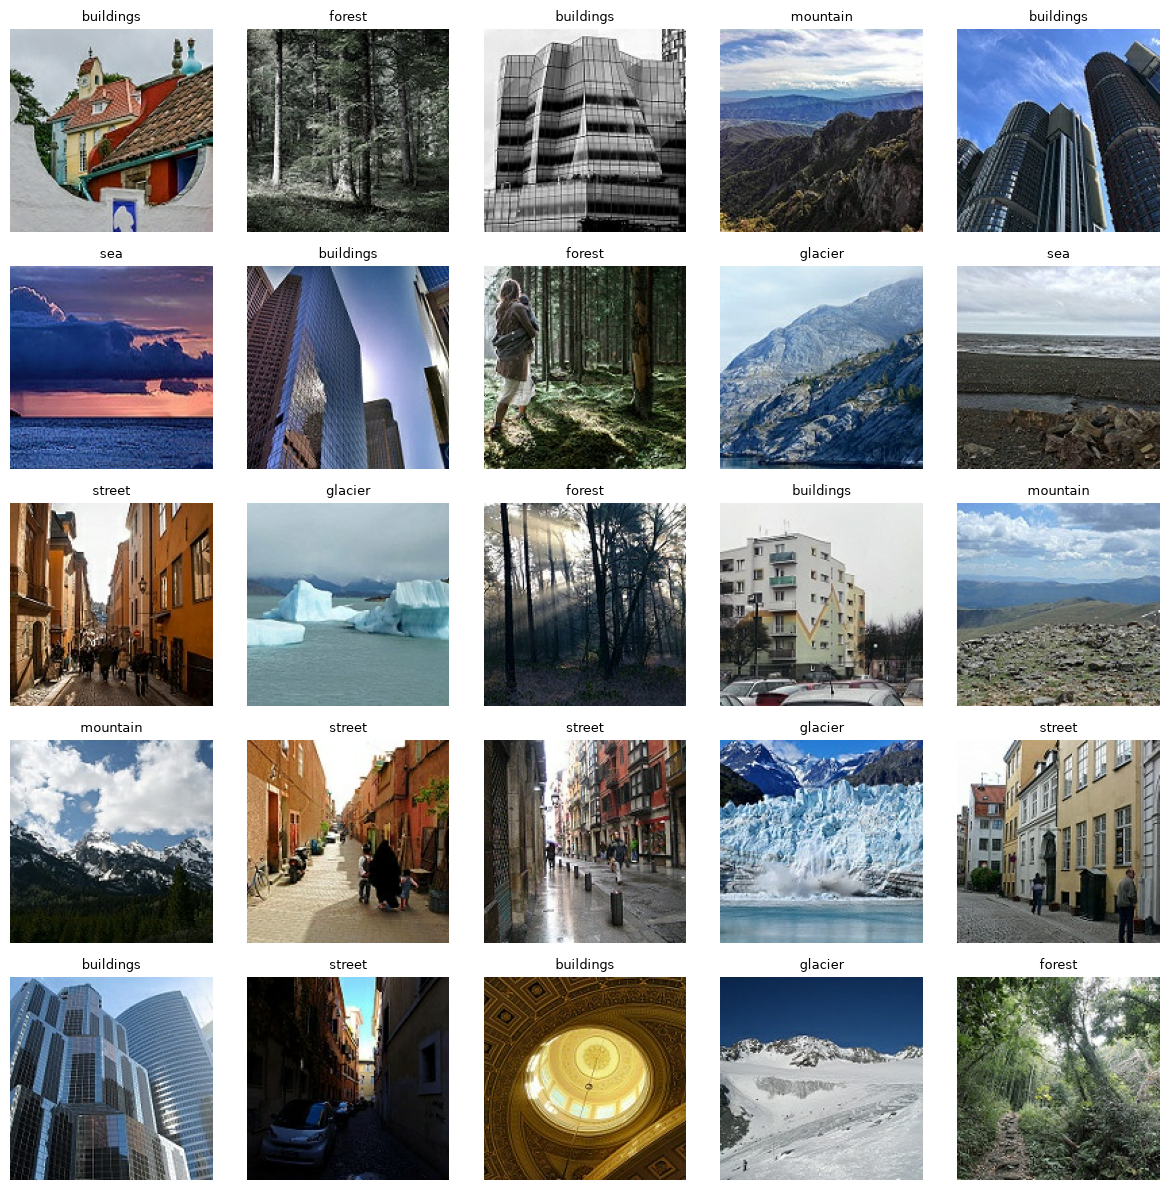

In [7]:
# Show 25 sample images

plt.figure(figsize=(12, 12))

images, labels = next(iter(train_ds))

for i in range(25):
    ax = plt.subplot(5, 5, i + 1)

    # Convert MobileNetV2 [-1, 1] values back to [0, 1] for display
    img = (images[i].numpy() + 1.0) / 2.0

    plt.imshow(img)
    plt.title(class_names[int(labels[i])], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Learning Rate Schedulers

In [8]:
# Must be input as callback in train_and_test(....   , callbacks=[reduce_lr] )

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=3,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=0,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-7,           # Lower bound on the learning rate.
    verbose=1,             # 0: quiet, 1: update messages.
)

### Prelude: Baseline Model

`MobileNetV2` is a lightweight CNN pretrained on the ImageNet dataset. We will use it as a source of high-quality visual features rather than training a convolutional network from scratch.

See the **Appendix** for additional information about `MobileNetV2`.

The baseline model defined below uses `MobileNetV2` as a frozen **feature extractor**. With `include_top=False` and built-in **Global Average Pooling**, the backbone produces a 1280-dimensional feature vector for each image.

The images have already been processed using `mobilenet_v2.preprocess_input`, which scales the pixel values to the range expected by the pretrained MobileNetV2 weights.

> **NOTE:** The standard MobileNetV2 ImageNet weights are associated with 224×224 images. We use 150×150 images to reduce training time. This is valid because, with `include_top=False`, the convolutional backbone can operate on different input image sizes.
>
> Keras may therefore issue a warning such as:
>
> `UserWarning: input_shape is undefined or non-square, ...`
>
> You may safely ignore this warning for this assignment.


In [9]:
# ALWAYS construct a new instance to avoid sharing layers across models.

def make_base_model_pooled(trainable=False):
    base = mobilenet_v2.MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=INPUT_SHAPE,
        pooling="avg",
    )
    base.trainable = trainable
    return base


base = make_base_model_pooled()

print("Some statistics on the model:")
print("Total Keras layers:", len(base.layers))

# Count unique inverted-residual blocks by their prefix 'block_<n>'
block_ids = sorted({
    int(layer.name.split("_")[1])
    for layer in base.layers
    if layer.name.startswith("block_")
})
print("Conv Block IDs:", block_ids, "(count:", len(block_ids), ")")

# Check whether the final Conv_1 stage exists
has_conv1 = any(
    layer.name.startswith("Conv_1")
    for layer in base.layers
)

print("Has Conv_1 stage:", has_conv1)
print("Model Output Shape:", base.output_shape)

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_4801/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(


Some statistics on the model:
Total Keras layers: 155
Conv Block IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16] (count: 16 )
Has Conv_1 stage: True
Model Output Shape: (None, 1280)


In [10]:
# Ha, this is very long!

base.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



Model Baseline

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.7763 - loss: 0.6083 - val_accuracy: 0.8670 - val_loss: 0.3457
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8967 - loss: 0.2898 - val_accuracy: 0.8469 - val_loss: 0.3585
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9166 - loss: 0.2286 - val_accuracy: 0.8784 - val_loss: 0.3113
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9280 - loss: 0.1932 - val_accuracy: 0.8913 - val_loss: 0.3127
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9462 - loss: 0.1628 - val_accuracy: 0.8784 - val_loss: 0.3184
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9530 - loss: 0.1419 - val_accuracy: 0.8755 - val_loss: 0.3194
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9615 - loss: 0.1283 - val_accuracy: 0.8755 - val_loss: 0.3241
Epoch 8/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9651 - loss: 0.1164 - val_accuracy: 0.8898 - val_l

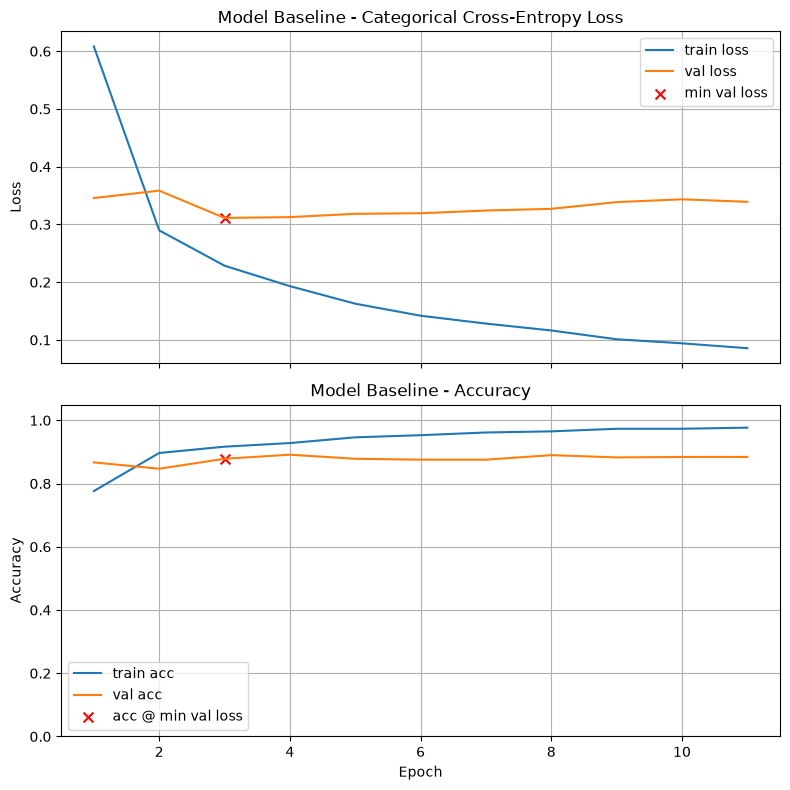

Final Training Loss:            0.0856
Final Training Accuracy:        0.9768
Final Validation Loss:          0.3392
Final Validation Accuracy:      0.8841
Minimum Validation Loss:        0.3113 (Epoch 3)
Validation Accuracy @ Min Loss: 0.8784

Test Loss: 0.2742
Test Accuracy: 0.9037

Validation-Test Gap (accuracy): 0.025346

Execution Time: 00:00:27


In [11]:
# Construct a fresh frozen MobileNetV2 backbone

base_model = make_base_model_pooled()

model_baseline = models.Sequential([
    base_model,
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_baseline, title="Model Baseline")

### Problem 1 — Frozen MobileNetV2 (Feature Extractor): Redesign the Head

**Goal.** Keep the MobileNetV2 backbone **frozen** and try to improve accuracy by modifying **only the classification head**.

**Setup.**

```python
base = make_base_model_pooled(
    trainable=False
)  # MobileNetV2(include_top=False, pooling="avg")
```

This backbone already applies **Global Average Pooling** and outputs a **1280-D feature vector** for each image.

Do **not** unfreeze any backbone layers, and do **not** add another pooling layer.

### To Do

1. **Ask an AI helper** (e.g., ChatGPT):

   *“What are some more complex classification heads that could improve this model on the Intel Image Classification Dataset, without unfreezing the MobileNetV2 backbone?”*

2. **Implement at least three different head designs.** These may be AI-suggested or inspired by techniques used in HW4.

3. **Experiment with hyperparameters** for the different designs, such as:

   * learning rate
   * `EarlyStopping` settings
   * Dropout and/or L2 regularization
   * `ReduceLROnPlateau` on or off

4. **Train and compare** the three head designs using a reduced value of `DATA_FRACTION`.

   Use these runs to compare architectures and training behavior and to narrow down a reasonable final configuration.

5. **Select one configuration**, set:

```python
DATA_FRACTION = 1.0
```

and rerun the notebook on the full dataset. Use this full-data run when answering the graded questions.

6. **Answer the graded questions.**

### Notes / Constraints

* With `pooling="avg"`, the backbone output has shape **(None, 1280)**, so **do not add `GlobalAveragePooling2D()`** to the head.
* `BatchNormalization` may be used within the classification head.
* Keep the entire MobileNetV2 backbone frozen for all experiments in this problem.
* Construct a **new backbone/model for each experiment** so that experiments do not inherit weights from previous runs.
* Small shifts in relative performance between reduced-data experiments and the full dataset are expected.



/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Regularized Single-Stage MLP with Patience (5), ReduceLROnPlateau

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.8336 - loss: 0.5203 - val_accuracy: 0.8670 - val_loss: 0.4440 - learning_rate: 0.0010
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9252 - loss: 0.2634 - val_accuracy: 0.8841 - val_loss: 0.4034 - learning_rate: 0.0010
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9462 - loss: 0.2085 - val_accuracy: 0.8770 - val_loss: 0.4085 - learning_rate: 0.0010
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9629 - loss: 0.1704 - val_accuracy: 0.8827 - val_loss: 0.4049 - learning_rate: 0.0010
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9765 - loss: 0.1346
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9765 - loss: 0.1346 - val_accuracy: 0.8870 - val_loss: 0.4076 - learning_rate: 0.0010
Epoch 6/500
88/88 

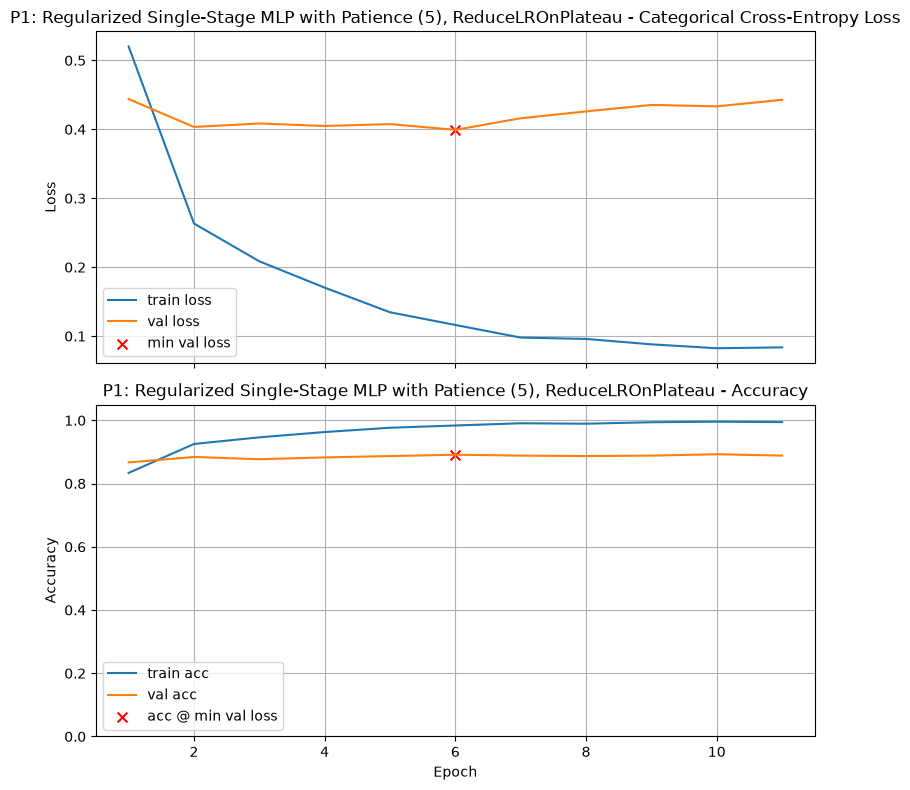

Final Training Loss:            0.0837
Final Training Accuracy:        0.9943
Final Validation Loss:          0.4429
Final Validation Accuracy:      0.8884
Minimum Validation Loss:        0.3993 (Epoch 6)
Validation Accuracy @ Min Loss: 0.8913

Test Loss: 0.3358
Test Accuracy: 0.8957

Validation-Test Gap (accuracy): 0.004449

Execution Time: 00:00:30


In [12]:
# Construct a fresh frozen MobileNetV2 backbone

base_model1 = make_base_model_pooled()

model_reg_single_stage_MLP = models.Sequential([
    base_model1,
    Dense(256, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.35),
    Dense(num_classes, activation='softmax', kernel_regularizer=l2reg)  # use your Intel num_classes (6)
])

train_and_test(model_reg_single_stage_MLP, patience=5, callbacks=[reduce_lr], title="P1: Regularized Single-Stage MLP with Patience (5), ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel with l2reg, LR (5e-4), Patience (6), ReduceLROnPlateau

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.7752 - loss: 0.7854 - val_accuracy: 0.8884 - val_loss: 0.4480 - learning_rate: 5.0000e-04
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8896 - loss: 0.4402 - val_accuracy: 0.8941 - val_loss: 0.4360 - learning_rate: 5.0000e-04
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9170 - loss: 0.3694 - val_accuracy: 0.8927 - val_loss: 0.4329 - learning_rate: 5.0000e-04
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9373 - loss: 0.3167 - val_accuracy: 0.8870 - val_loss: 0.4414 - learning_rate: 5.0000e-04
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9544 - loss: 0.2861 - val_accuracy: 0.8870 - val_loss: 0.4396 - learning_rate: 5.0000e-04
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9622 - loss: 0.2513
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00

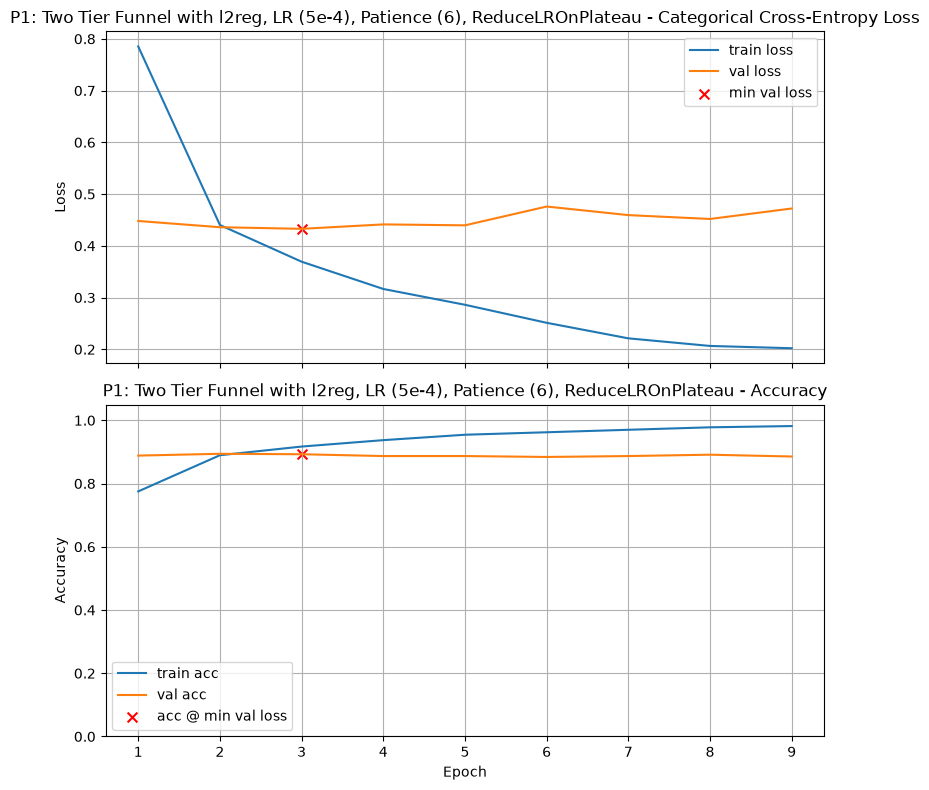

Final Training Loss:            0.2021
Final Training Accuracy:        0.9818
Final Validation Loss:          0.4721
Final Validation Accuracy:      0.8856
Minimum Validation Loss:        0.4329 (Epoch 3)
Validation Accuracy @ Min Loss: 0.8927

Test Loss: 0.3791
Test Accuracy: 0.9104

Validation-Test Gap (accuracy): 0.017724

Execution Time: 00:00:29


In [13]:
# Construct a fresh frozen MobileNetV2 backbone

base_model2 = make_base_model_pooled()

model_two_tier_funnel = models.Sequential([
    base_model2,
    Dense(512, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel, lr_schedule=5e-4, patience=6, callbacks=[reduce_lr], title="P1: Two Tier Funnel with l2reg, LR (5e-4), Patience (6), ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Minimal Regularization with BatchNorm, DO (0.5), final dense (k_reg: l2(5e-4))

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.6740 - loss: 0.9784 - val_accuracy: 0.8627 - val_loss: 0.3904
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8432 - loss: 0.4719 - val_accuracy: 0.8641 - val_loss: 0.3487
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8750 - loss: 0.3807 - val_accuracy: 0.8770 - val_loss: 0.3506
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8942 - loss: 0.3293 - val_accuracy: 0.8784 - val_loss: 0.3376
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8910 - loss: 0.3123 - val_accuracy: 0.8827 - val_loss: 0.3371
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8978 - loss: 0.2923 - val_accuracy: 0.8841 - val_loss: 0.3389
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9099 - loss: 0.2713 - val_accuracy: 0.8813 - val_loss: 0.3471
Epoch 8/500
88/88 ━

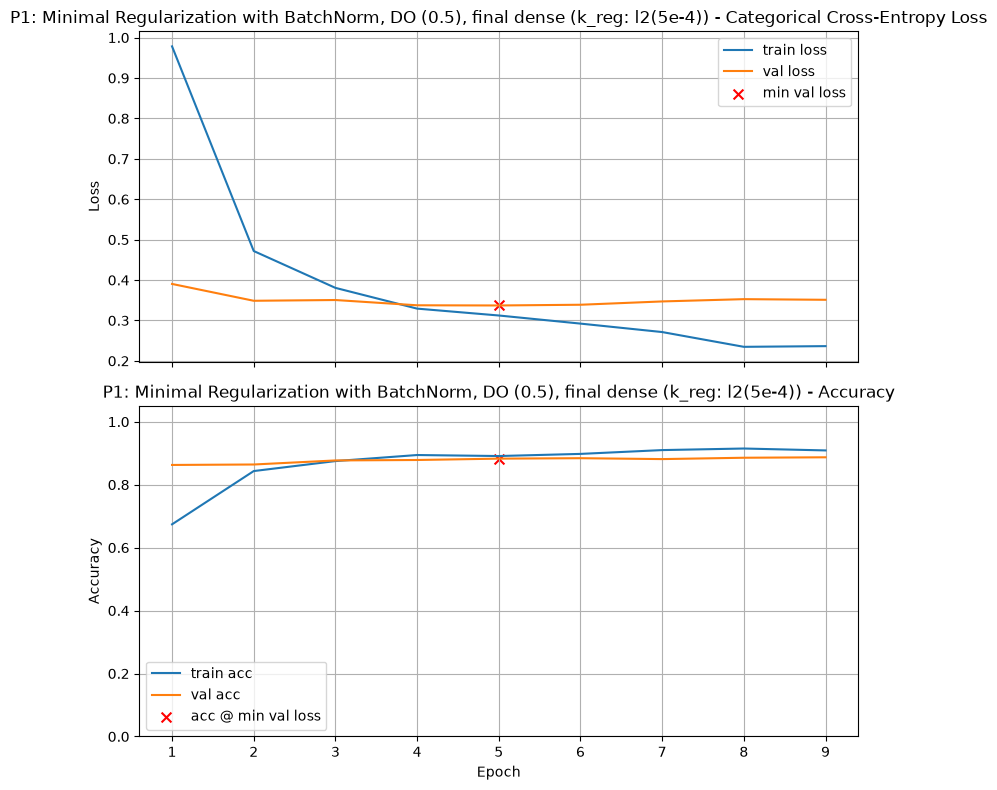

Final Training Loss:            0.2365
Final Training Accuracy:        0.9088
Final Validation Loss:          0.3512
Final Validation Accuracy:      0.8870
Minimum Validation Loss:        0.3371 (Epoch 5)
Validation Accuracy @ Min Loss: 0.8827

Test Loss: 0.2719
Test Accuracy: 0.9064

Validation-Test Gap (accuracy): 0.023728

Execution Time: 00:00:24


In [14]:
# Construct a fresh frozen MobileNetV2 backbone

base_model3 = make_base_model_pooled()

model_minimal_reg = models.Sequential([
    base_model3,
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax', kernel_regularizer=regularizers.l2(5e-4))  # use your Intel num_classes (6)
])

train_and_test(model_minimal_reg, patience=4, title="P1: Minimal Regularization with BatchNorm, DO (0.5), final dense (k_reg: l2(5e-4))")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8), ReduceLROnPlateau

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.7100 - loss: 0.9904 - val_accuracy: 0.8612 - val_loss: 0.5156 - learning_rate: 5.0000e-04
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8774 - loss: 0.5506 - val_accuracy: 0.8884 - val_loss: 0.4633 - learning_rate: 5.0000e-04
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9042 - loss: 0.4540 - val_accuracy: 0.8841 - val_loss: 0.4593 - learning_rate: 5.0000e-04
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9241 - loss: 0.3972 - val_accuracy: 0.8898 - val_loss: 0.4543 - learning_rate: 5.0000e-04
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9334 - loss: 0.3552 - val_accuracy: 0.8841 - val_loss: 0.4671 - learning_rate: 5.0000e-04
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9466 - loss: 0.3157 - val_accuracy: 0.8898 - val_loss: 0.4618 - learning_ra

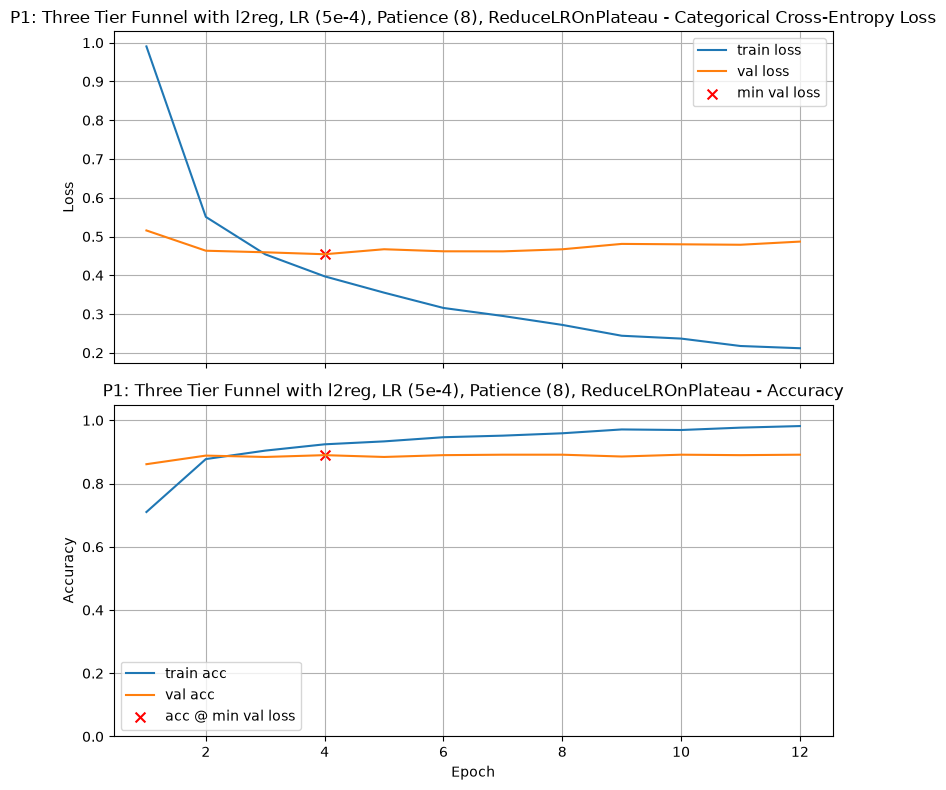

Final Training Loss:            0.2118
Final Training Accuracy:        0.9818
Final Validation Loss:          0.4869
Final Validation Accuracy:      0.8913
Minimum Validation Loss:        0.4543 (Epoch 4)
Validation Accuracy @ Min Loss: 0.8898

Test Loss: 0.4017
Test Accuracy: 0.9091

Validation-Test Gap (accuracy): 0.019248

Execution Time: 00:00:40


In [15]:
# Construct a fresh frozen MobileNetV2 backbone

base_model4 = make_base_model_pooled()

model_three_tier_funnel = models.Sequential([
    base_model4,
    Dense(512, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(64, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.1),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_three_tier_funnel, lr_schedule=5e-4, patience=8, callbacks=[reduce_lr], title="P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8), ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel with l2reg, LR (5e-4), Patience (6)

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.7852 - loss: 0.7511 - val_accuracy: 0.8898 - val_loss: 0.4579
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8985 - loss: 0.4321 - val_accuracy: 0.8741 - val_loss: 0.4676
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9184 - loss: 0.3639 - val_accuracy: 0.8884 - val_loss: 0.4424
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9362 - loss: 0.3178 - val_accuracy: 0.8870 - val_loss: 0.4623
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9562 - loss: 0.2765 - val_accuracy: 0.8970 - val_loss: 0.4427
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9637 - loss: 0.2474 - val_accuracy: 0.8984 - val_loss: 0.4510
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9729 - loss: 0.2166 - val_accuracy: 0.8941 - val_loss: 0.4660
Epoch 8/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms

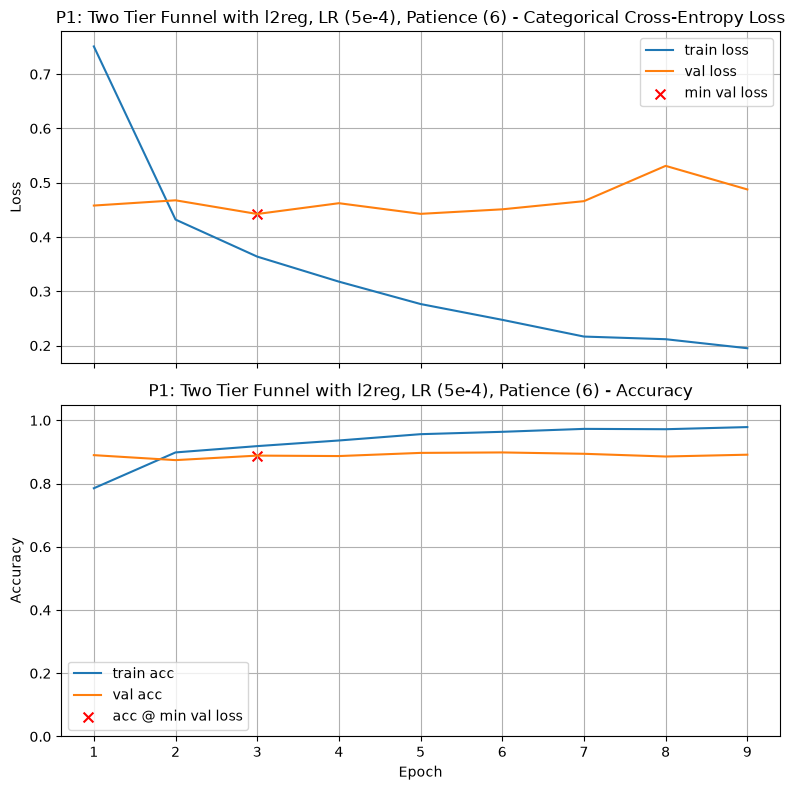

Final Training Loss:            0.1951
Final Training Accuracy:        0.9786
Final Validation Loss:          0.4876
Final Validation Accuracy:      0.8913
Minimum Validation Loss:        0.4424 (Epoch 3)
Validation Accuracy @ Min Loss: 0.8884

Test Loss: 0.3946
Test Accuracy: 0.9064

Validation-Test Gap (accuracy): 0.018005

Execution Time: 00:00:29


In [16]:
# Construct a fresh frozen MobileNetV2 backbone

base_model5 = make_base_model_pooled()

model_two_tier_funnel2 = models.Sequential([
    base_model5,
    Dense(512, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel2, lr_schedule=5e-4, patience=6, title="P1: Two Tier Funnel with l2reg, LR (5e-4), Patience (6)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8)

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.7040 - loss: 1.0167 - val_accuracy: 0.8870 - val_loss: 0.4949
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8732 - loss: 0.5684 - val_accuracy: 0.8941 - val_loss: 0.4659
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9063 - loss: 0.4596 - val_accuracy: 0.8970 - val_loss: 0.4477
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9131 - loss: 0.4145 - val_accuracy: 0.8970 - val_loss: 0.4495
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9284 - loss: 0.3603 - val_accuracy: 0.8970 - val_loss: 0.4580
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9401 - loss: 0.3316 - val_accuracy: 0.8870 - val_loss: 0.4684
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9487 - loss: 0.3058 - val_accuracy: 0.8970 - val_loss: 0.4749
Epoch 8/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9633 - loss: 0.2677 - val_accuracy: 0.8970 - val_l

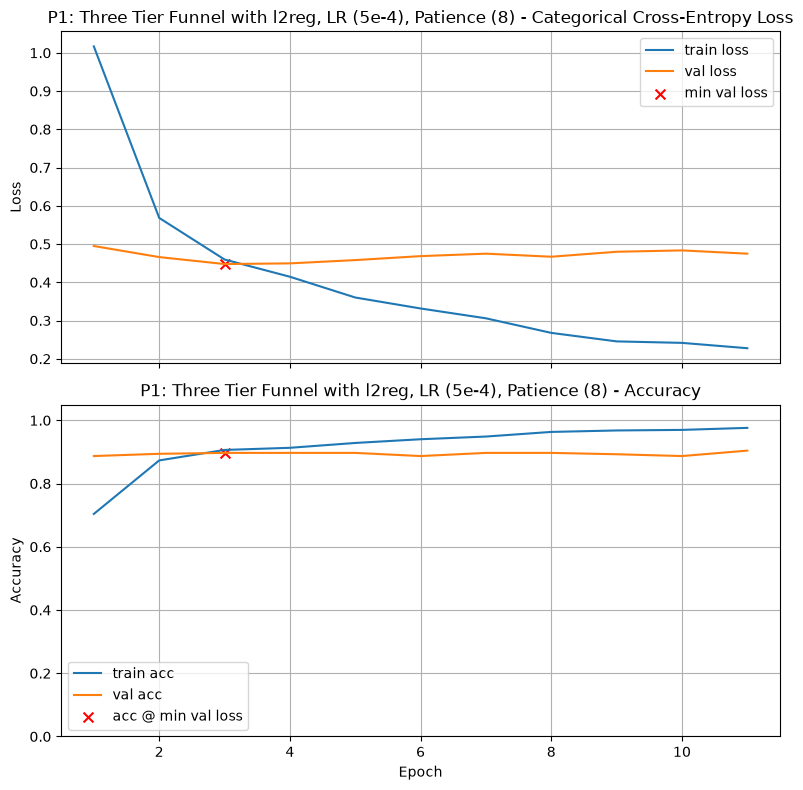

Final Training Loss:            0.2276
Final Training Accuracy:        0.9761
Final Validation Loss:          0.4749
Final Validation Accuracy:      0.9041
Minimum Validation Loss:        0.4477 (Epoch 3)
Validation Accuracy @ Min Loss: 0.8970

Test Loss: 0.4126
Test Accuracy: 0.9104

Validation-Test Gap (accuracy): 0.013432

Execution Time: 00:00:38


In [17]:
# Construct a fresh frozen MobileNetV2 backbone

base_model6 = make_base_model_pooled()

model_three_tier_funnel2 = models.Sequential([
    base_model6,
    Dense(512, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(64, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.1),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_three_tier_funnel2, lr_schedule=5e-4, patience=8, title="P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Regularized Single-Stage MLP with Patience (6), ReduceLROnPlateau

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.8333 - loss: 0.5179 - val_accuracy: 0.8827 - val_loss: 0.4080 - learning_rate: 0.0010
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9238 - loss: 0.2632 - val_accuracy: 0.8827 - val_loss: 0.3744 - learning_rate: 0.0010
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9508 - loss: 0.2025 - val_accuracy: 0.8927 - val_loss: 0.3860 - learning_rate: 0.0010
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9583 - loss: 0.1698 - val_accuracy: 0.8884 - val_loss: 0.4002 - learning_rate: 0.0010
Epoch 5/500
87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9709 - loss: 0.1405
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9708 - loss: 0.1408 - val_accuracy: 0.8870 - val_loss: 0.4247 - learning_rate: 0.0010
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9793 - loss: 0.1208 - val_accuracy: 

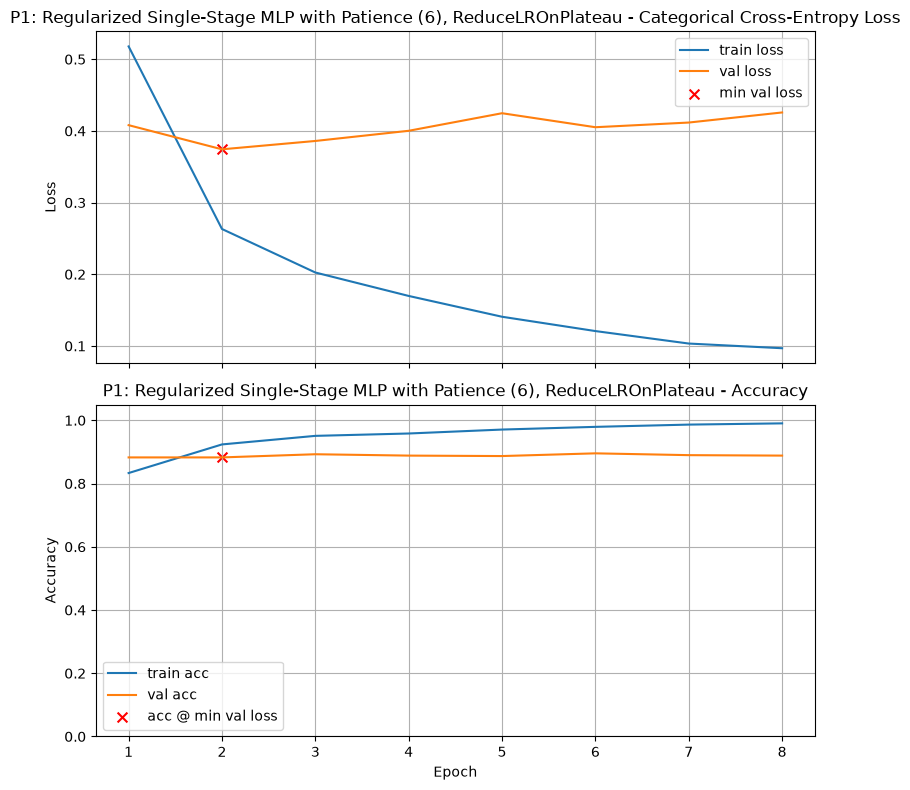

Final Training Loss:            0.0969
Final Training Accuracy:        0.9904
Final Validation Loss:          0.4258
Final Validation Accuracy:      0.8884
Minimum Validation Loss:        0.3744 (Epoch 2)
Validation Accuracy @ Min Loss: 0.8827

Test Loss: 0.3322
Test Accuracy: 0.8971

Validation-Test Gap (accuracy): 0.014369

Execution Time: 00:00:24


In [18]:
# Construct a fresh frozen MobileNetV2 backbone

base_model7 = make_base_model_pooled()

model_reg_single_stage_MLP2 = models.Sequential([
    base_model7,
    Dense(256, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.35),
    Dense(num_classes, activation='softmax', kernel_regularizer=l2reg)  # use your Intel num_classes (6)
])

train_and_test(model_reg_single_stage_MLP2, patience=6, callbacks=[reduce_lr], title="P1: Regularized Single-Stage MLP with Patience (6), ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Minimal with BatchNorm, DO (0.5)

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.6783 - loss: 0.9976 - val_accuracy: 0.8455 - val_loss: 0.3833
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8543 - loss: 0.4399 - val_accuracy: 0.8698 - val_loss: 0.3357
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8653 - loss: 0.3712 - val_accuracy: 0.8827 - val_loss: 0.3184
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8785 - loss: 0.3342 - val_accuracy: 0.8870 - val_loss: 0.3262
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9006 - loss: 0.2743 - val_accuracy: 0.8841 - val_loss: 0.3216
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9063 - loss: 0.2642 - val_accuracy: 0.8813 - val_loss: 0.3260
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9052 - loss: 0.2634 - val_accuracy: 0.8856 - val_loss: 0.3271
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 3.


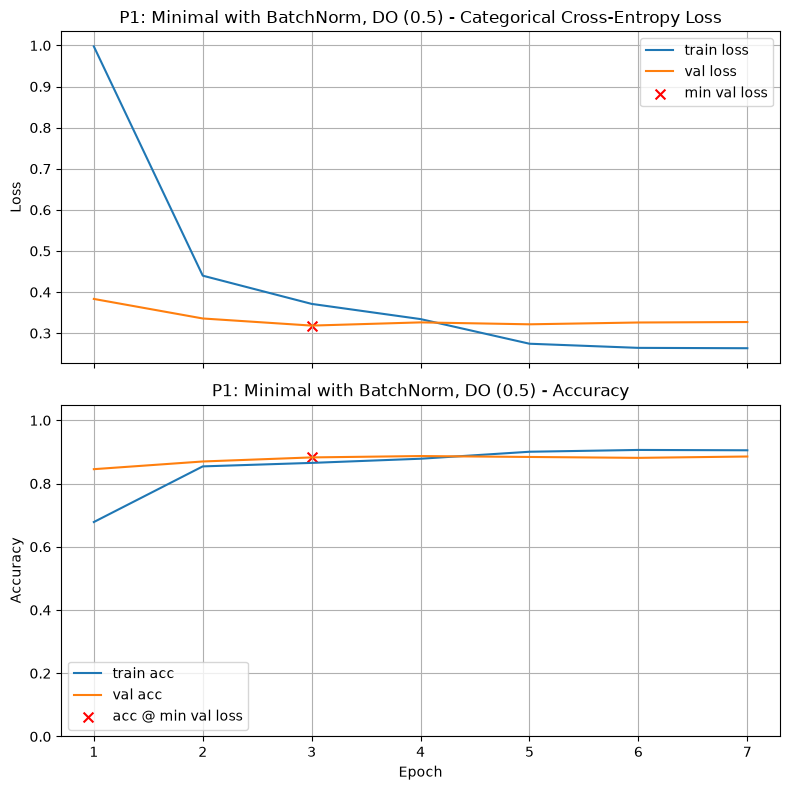

Final Training Loss:            0.2634
Final Training Accuracy:        0.9052
Final Validation Loss:          0.3271
Final Validation Accuracy:      0.8856
Minimum Validation Loss:        0.3184 (Epoch 3)
Validation Accuracy @ Min Loss: 0.8827

Test Loss: 0.3175
Test Accuracy: 0.8917

Validation-Test Gap (accuracy): 0.009022

Execution Time: 00:00:21


In [19]:
# Construct a fresh frozen MobileNetV2 backbone

base_model8 = make_base_model_pooled()

model_minimal = models.Sequential([
    base_model8,
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_minimal, patience=4, title="P1: Minimal with BatchNorm, DO (0.5)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel (no reg), LR (5e-4), Patience (6), ReduceLROnPlateau

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.7848 - loss: 0.6200 - val_accuracy: 0.8755 - val_loss: 0.3489 - learning_rate: 5.0000e-04
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8988 - loss: 0.2946 - val_accuracy: 0.9013 - val_loss: 0.3019 - learning_rate: 5.0000e-04
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9248 - loss: 0.2262 - val_accuracy: 0.8970 - val_loss: 0.3100 - learning_rate: 5.0000e-04
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9426 - loss: 0.1782 - val_accuracy: 0.8913 - val_loss: 0.3300 - learning_rate: 5.0000e-04
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9483 - loss: 0.1487
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9483 - loss: 0.1487 - val_accuracy: 0.8927 - val_loss: 0.3106 - learning_rate: 5.0000e-04
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9651 - loss: 0.1

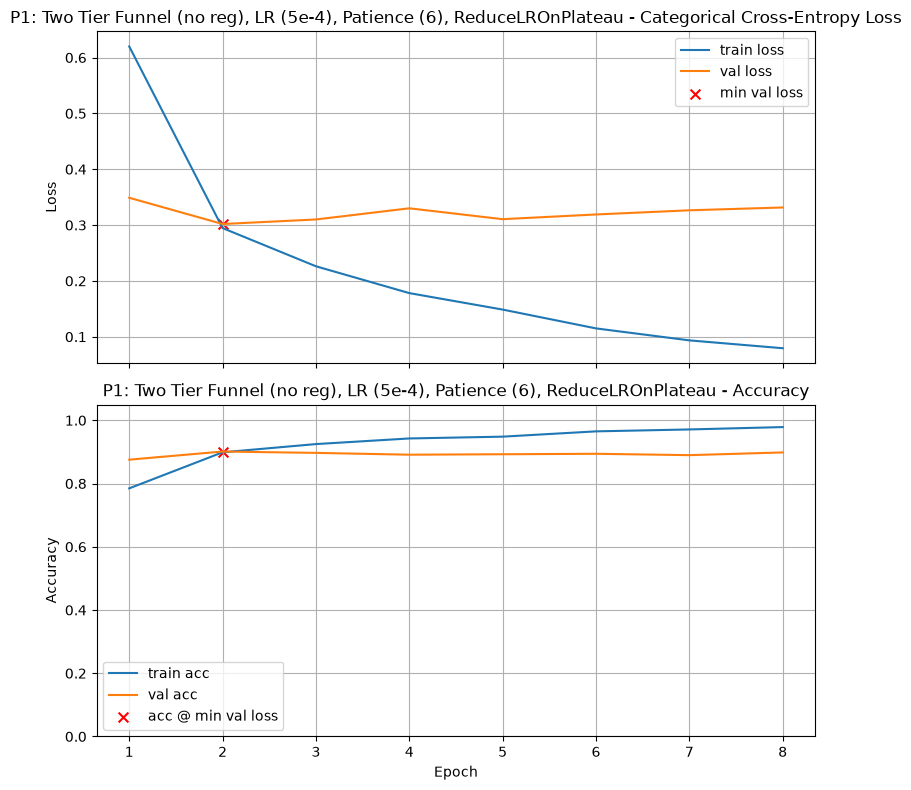

Final Training Loss:            0.0794
Final Training Accuracy:        0.9786
Final Validation Loss:          0.3315
Final Validation Accuracy:      0.8984
Minimum Validation Loss:        0.3019 (Epoch 2)
Validation Accuracy @ Min Loss: 0.9013

Test Loss: 0.2702
Test Accuracy: 0.8997

Validation-Test Gap (accuracy): 0.001555

Execution Time: 00:00:29


In [20]:
# Construct a fresh frozen MobileNetV2 backbone

base_model9 = make_base_model_pooled()

model_two_tier_funnel_no_reg = models.Sequential([
    base_model9,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel_no_reg, lr_schedule=5e-4, patience=6, callbacks=[reduce_lr], title="P1: Two Tier Funnel (no reg), LR (5e-4), Patience (6), ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel (no reg), LR (5e-4), Patience (6)

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.7966 - loss: 0.6013 - val_accuracy: 0.8813 - val_loss: 0.3246
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9027 - loss: 0.2821 - val_accuracy: 0.8927 - val_loss: 0.2929
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9216 - loss: 0.2250 - val_accuracy: 0.8870 - val_loss: 0.3087
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9430 - loss: 0.1725 - val_accuracy: 0.8999 - val_loss: 0.3048
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9590 - loss: 0.1348 - val_accuracy: 0.8970 - val_loss: 0.3278
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9605 - loss: 0.1192 - val_accuracy: 0.8927 - val_loss: 0.3271
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9740 - loss: 0.0913 - val_accuracy: 0.8941 - val_loss: 0.3498
Epoch 8/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9733 - loss: 0.0837 - val_accuracy: 0.8856 - val_

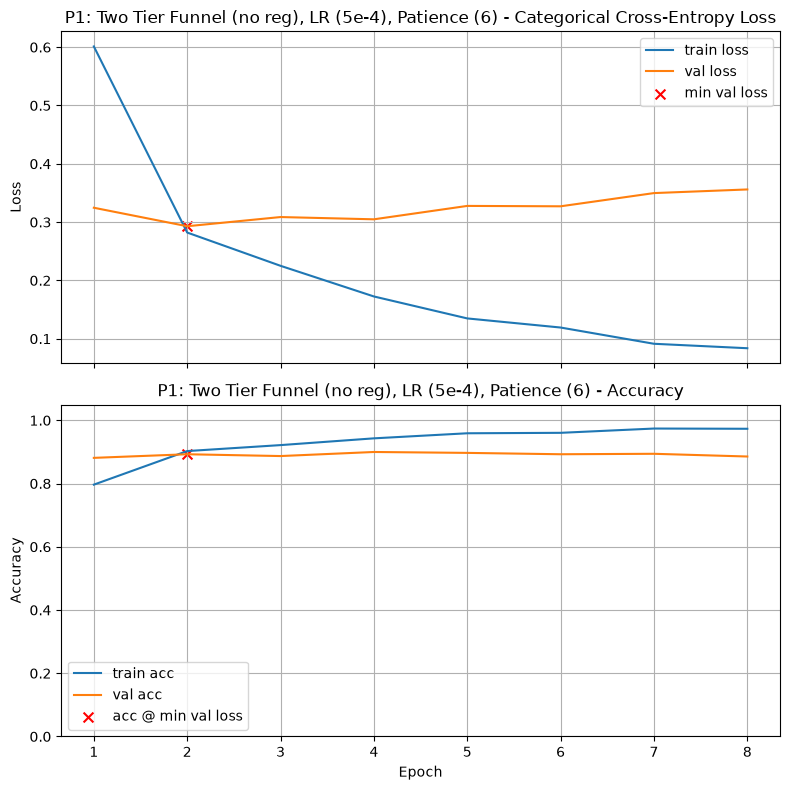

Final Training Loss:            0.0837
Final Training Accuracy:        0.9733
Final Validation Loss:          0.3560
Final Validation Accuracy:      0.8856
Minimum Validation Loss:        0.2929 (Epoch 2)
Validation Accuracy @ Min Loss: 0.8927

Test Loss: 0.2482
Test Accuracy: 0.9051

Validation-Test Gap (accuracy): 0.012376

Execution Time: 00:00:29


In [21]:
# Construct a fresh frozen MobileNetV2 backbone

base_model10 = make_base_model_pooled()

model_two_tier_funnel_no_reg2 = models.Sequential([
    base_model10,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel_no_reg2, lr_schedule=5e-4, patience=6, title="P1: Two Tier Funnel (no reg), LR (5e-4), Patience (6)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Three Tier Funnel (no reg), LR (5e-4), Patience (8)

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step - accuracy: 0.7121 - loss: 0.8358 - val_accuracy: 0.8755 - val_loss: 0.3884
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8771 - loss: 0.3998 - val_accuracy: 0.8898 - val_loss: 0.3201
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9031 - loss: 0.3055 - val_accuracy: 0.8956 - val_loss: 0.3082
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9177 - loss: 0.2571 - val_accuracy: 0.9027 - val_loss: 0.3030
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9305 - loss: 0.2100 - val_accuracy: 0.8856 - val_loss: 0.3329
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9505 - loss: 0.1742 - val_accuracy: 0.8898 - val_loss: 0.3270
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9523 - loss: 0.1494 - val_accuracy: 0.8898 - val_loss: 0.3504
Epoch 8/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32m

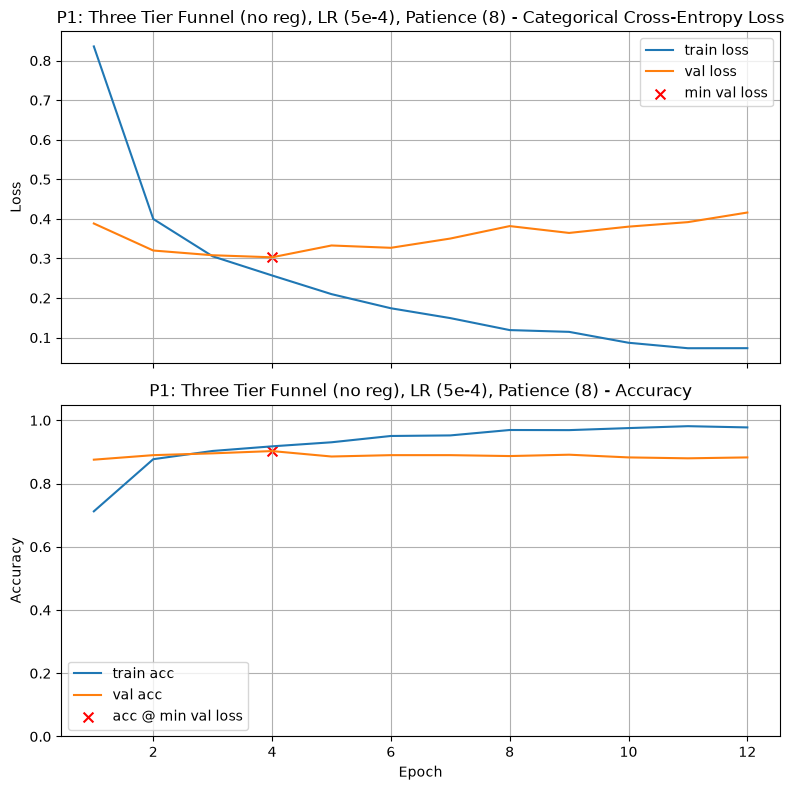

Final Training Loss:            0.0734
Final Training Accuracy:        0.9776
Final Validation Loss:          0.4161
Final Validation Accuracy:      0.8827
Minimum Validation Loss:        0.3030 (Epoch 4)
Validation Accuracy @ Min Loss: 0.9027

Test Loss: 0.2629
Test Accuracy: 0.9024

Validation-Test Gap (accuracy): 0.000312

Execution Time: 00:00:43


In [22]:
# Construct a fresh frozen MobileNetV2 backbone

base_model11 = make_base_model_pooled()

model_three_tier_funnel_no_reg = models.Sequential([
    base_model11,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(64),
    BatchNormalization(),
    ReLU(),
    Dropout(0.1),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_three_tier_funnel_no_reg, lr_schedule=5e-4, patience=8, title="P1: Three Tier Funnel (no reg), LR (5e-4), Patience (8)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Three Tier Funnel (no reg), LR (5e-4), Patience (8), ReduceLROnPlateau

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step - accuracy: 0.7253 - loss: 0.8205 - val_accuracy: 0.8798 - val_loss: 0.3674 - learning_rate: 5.0000e-04
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8810 - loss: 0.3973 - val_accuracy: 0.8941 - val_loss: 0.3288 - learning_rate: 5.0000e-04
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9074 - loss: 0.3063 - val_accuracy: 0.8841 - val_loss: 0.3317 - learning_rate: 5.0000e-04
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9273 - loss: 0.2412 - val_accuracy: 0.8913 - val_loss: 0.3278 - learning_rate: 5.0000e-04
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9419 - loss: 0.1990 - val_accuracy: 0.8884 - val_loss: 0.3159 - learning_rate: 5.0000e-04
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9476 - loss: 0.1649 - val_accuracy: 0.8884 - val_loss: 0.3377 - learning_rat

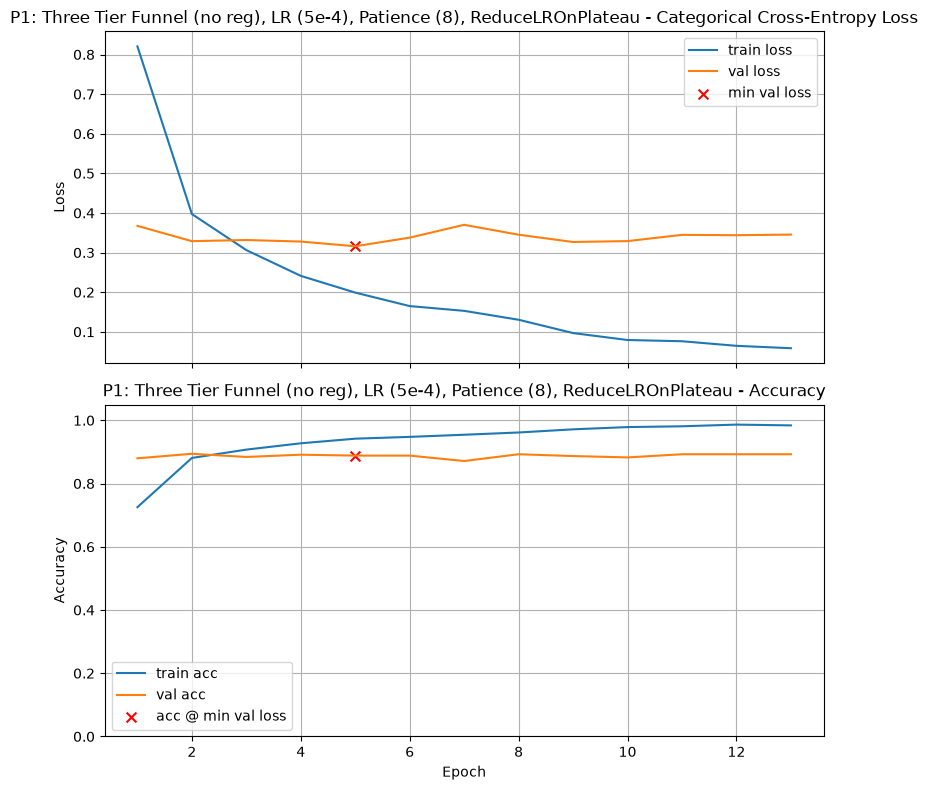

Final Training Loss:            0.0585
Final Training Accuracy:        0.9840
Final Validation Loss:          0.3454
Final Validation Accuracy:      0.8927
Minimum Validation Loss:        0.3159 (Epoch 5)
Validation Accuracy @ Min Loss: 0.8884

Test Loss: 0.2600
Test Accuracy: 0.9064

Validation-Test Gap (accuracy): 0.018005

Execution Time: 00:00:45


In [23]:
# Construct a fresh frozen MobileNetV2 backbone

base_model12 = make_base_model_pooled()

model_three_tier_funnel_no_reg2 = models.Sequential([
    base_model12,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(64),
    BatchNormalization(),
    ReLU(),
    Dropout(0.1),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_three_tier_funnel_no_reg2, lr_schedule=5e-4, patience=8, callbacks=[reduce_lr], title="P1: Three Tier Funnel (no reg), LR (5e-4), Patience (8), ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel (no reg), LR (1e-4), Patience (6)

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.5704 - loss: 1.1692 - val_accuracy: 0.8011 - val_loss: 0.5846
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8212 - loss: 0.5571 - val_accuracy: 0.8698 - val_loss: 0.3998
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8522 - loss: 0.4443 - val_accuracy: 0.8827 - val_loss: 0.3541
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8764 - loss: 0.3769 - val_accuracy: 0.8898 - val_loss: 0.3362
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8921 - loss: 0.3325 - val_accuracy: 0.8970 - val_loss: 0.3231
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8999 - loss: 0.3012 - val_accuracy: 0.9027 - val_loss: 0.3124
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9124 - loss: 0.2695 - val_accuracy: 0.9084 - val_loss: 0.3058
Epoch 8/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/

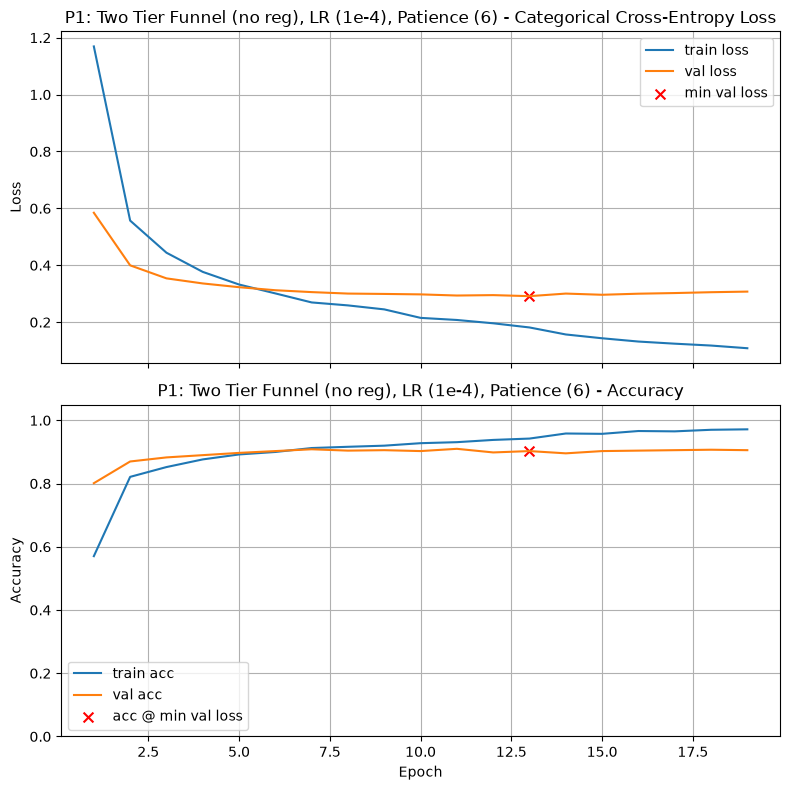

Final Training Loss:            0.1085
Final Training Accuracy:        0.9715
Final Validation Loss:          0.3075
Final Validation Accuracy:      0.9056
Minimum Validation Loss:        0.2915 (Epoch 13)
Validation Accuracy @ Min Loss: 0.9027

Test Loss: 0.2577
Test Accuracy: 0.9037

Validation-Test Gap (accuracy): 0.001025

Execution Time: 00:00:57


In [24]:
# Construct a fresh frozen MobileNetV2 backbone

base_model13 = make_base_model_pooled()

model_two_tier_funnel_no_reg3 = models.Sequential([
    base_model13,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel_no_reg3, lr_schedule=1e-4, patience=6, title="P1: Two Tier Funnel (no reg), LR (1e-4), Patience (6)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8)

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - accuracy: 0.5789 - loss: 1.1587 - val_accuracy: 0.8398 - val_loss: 0.5723
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8219 - loss: 0.5661 - val_accuracy: 0.8827 - val_loss: 0.4019
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8628 - loss: 0.4359 - val_accuracy: 0.8927 - val_loss: 0.3532
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8796 - loss: 0.3733 - val_accuracy: 0.8970 - val_loss: 0.3323
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8945 - loss: 0.3242 - val_accuracy: 0.8984 - val_loss: 0.3192
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9045 - loss: 0.2960 - val_accuracy: 0.8913 - val_loss: 0.3147
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9220 - loss: 0.2629 - val_accuracy: 0.8956 - val_loss: 0.3082
Epoch 8/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/

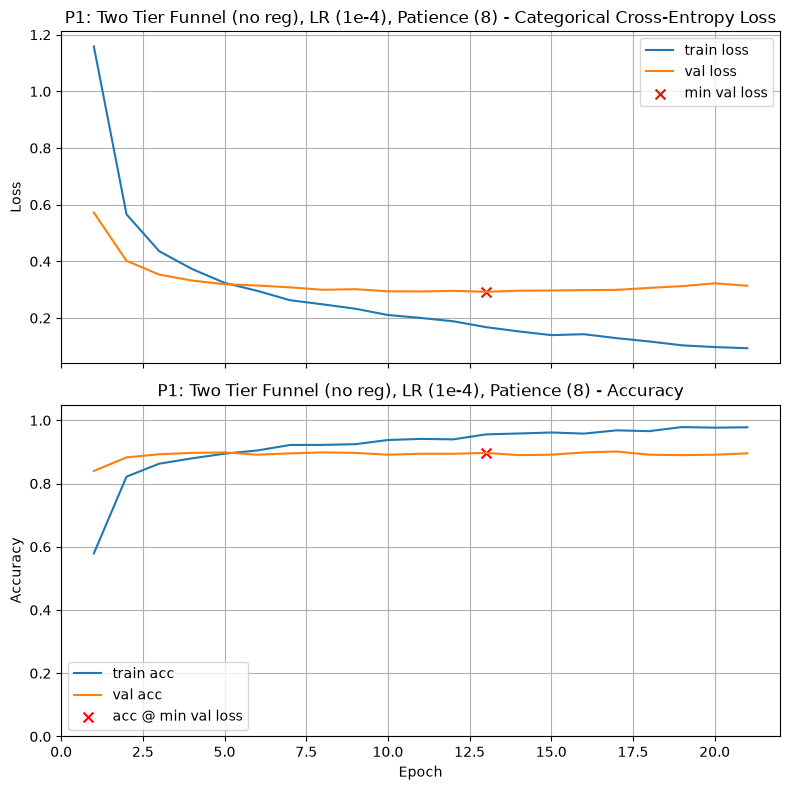

Final Training Loss:            0.0933
Final Training Accuracy:        0.9779
Final Validation Loss:          0.3139
Final Validation Accuracy:      0.8956
Minimum Validation Loss:        0.2926 (Epoch 13)
Validation Accuracy @ Min Loss: 0.8970

Test Loss: 0.2538
Test Accuracy: 0.8997

Validation-Test Gap (accuracy): 0.002737

Execution Time: 00:01:03


In [25]:
# Construct a fresh frozen MobileNetV2 backbone

base_model14 = make_base_model_pooled()

model_two_tier_funnel_no_reg4 = models.Sequential([
    base_model14,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel_no_reg4, lr_schedule=1e-4, patience=8, title="P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8), ReduceLROnPlateau

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.5939 - loss: 1.1303 - val_accuracy: 0.8226 - val_loss: 0.5719 - learning_rate: 1.0000e-04
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8219 - loss: 0.5554 - val_accuracy: 0.8584 - val_loss: 0.4108 - learning_rate: 1.0000e-04
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8664 - loss: 0.4222 - val_accuracy: 0.8712 - val_loss: 0.3660 - learning_rate: 1.0000e-04
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8867 - loss: 0.3633 - val_accuracy: 0.8870 - val_loss: 0.3453 - learning_rate: 1.0000e-04
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8896 - loss: 0.3298 - val_accuracy: 0.8870 - val_loss: 0.3347 - learning_rate: 1.0000e-04
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9067 - loss: 0.2935 - val_accuracy: 0.8856 - val_loss: 0.3274 - learning_rate:

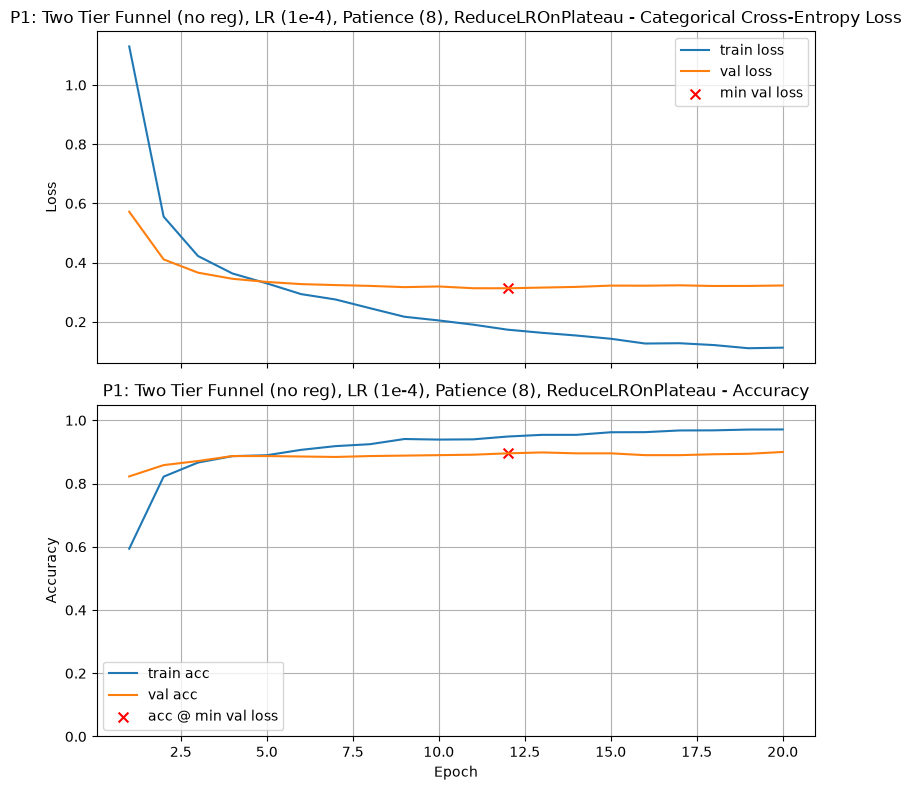

Final Training Loss:            0.1127
Final Training Accuracy:        0.9711
Final Validation Loss:          0.3227
Final Validation Accuracy:      0.8999
Minimum Validation Loss:        0.3133 (Epoch 12)
Validation Accuracy @ Min Loss: 0.8956

Test Loss: 0.2570
Test Accuracy: 0.9078

Validation-Test Gap (accuracy): 0.012189

Execution Time: 00:01:00


In [26]:
# Construct a fresh frozen MobileNetV2 backbone

base_model15 = make_base_model_pooled()

model_two_tier_funnel_no_reg5 = models.Sequential([
    base_model15,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel_no_reg5, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title="P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8), ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel with l2reg, LR (1e-4), Patience (8), ReduceLROnPlateau

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - accuracy: 0.6131 - loss: 1.1472 - val_accuracy: 0.8283 - val_loss: 0.6106 - learning_rate: 1.0000e-04
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8265 - loss: 0.6263 - val_accuracy: 0.8755 - val_loss: 0.4726 - learning_rate: 1.0000e-04
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8621 - loss: 0.5196 - val_accuracy: 0.8841 - val_loss: 0.4329 - learning_rate: 1.0000e-04
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8881 - loss: 0.4516 - val_accuracy: 0.8884 - val_loss: 0.4183 - learning_rate: 1.0000e-04
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8988 - loss: 0.4060 - val_accuracy: 0.8970 - val_loss: 0.4061 - learning_rate: 1.0000e-04
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9045 - loss: 0.3759 - val_accuracy: 0.8984 - val_loss: 0.4010 - learning_ra

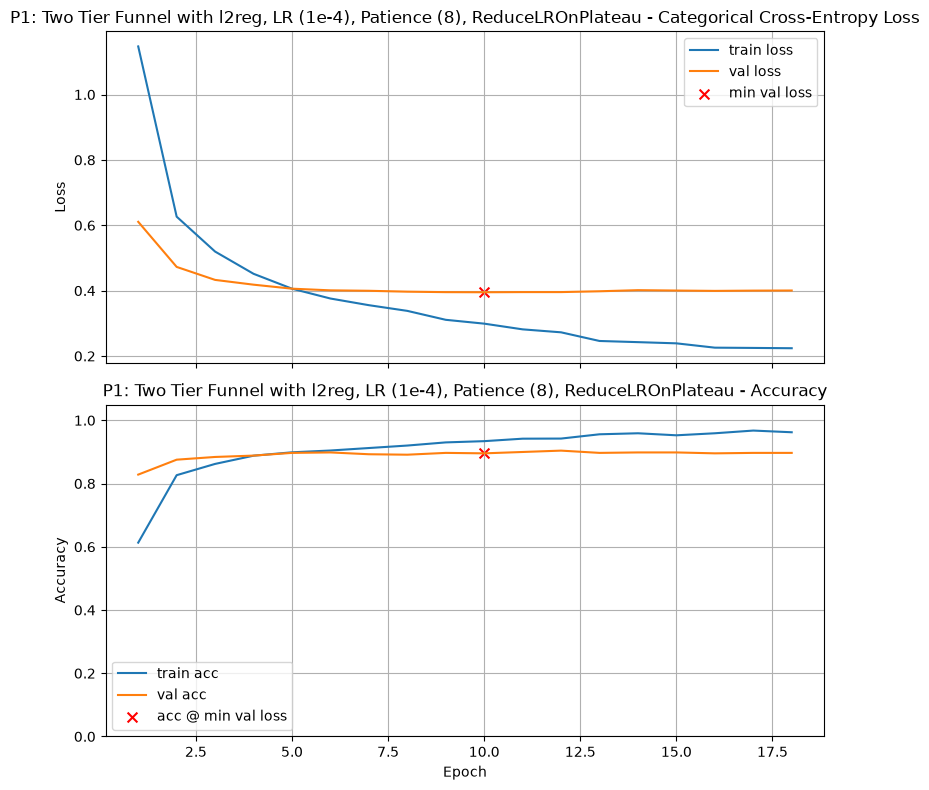

Final Training Loss:            0.2239
Final Training Accuracy:        0.9622
Final Validation Loss:          0.4004
Final Validation Accuracy:      0.8970
Minimum Validation Loss:        0.3951 (Epoch 10)
Validation Accuracy @ Min Loss: 0.8956

Test Loss: 0.3524
Test Accuracy: 0.9064

Validation-Test Gap (accuracy): 0.010852

Execution Time: 00:01:00


In [27]:
# Construct a fresh frozen MobileNetV2 backbone

base_model16 = make_base_model_pooled()

model_two_tier_funnel_with_reg = models.Sequential([
    base_model16,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel_with_reg, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title="P1: Two Tier Funnel with l2reg, LR (1e-4), Patience (8), ReduceLROnPlateau")

In [28]:
print_results()

P1: Three Tier Funnel (no reg), LR (5e-4), Patience (8)	0.9027	4
P1: Two Tier Funnel (no reg), LR (1e-4), Patience (6)	0.9027	13
P1: Two Tier Funnel (no reg), LR (5e-4), Patience (6), ReduceLROnPlateau	0.9013	2
P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8)	0.8970	3
P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8)	0.8970	13
P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8), ReduceLROnPlateau	0.8956	12
P1: Two Tier Funnel with l2reg, LR (1e-4), Patience (8), ReduceLROnPlateau	0.8956	10
P1: Two Tier Funnel with l2reg, LR (5e-4), Patience (6), ReduceLROnPlateau	0.8927	3
P1: Two Tier Funnel (no reg), LR (5e-4), Patience (6)	0.8927	2
P1: Regularized Single-Stage MLP with Patience (5), ReduceLROnPlateau	0.8913	6
P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8), ReduceLROnPlateau	0.8898	4
P1: Two Tier Funnel with l2reg, LR (5e-4), Patience (6)	0.8884	3
P1: Three Tier Funnel (no reg), LR (5e-4), Patience (8), ReduceLROnPlateau	0.8884	5
P1: Minimal Regularization wi

# Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which head architecture worked best for you, and what does that suggest about the role of head design and hyperparameters when the backbone is frozen?

**Instructions:**

- Write a single paragraph (3–5 sentences).
- Identify the head architecture and experiment that performed best.
- Briefly compare it with the other experiments, referring to specific design choices (e.g., dense layers, dropout) and hyperparameters (e.g., learning rate, ReduceLROnPlateau).
- Explain which of these differences you think were most important, based on your observed training and validation results.
- Conclude with what your experiments suggest about designing classification heads when the backbone is frozen.


**Your paragraph here (5pts):**

> The best head architecture was the unregularized two-tier funnel (Dense: 512 -> 128), which had a validation accuracy of 0.9119 at epoch 9 with a lower learning rate (1e-4) and default patience (8) and ReduceOnPlateau. The two-tier funnel approach consistently outperformed the baseline (0.8991) and single block (0.9019, 0.9051) designs showing that moderate depth results in greater accuracy rather than a more direct smaller head. Removing L2 regularization while using a lower learning rate and a moderate patience window proved to be the most decisive factors outside of the depth of the head. ReduceLROnPlateau produced mixed results in accuracy improvement, but pairing it with a lower learning rate gave the optimizer the ability to reach a higher overall validation accuracy. These results suggest that when transfer learning with a completely frozen backbone, classification heads benefit most from moderate depth (three tier seemed excessive) and non-regularized dense layers.

**Validation Accuracy here (15 pts):**

In [29]:
# Set a1 to the validation accuracy found by your best model for this problem. 

a1 = results['P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8), ReduceLROnPlateau'][0]             # Replace 0.0 with your answer

In [30]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1a in this problem         

print(f'a1 = {a1:.4f}') 


a1 = 0.8956


## Problem Two — Training MobileNetV2 with the Backbone Unfrozen

**Goal.** Use the architecture of one of your best heads from Problem 1, but now make the MobileNetV2 backbone trainable so that the entire network can adapt to the Intel Image dataset.

**Setup.** Build a new MobileNetV2 backbone with `trainable=True`. It already applies Global Average Pooling and outputs a 1280-D vector, so do not add another pooling layer.

```python
base = make_base_model_pooled(
    trainable=True
)  # MobileNetV2(include_top=False, pooling="avg")
```

### To Do

1. **Design at least three experiments** with the MobileNetV2 backbone fully unfrozen. Use the architecture of one of your best heads from Problem 1 and vary one or more of the following:

   * **Learning rate**
   * **EarlyStopping** parameters
   * **Regularization:** Dropout and/or L2
   * **ReduceLROnPlateau:** on vs. off

2. **Run and compare** the three experiments using a reduced value of `DATA_FRACTION`, focusing on:

   * training stability,
   * convergence behavior,
   * and validation performance trends.

   Use these runs to **narrow down reasonable configurations**, not to identify a single “optimal” setting.

3. **Select one configuration**, set `DATA_FRACTION = 1.0`, rerun the notebook to train on the full dataset, and use this run when answering the graded questions.

### Notes

* Training a pretrained backbone generally requires a **much smaller learning rate** than training only a new classification head. Values such as \(1\times10^{-5}\) to \(3\times10^{-5}\) are reasonable starting points.
* Small changes in relative performance between experiments using a reduced dataset and the full dataset are expected.
* Each experiment should construct a **new model** so that experiments do not inherit weights from previous runs.



/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base)

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 70s 524ms/step - accuracy: 0.5586 - loss: 1.2182 - val_accuracy: 0.8026 - val_loss: 0.6148 - learning_rate: 1.0000e-04
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 23s 263ms/step - accuracy: 0.8539 - loss: 0.4743 - val_accuracy: 0.8498 - val_loss: 0.4602 - learning_rate: 1.0000e-04
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 23s 266ms/step - accuracy: 0.9070 - loss: 0.3150 - val_accuracy: 0.8655 - val_loss: 0.4112 - learning_rate: 1.0000e-04
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 23s 266ms/step - accuracy: 0.9287 - loss: 0.2379 - val_accuracy: 0.8813 - val_loss: 0.3945 - learning_rate: 1.0000e-04
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 23s 266ms/step - accuracy: 0.9515 - loss: 0.1813 - val_accuracy: 0.8841 - val_loss: 0.3769 - learning_rate: 1.0000e-04
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 281ms/step - accuracy: 0.9669 - loss: 0.1430 - val_accuracy: 0.8856 - val_loss: 0.3847 - learning_rate: 1.0000e-04
Epoch 7/500
88/8

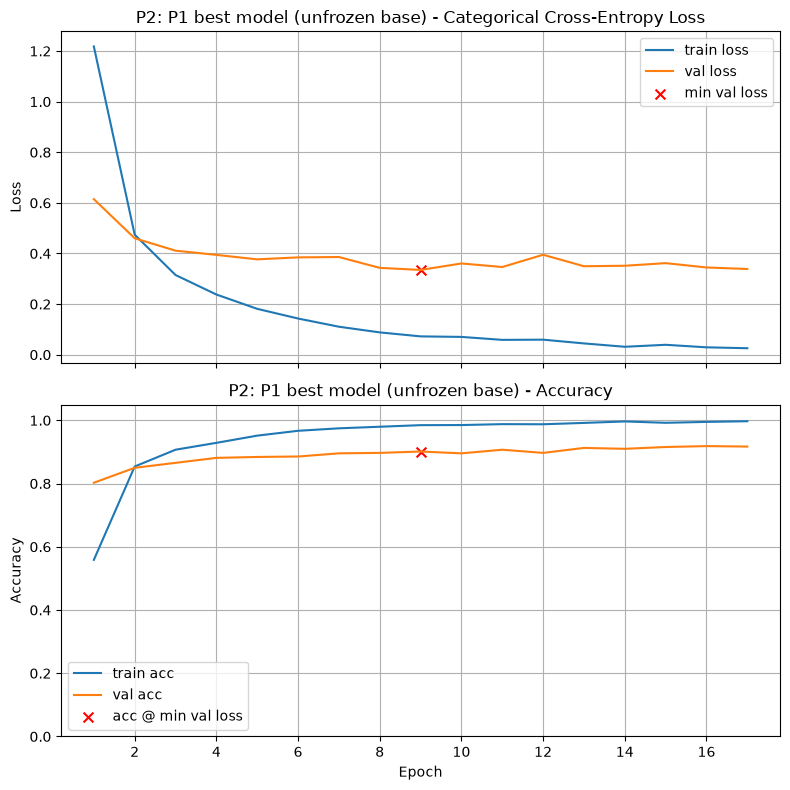

Final Training Loss:            0.0257
Final Training Accuracy:        0.9972
Final Validation Loss:          0.3388
Final Validation Accuracy:      0.9170
Minimum Validation Loss:        0.3350 (Epoch 9)
Validation Accuracy @ Min Loss: 0.9013

Test Loss: 0.3073
Test Accuracy: 0.9037

Validation-Test Gap (accuracy): 0.002456

Execution Time: 00:07:22


In [31]:
model_unfrozen_baseline = make_base_model_pooled(trainable=True)

p1_best = models.Sequential([
    model_unfrozen_baseline,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title="P2: P1 best model (unfrozen base)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - LR (1e-5)

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 82s 628ms/step - accuracy: 0.2127 - loss: 2.0634 - val_accuracy: 0.2890 - val_loss: 1.8848 - learning_rate: 1.0000e-05
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 284ms/step - accuracy: 0.3491 - loss: 1.7000 - val_accuracy: 0.4335 - val_loss: 1.4899 - learning_rate: 1.0000e-05
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 23s 266ms/step - accuracy: 0.4407 - loss: 1.4672 - val_accuracy: 0.5408 - val_loss: 1.2063 - learning_rate: 1.0000e-05
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 23s 261ms/step - accuracy: 0.5501 - loss: 1.2359 - val_accuracy: 0.6323 - val_loss: 0.9881 - learning_rate: 1.0000e-05
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 23s 267ms/step - accuracy: 0.6074 - loss: 1.0716 - val_accuracy: 0.6953 - val_loss: 0.8467 - learning_rate: 1.0000e-05
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 23s 265ms/step - accuracy: 0.6790 - loss: 0.9225 - val_accuracy: 0.7411 - val_loss: 0.7275 - learning_rate: 1.0000e-05
Epoc

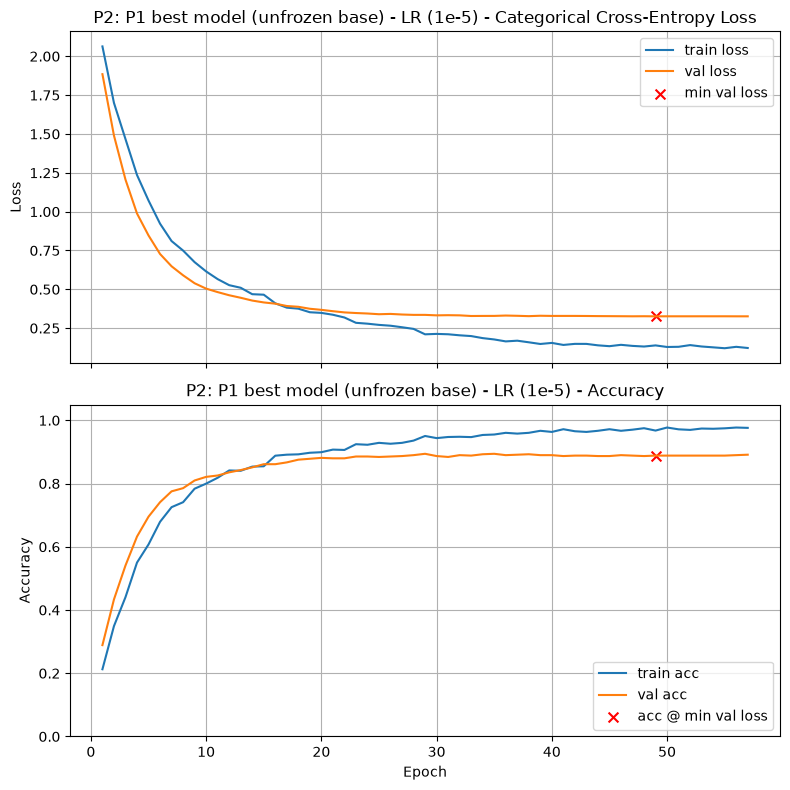

Final Training Loss:            0.1224
Final Training Accuracy:        0.9761
Final Validation Loss:          0.3262
Final Validation Accuracy:      0.8913
Minimum Validation Loss:        0.3260 (Epoch 49)
Validation Accuracy @ Min Loss: 0.8884

Test Loss: 0.3100
Test Accuracy: 0.8930

Validation-Test Gap (accuracy): 0.004636

Execution Time: 00:23:18


In [32]:
model_unfrozen_baseline2 = make_base_model_pooled(trainable=True)

p1_best2 = models.Sequential([
    model_unfrozen_baseline2,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best2, lr_schedule=1e-5, patience=8, callbacks=[reduce_lr], title="P2: P1 best model (unfrozen base) - LR (1e-5)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - LR (3e-5)

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


88/88 ━━━━━━━━━━━━━━━━━━━━ 93s 727ms/step - accuracy: 0.3449 - loss: 1.7330 - val_accuracy: 0.5994 - val_loss: 1.1079 - learning_rate: 3.0000e-05
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 286ms/step - accuracy: 0.6359 - loss: 1.0203 - val_accuracy: 0.7654 - val_loss: 0.6842 - learning_rate: 3.0000e-05
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 26s 294ms/step - accuracy: 0.7588 - loss: 0.7195 - val_accuracy: 0.7825 - val_loss: 0.5696 - learning_rate: 3.0000e-05
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 24s 273ms/step - accuracy: 0.8351 - loss: 0.5388 - val_accuracy: 0.8112 - val_loss: 0.5390 - learning_rate: 3.0000e-05
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 24s 275ms/step - accuracy: 0.8643 - loss: 0.4490 - val_accuracy: 0.8255 - val_loss: 0.4952 - learning_rate: 3.0000e-05
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 24s 273ms/step - accuracy: 0.8874 - loss: 0.3761 - val_accuracy: 0.8355 - val_loss: 0.4738 - learning_rate: 3.0000e-05
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 24s 268ms/step - accuracy

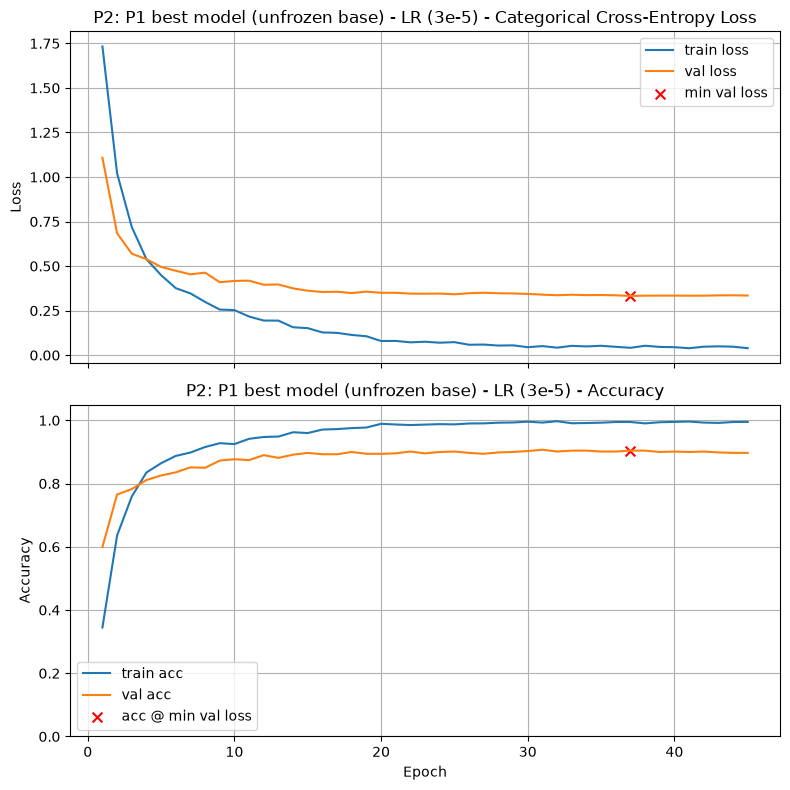

Final Training Loss:            0.0391
Final Training Accuracy:        0.9950
Final Validation Loss:          0.3347
Final Validation Accuracy:      0.8970
Minimum Validation Loss:        0.3322 (Epoch 37)
Validation Accuracy @ Min Loss: 0.9041

Test Loss: 0.2933
Test Accuracy: 0.9051

Validation-Test Gap (accuracy): 0.000931

Execution Time: 00:19:13


In [33]:
model_unfrozen_baseline3 = make_base_model_pooled(trainable=True)

p1_best3 = models.Sequential([
    model_unfrozen_baseline3,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best3, lr_schedule=3e-5, patience=8, callbacks=[reduce_lr], title="P2: P1 best model (unfrozen base) - LR (3e-5)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - LR (3e-5) no ReduceLROnPlateau

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


88/88 ━━━━━━━━━━━━━━━━━━━━ 109s 890ms/step - accuracy: 0.3620 - loss: 1.6504 - val_accuracy: 0.5951 - val_loss: 1.1445
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 28s 312ms/step - accuracy: 0.6562 - loss: 1.0045 - val_accuracy: 0.7811 - val_loss: 0.6747
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 279ms/step - accuracy: 0.7805 - loss: 0.6958 - val_accuracy: 0.7897 - val_loss: 0.5680
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 26s 291ms/step - accuracy: 0.8247 - loss: 0.5585 - val_accuracy: 0.8097 - val_loss: 0.5464
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 26s 295ms/step - accuracy: 0.8614 - loss: 0.4661 - val_accuracy: 0.8212 - val_loss: 0.5280
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 26s 300ms/step - accuracy: 0.8860 - loss: 0.3857 - val_accuracy: 0.8355 - val_loss: 0.4807
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 283ms/step - accuracy: 0.9088 - loss: 0.3262 - val_accuracy: 0.8498 - val_loss: 0.4725
Epoch 8/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 283ms/step - accuracy: 0.9131 - loss: 0.3033 - val_accurac

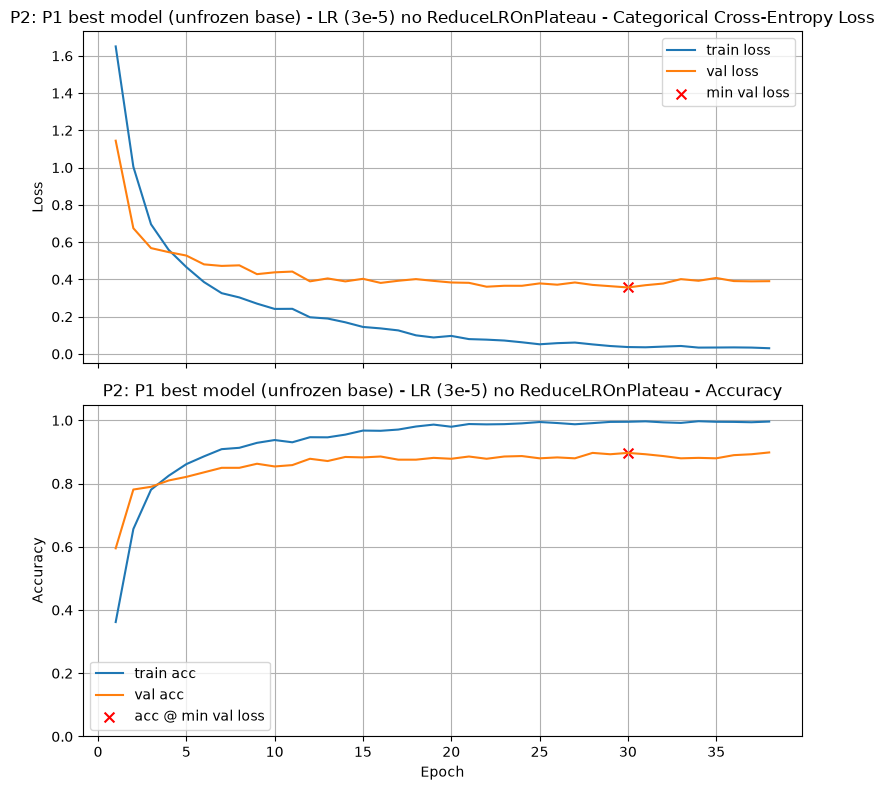

Final Training Loss:            0.0307
Final Training Accuracy:        0.9961
Final Validation Loss:          0.3905
Final Validation Accuracy:      0.8984
Minimum Validation Loss:        0.3568 (Epoch 30)
Validation Accuracy @ Min Loss: 0.8970

Test Loss: 0.3100
Test Accuracy: 0.9131

Validation-Test Gap (accuracy): 0.016106

Execution Time: 00:17:01


In [34]:
model_unfrozen_baseline4 = make_base_model_pooled(trainable=True)

p1_best4 = models.Sequential([
    model_unfrozen_baseline4,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best4, lr_schedule=3e-5, patience=8, title="P2: P1 best model (unfrozen base) - LR (3e-5) no ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - LR (3e-5), L2 reg on Dense 512

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


88/88 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.3392 - loss: 1.8693 - val_accuracy: 0.5851 - val_loss: 1.2305 - learning_rate: 3.0000e-05
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 30s 332ms/step - accuracy: 0.6099 - loss: 1.1501 - val_accuracy: 0.7568 - val_loss: 0.7870 - learning_rate: 3.0000e-05
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 28s 322ms/step - accuracy: 0.7535 - loss: 0.8209 - val_accuracy: 0.8097 - val_loss: 0.6119 - learning_rate: 3.0000e-05
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 287ms/step - accuracy: 0.8233 - loss: 0.6385 - val_accuracy: 0.8283 - val_loss: 0.5425 - learning_rate: 3.0000e-05
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 278ms/step - accuracy: 0.8593 - loss: 0.5452 - val_accuracy: 0.8484 - val_loss: 0.5076 - learning_rate: 3.0000e-05
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 279ms/step - accuracy: 0.8785 - loss: 0.4864 - val_accuracy: 0.8584 - val_loss: 0.4808 - learning_rate: 3.0000e-05
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 280ms/step - accuracy: 

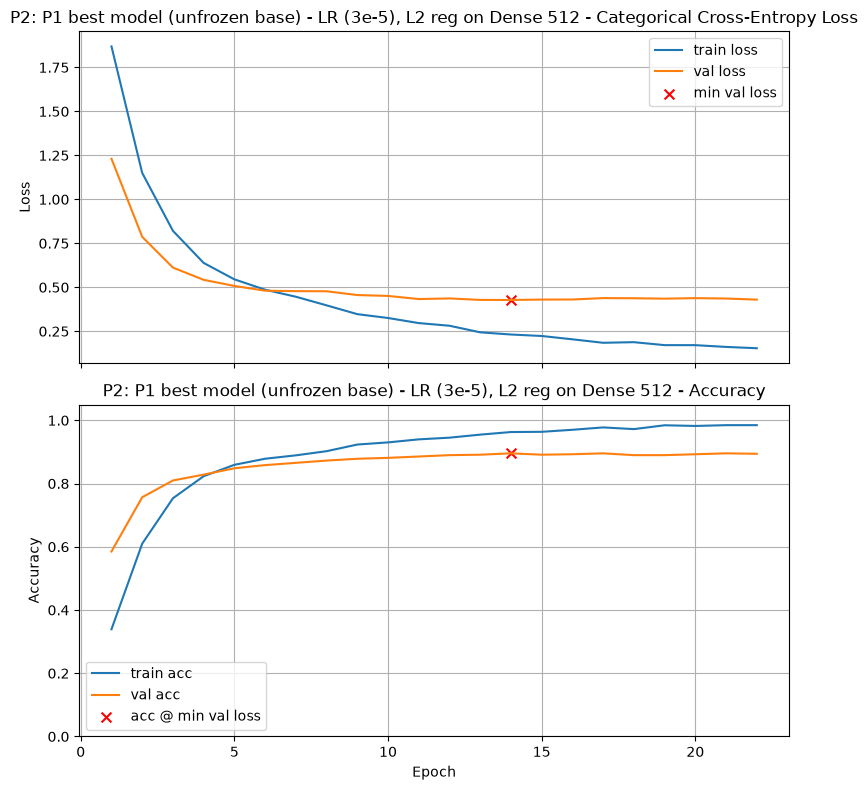

Final Training Loss:            0.1536
Final Training Accuracy:        0.9847
Final Validation Loss:          0.4300
Final Validation Accuracy:      0.8941
Minimum Validation Loss:        0.4279 (Epoch 14)
Validation Accuracy @ Min Loss: 0.8956

Test Loss: 0.3907
Test Accuracy: 0.9011

Validation-Test Gap (accuracy): 0.005504

Execution Time: 00:10:51


In [35]:
model_unfrozen_baseline5 = make_base_model_pooled(trainable=True)

p1_best5 = models.Sequential([
    model_unfrozen_baseline5,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best5, lr_schedule=3e-5, patience=8, callbacks=[reduce_lr], title="P2: P1 best model (unfrozen base) - LR (3e-5), L2 reg on Dense 512")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg on Dense 512

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


88/88 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.3441 - loss: 1.7448 - val_accuracy: 0.6195 - val_loss: 1.1242
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 28s 309ms/step - accuracy: 0.6348 - loss: 1.0944 - val_accuracy: 0.7940 - val_loss: 0.6960
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 281ms/step - accuracy: 0.7613 - loss: 0.7928 - val_accuracy: 0.8112 - val_loss: 0.5859
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 289ms/step - accuracy: 0.8404 - loss: 0.6062 - val_accuracy: 0.8283 - val_loss: 0.5568
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 281ms/step - accuracy: 0.8707 - loss: 0.5079 - val_accuracy: 0.8326 - val_loss: 0.5592
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 24s 271ms/step - accuracy: 0.8888 - loss: 0.4464 - val_accuracy: 0.8398 - val_loss: 0.5577
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 24s 272ms/step - accuracy: 0.9006 - loss: 0.4226 - val_accuracy: 0.8469 - val_loss: 0.5507
Epoch 8/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 280ms/step - accuracy: 0.9188 - loss: 0.3628 - val_accuracy: 

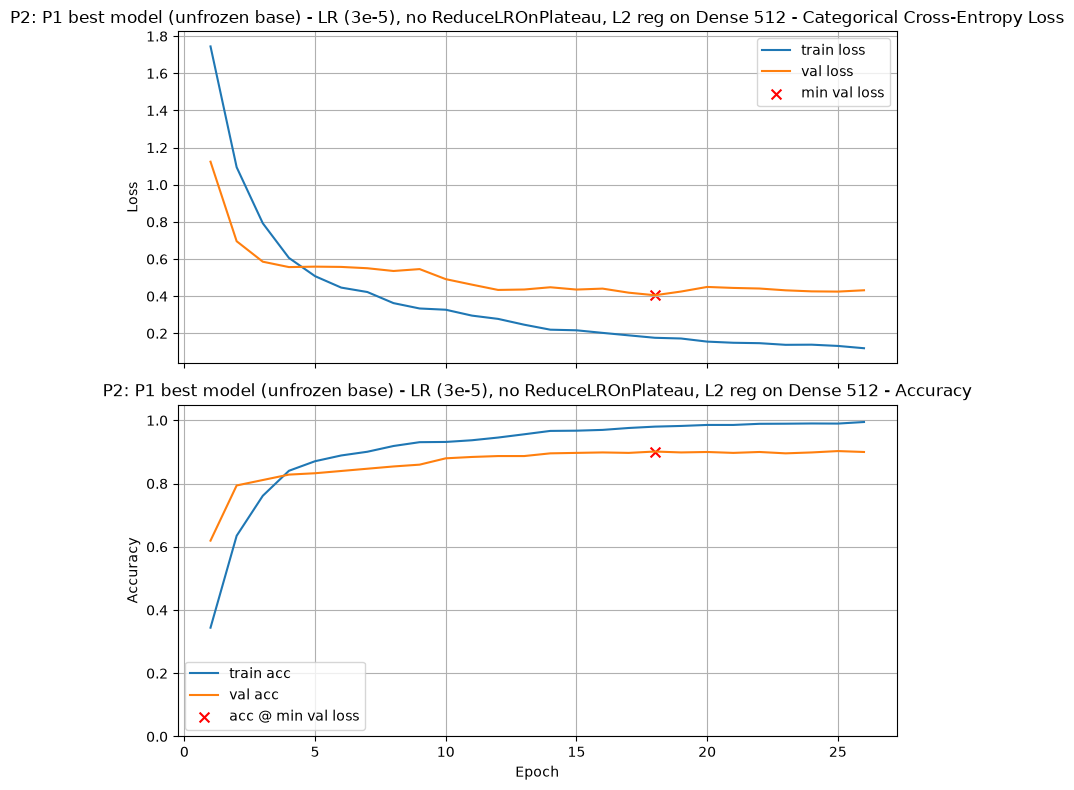

Final Training Loss:            0.1200
Final Training Accuracy:        0.9947
Final Validation Loss:          0.4320
Final Validation Accuracy:      0.8999
Minimum Validation Loss:        0.4052 (Epoch 18)
Validation Accuracy @ Min Loss: 0.9013

Test Loss: 0.3479
Test Accuracy: 0.9064

Validation-Test Gap (accuracy): 0.005130

Execution Time: 00:12:30


In [36]:
model_unfrozen_baseline6 = make_base_model_pooled(trainable=True)

p1_best6 = models.Sequential([
    model_unfrozen_baseline6,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best6, lr_schedule=3e-5, patience=8, title="P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg on Dense 512")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - LR (3e-5), L2 reg

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.3545 - loss: 1.7740 - val_accuracy: 0.6567 - val_loss: 1.0854 - learning_rate: 3.0000e-05
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 27s 305ms/step - accuracy: 0.6316 - loss: 1.1107 - val_accuracy: 0.8069 - val_loss: 0.6911 - learning_rate: 3.0000e-05
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 287ms/step - accuracy: 0.7592 - loss: 0.8170 - val_accuracy: 0.8340 - val_loss: 0.5711 - learning_rate: 3.0000e-05
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 279ms/step - accuracy: 0.8226 - loss: 0.6639 - val_accuracy: 0.8598 - val_loss: 0.5281 - learning_rate: 3.0000e-05
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 279ms/step - accuracy: 0.8693 - loss: 0.5405 - val_accuracy: 0.8655 - val_loss: 0.5043 - learning_rate: 3.0000e-05
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 289ms/step - accuracy: 0.8842 - loss: 0.4827 - val_accuracy: 0.8712 - val_loss: 0.4790 - learning_rate: 3.0000e-0

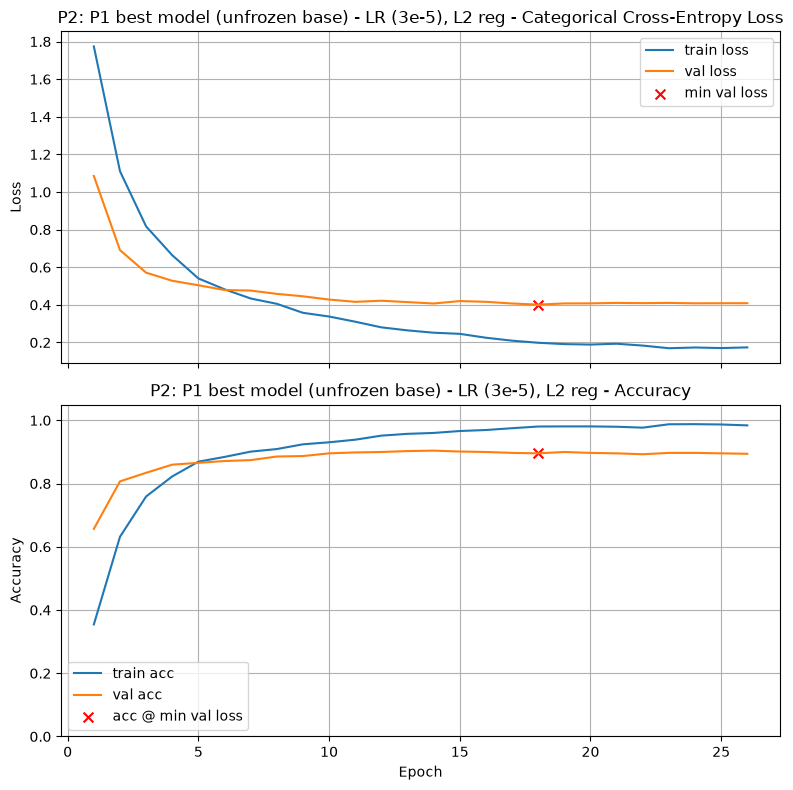

Final Training Loss:            0.1740
Final Training Accuracy:        0.9840
Final Validation Loss:          0.4089
Final Validation Accuracy:      0.8941
Minimum Validation Loss:        0.4013 (Epoch 18)
Validation Accuracy @ Min Loss: 0.8956

Test Loss: 0.3667
Test Accuracy: 0.9104

Validation-Test Gap (accuracy): 0.014863

Execution Time: 00:13:29


In [37]:
model_unfrozen_baseline7 = make_base_model_pooled(trainable=True)

p1_best7 = models.Sequential([
    model_unfrozen_baseline7,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best7, lr_schedule=3e-5, patience=8, callbacks=[reduce_lr], title="P2: P1 best model (unfrozen base) - LR (3e-5), L2 reg")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.3263 - loss: 1.8242 - val_accuracy: 0.5722 - val_loss: 1.1956
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 29s 317ms/step - accuracy: 0.6356 - loss: 1.0987 - val_accuracy: 0.7697 - val_loss: 0.7416
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 26s 293ms/step - accuracy: 0.7713 - loss: 0.8013 - val_accuracy: 0.7997 - val_loss: 0.6419
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 26s 293ms/step - accuracy: 0.8190 - loss: 0.6525 - val_accuracy: 0.8083 - val_loss: 0.6261
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 283ms/step - accuracy: 0.8593 - loss: 0.5525 - val_accuracy: 0.8283 - val_loss: 0.5714
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 286ms/step - accuracy: 0.8849 - loss: 0.4894 - val_accuracy: 0.8383 - val_loss: 0.5495
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 282ms/step - accuracy: 0.8974 - loss: 0.4242 - val_accuracy: 0.8569 - val_loss: 0.5368
Epoch 8/500
88

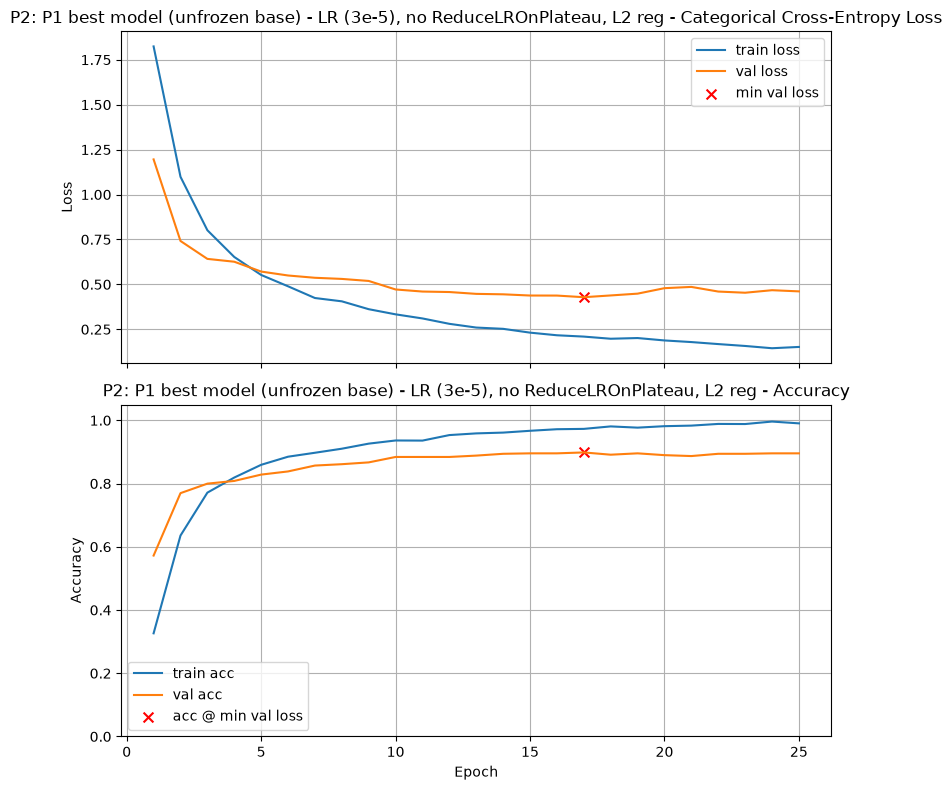

Final Training Loss:            0.1520
Final Training Accuracy:        0.9904
Final Validation Loss:          0.4611
Final Validation Accuracy:      0.8956
Minimum Validation Loss:        0.4287 (Epoch 17)
Validation Accuracy @ Min Loss: 0.8984

Test Loss: 0.3635
Test Accuracy: 0.9078

Validation-Test Gap (accuracy): 0.009328

Execution Time: 00:13:41


In [38]:
model_unfrozen_baseline8 = make_base_model_pooled(trainable=True)

p1_best8 = models.Sequential([
    model_unfrozen_baseline8,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best8, lr_schedule=3e-5, patience=8, title="P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg, patience 3

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 294s 3s/step - accuracy: 0.3235 - loss: 1.8313 - val_accuracy: 0.5908 - val_loss: 1.2029
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 31s 346ms/step - accuracy: 0.6291 - loss: 1.1201 - val_accuracy: 0.8040 - val_loss: 0.7522
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 26s 293ms/step - accuracy: 0.7663 - loss: 0.8089 - val_accuracy: 0.8355 - val_loss: 0.5787
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 26s 294ms/step - accuracy: 0.8261 - loss: 0.6643 - val_accuracy: 0.8641 - val_loss: 0.5144
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 24s 272ms/step - accuracy: 0.8497 - loss: 0.5757 - val_accuracy: 0.8670 - val_loss: 0.4854
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 26s 299ms/step - accuracy: 0.8785 - loss: 0.4987 - val_accuracy: 0.8655 - val_loss: 0.4786
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 279ms/step - accuracy: 0.8999 - loss: 0.4350 - val_accuracy: 0.8655 - val_loss: 0.4706
Ep

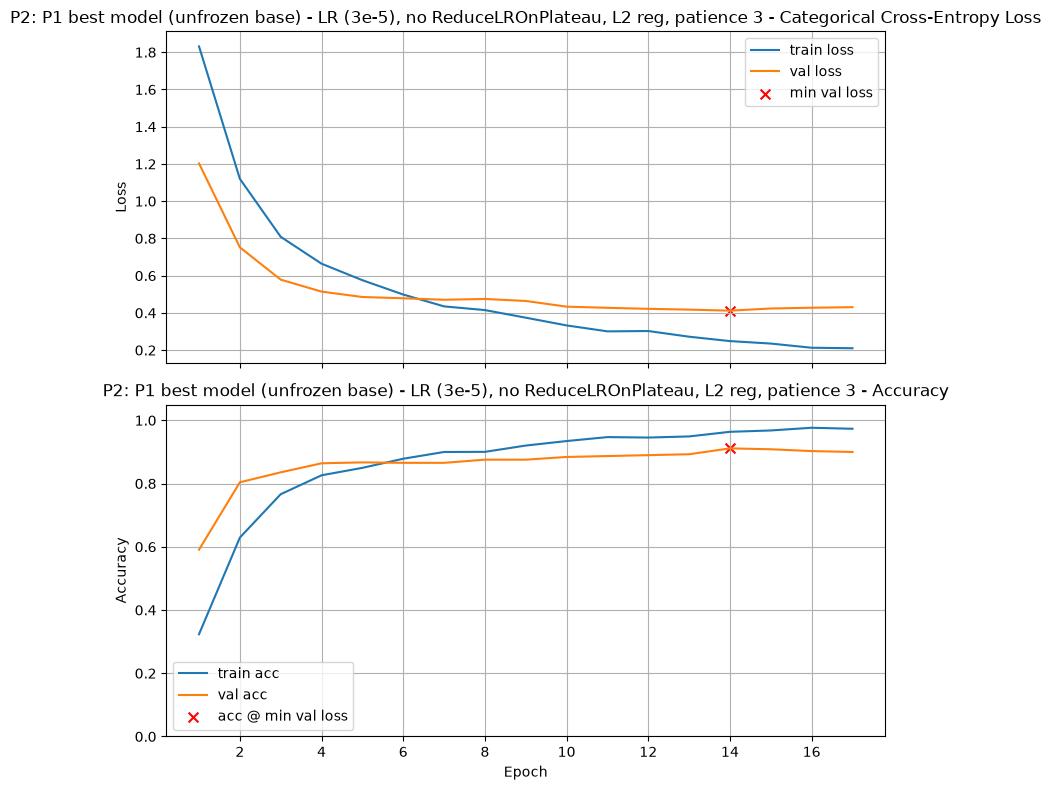

Final Training Loss:            0.2103
Final Training Accuracy:        0.9733
Final Validation Loss:          0.4308
Final Validation Accuracy:      0.8999
Minimum Validation Loss:        0.4121 (Epoch 14)
Validation Accuracy @ Min Loss: 0.9113

Test Loss: 0.4132
Test Accuracy: 0.8944

Validation-Test Gap (accuracy): 0.016917

Execution Time: 00:11:39


In [48]:
model_unfrozen_baseline9 = make_base_model_pooled(trainable=True)

p1_best9 = models.Sequential([
    model_unfrozen_baseline9,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best9, lr_schedule=3e-5, patience=3, title="P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg, patience 3")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - LR (3e-4), no ReduceLROnPlateau, L2 reg, patience 3

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 294s 3s/step - accuracy: 0.7456 - loss: 0.8303 - val_accuracy: 0.7253 - val_loss: 1.1642
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 30s 333ms/step - accuracy: 0.9102 - loss: 0.3920 - val_accuracy: 0.8040 - val_loss: 0.7320
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 26s 297ms/step - accuracy: 0.9458 - loss: 0.2782 - val_accuracy: 0.8355 - val_loss: 0.8316
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 26s 293ms/step - accuracy: 0.9551 - loss: 0.2533 - val_accuracy: 0.8398 - val_loss: 0.7618
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 27s 310ms/step - accuracy: 0.9544 - loss: 0.2403 - val_accuracy: 0.8269 - val_loss: 0.7160
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 285ms/step - accuracy: 0.9658 - loss: 0.2097 - val_accuracy: 0.7396 - val_loss: 1.2234
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 26s 298ms/step - accuracy: 0.9701 - loss: 0.1959 - val_accuracy: 0.7468 - val_loss: 1.3151
Ep

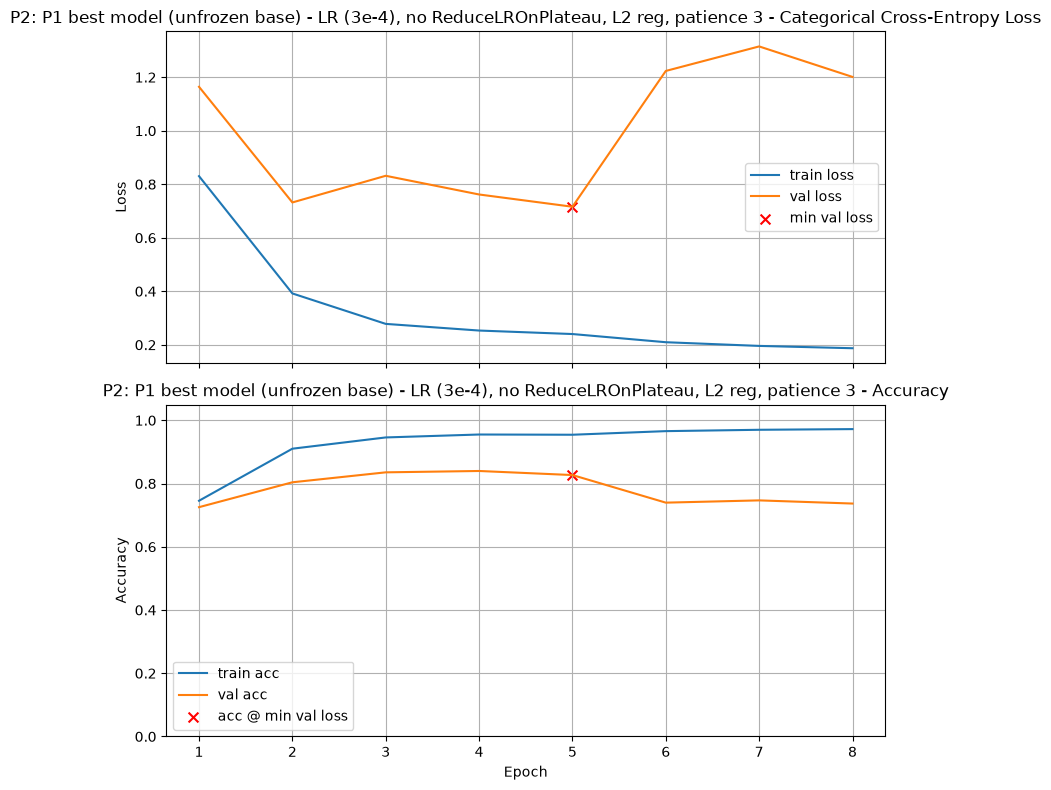

Final Training Loss:            0.1872
Final Training Accuracy:        0.9722
Final Validation Loss:          1.2011
Final Validation Accuracy:      0.7368
Minimum Validation Loss:        0.7160 (Epoch 5)
Validation Accuracy @ Min Loss: 0.8269

Test Loss: 0.6516
Test Accuracy: 0.8222

Validation-Test Gap (accuracy): 0.004703

Execution Time: 00:08:05


In [49]:
model_unfrozen_baseline10 = make_base_model_pooled(trainable=True)

p1_best10 = models.Sequential([
    model_unfrozen_baseline10,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best10, lr_schedule=3e-4, patience=3, title="P2: P1 best model (unfrozen base) - LR (3e-4), no ReduceLROnPlateau, L2 reg, patience 3")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - LR (3e-4), no ReduceLROnPlateau, patience 3

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 383s 4s/step - accuracy: 0.7456 - loss: 0.7305 - val_accuracy: 0.7725 - val_loss: 1.0656
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 31s 347ms/step - accuracy: 0.8960 - loss: 0.3182 - val_accuracy: 0.8183 - val_loss: 0.6203
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 26s 293ms/step - accuracy: 0.9384 - loss: 0.2029 - val_accuracy: 0.7582 - val_loss: 0.9441
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 24s 277ms/step - accuracy: 0.9551 - loss: 0.1491 - val_accuracy: 0.7697 - val_loss: 0.9324
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 284ms/step - accuracy: 0.9654 - loss: 0.1180 - val_accuracy: 0.7439 - val_loss: 1.4070
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


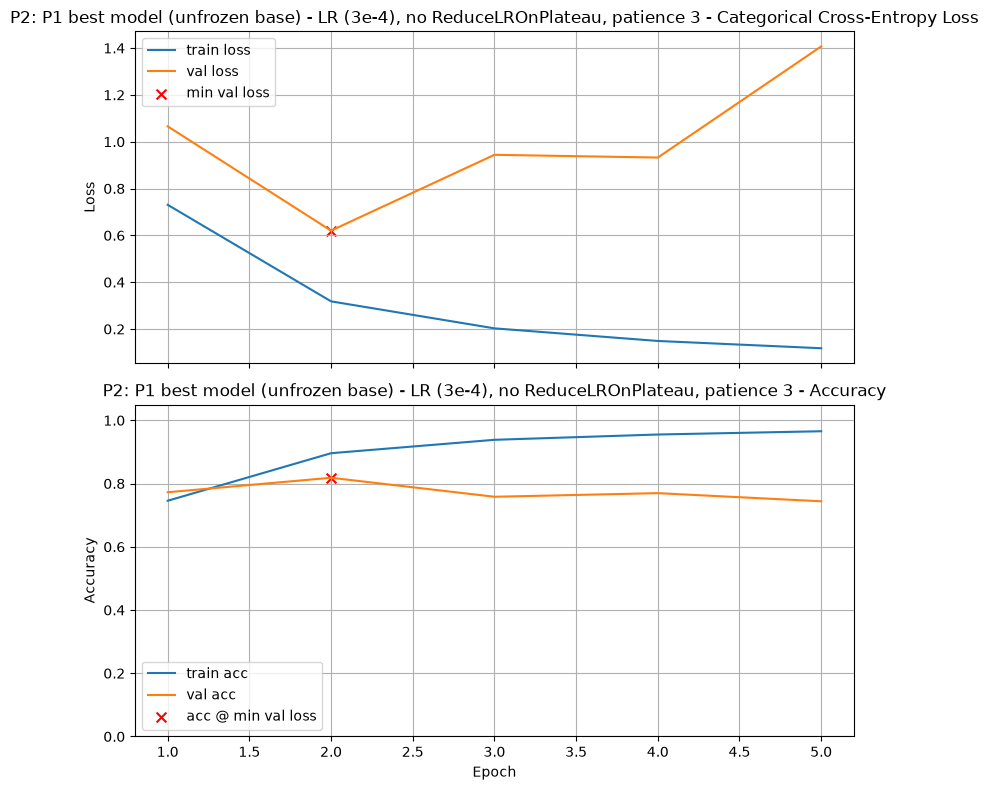

Final Training Loss:            0.1180
Final Training Accuracy:        0.9654
Final Validation Loss:          1.4070
Final Validation Accuracy:      0.7439
Minimum Validation Loss:        0.6203 (Epoch 2)
Validation Accuracy @ Min Loss: 0.8183

Test Loss: 0.6500
Test Accuracy: 0.8155

Validation-Test Gap (accuracy): 0.002804

Execution Time: 00:08:12


In [50]:
model_unfrozen_baseline11 = make_base_model_pooled(trainable=True)

p1_best11 = models.Sequential([
    model_unfrozen_baseline11,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best11, lr_schedule=3e-4, patience=3, title="P2: P1 best model (unfrozen base) - LR (3e-4), no ReduceLROnPlateau, patience 3")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - No Dropout

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 399s 4s/step - accuracy: 0.6986 - loss: 0.8273 - val_accuracy: 0.7725 - val_loss: 0.6160 - learning_rate: 1.0000e-04
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 32s 355ms/step - accuracy: 0.9191 - loss: 0.2712 - val_accuracy: 0.8069 - val_loss: 0.5608 - learning_rate: 1.0000e-04
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 28s 309ms/step - accuracy: 0.9508 - loss: 0.1778 - val_accuracy: 0.8069 - val_loss: 0.5971 - learning_rate: 1.0000e-04
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 30s 335ms/step - accuracy: 0.9719 - loss: 0.1236 - val_accuracy: 0.8226 - val_loss: 0.5390 - learning_rate: 1.0000e-04
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 29s 324ms/step - accuracy: 0.9861 - loss: 0.0786 - val_accuracy: 0.8140 - val_loss: 0.6267 - learning_rate: 1.0000e-04
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 27s 306ms/step - accuracy: 0.9918 - loss: 0.0510 - val_accuracy: 0.8784 - val_loss: 0.4350 - learning_rate: 1.0000e-04
Epoch

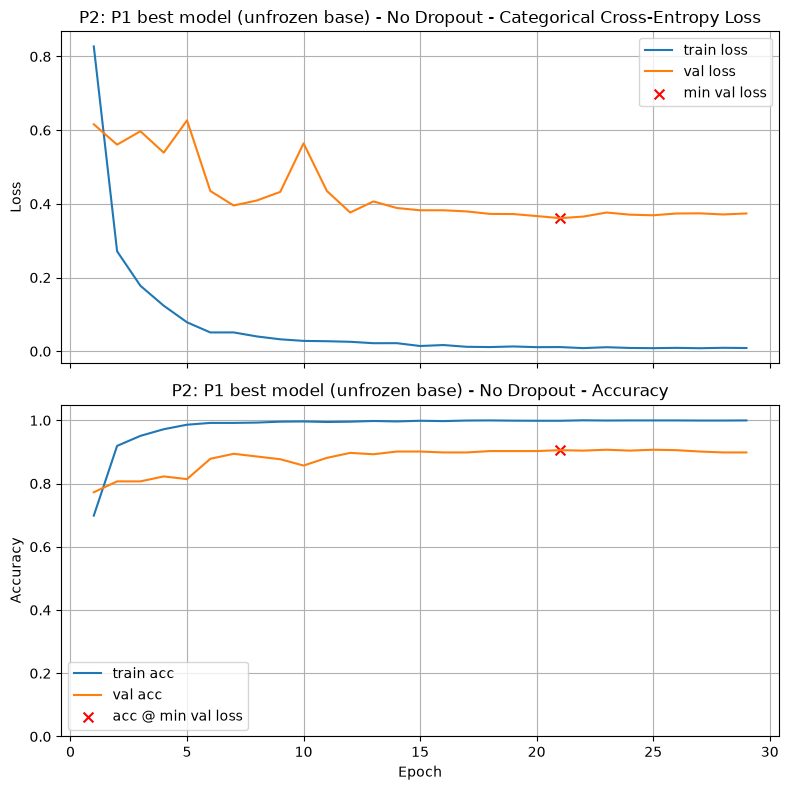

Final Training Loss:            0.0087
Final Training Accuracy:        0.9996
Final Validation Loss:          0.3739
Final Validation Accuracy:      0.8984
Minimum Validation Loss:        0.3612 (Epoch 21)
Validation Accuracy @ Min Loss: 0.9056

Test Loss: 0.3106
Test Accuracy: 0.9131

Validation-Test Gap (accuracy): 0.007522

Execution Time: 00:18:48


In [51]:
model_unfrozen_baseline12 = make_base_model_pooled(trainable=True)

p1_best12 = models.Sequential([
    model_unfrozen_baseline12,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    # Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    # Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best12, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title="P2: P1 best model (unfrozen base) - No Dropout")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_1430/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - L2 reg, No Dropout

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 470s 4s/step - accuracy: 0.7342 - loss: 0.8769 - val_accuracy: 0.8097 - val_loss: 0.5802 - learning_rate: 1.0000e-04
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 33s 366ms/step - accuracy: 0.9202 - loss: 0.3887 - val_accuracy: 0.8469 - val_loss: 0.5423 - learning_rate: 1.0000e-04
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 26s 292ms/step - accuracy: 0.9555 - loss: 0.2669 - val_accuracy: 0.8627 - val_loss: 0.5006 - learning_rate: 1.0000e-04
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 27s 306ms/step - accuracy: 0.9754 - loss: 0.2045 - val_accuracy: 0.8569 - val_loss: 0.5693 - learning_rate: 1.0000e-04
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 27s 306ms/step - accuracy: 0.9868 - loss: 0.1720 - val_accuracy: 0.8670 - val_loss: 0.5664 - learning_rate: 1.0000e-04
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9882 - loss: 0.1607
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.9999998736893

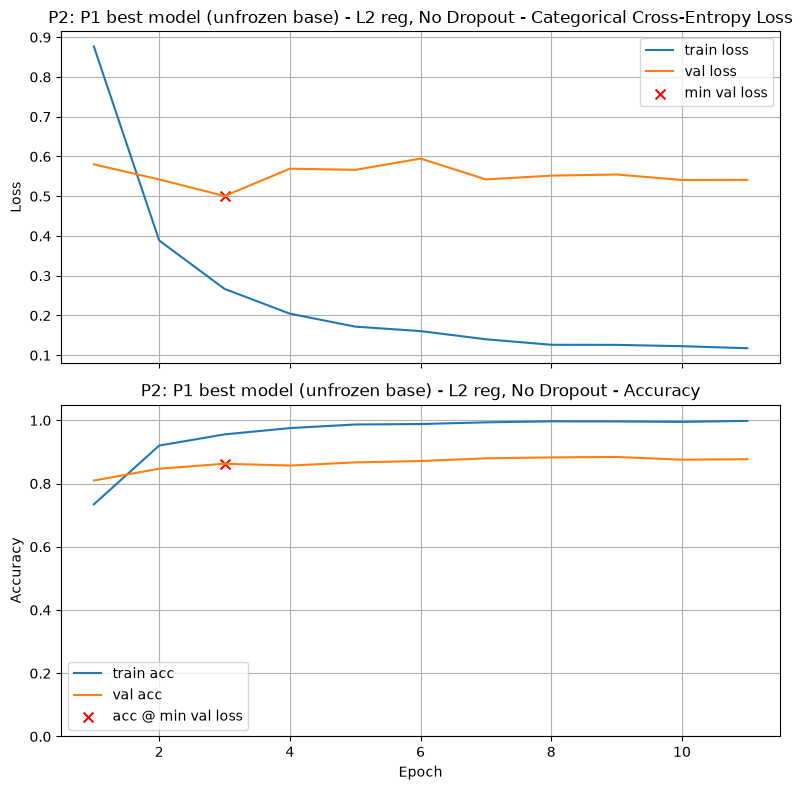

Final Training Loss:            0.1176
Final Training Accuracy:        0.9982
Final Validation Loss:          0.5412
Final Validation Accuracy:      0.8770
Minimum Validation Loss:        0.5006 (Epoch 3)
Validation Accuracy @ Min Loss: 0.8627

Test Loss: 0.4813
Test Accuracy: 0.8743

Validation-Test Gap (accuracy): 0.011671

Execution Time: 00:12:19


In [52]:
model_unfrozen_baseline13 = make_base_model_pooled(trainable=True)

p1_best13 = models.Sequential([
    model_unfrozen_baseline13,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    # Dropout(0.4),
    Dense(128, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    # Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best13, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title="P2: P1 best model (unfrozen base) - L2 reg, No Dropout")

In [53]:
print_results()

P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg, patience 3	0.9113	14
P2: P1 best model (unfrozen base) - No Dropout	0.9056	21
P2: P1 best model (unfrozen base) - LR (3e-5)	0.9041	37
P1: Three Tier Funnel (no reg), LR (5e-4), Patience (8)	0.9027	4
P1: Two Tier Funnel (no reg), LR (1e-4), Patience (6)	0.9027	13
P1: Two Tier Funnel (no reg), LR (5e-4), Patience (6), ReduceLROnPlateau	0.9013	2
P2: P1 best model (unfrozen base)       	0.9013	9
P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg on Dense 512	0.9013	18
P3: Base Model with Last 20 Layers Unfrozen + Best P1 head	0.9013	25
P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg	0.8984	17
P4: Base Model with Conv_1 Unfrozen + Best P1 head	0.8984	2
P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8)	0.8970	3
P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8)	0.8970	13
P2: P1 best model (unfrozen base) - LR (3e-5) no ReduceLROnPlateau	0.8970	30
P1: Tw

### Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which fully unfrozen configuration worked best for you, and what does that suggest about the role of head design and training hyperparameters when the MobileNetV2 backbone is trainable?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Explain your reasoning in choosing your three experimental designs.
* Identify the experiment that performed best.
* Briefly compare it with the other experiments, referring to both architectural choices (e.g., dense layers, dropout) and training hyperparameters (e.g., learning rate, `ReduceLROnPlateau`).
* Explain which differences you think were most important, based on the training and validation behavior you observed.
* Conclude with what your experiments suggest about training a model when the pretrained backbone is fully unfrozen.



**Your paragraph here (5pts):**

> The best model included using P1's best performing head and then adapting the learning rate (3e-5), disabling ReduceLROnPlateau, using L2 regularization for each of the head's Dense layers, and reducing the early stopping patience to 3. The experiment focused mainly on those three hyperparameters to see how they would interact with each other rather than testing new head architecture. First, I tested them individually then began applying more than one at a time. Based on the experiment, simply setting the learning rate (3e-5) was enough to perform nearly as well as the top P2 model (roughly a difference of 0.006 validation accuracy at minimum validation loss) and the combination of learning rate, L2 regularization, and/or disabling ReduceLROnPlateau resulted in minor improvements. Ultimately, this suggests that a fully unfrozen pretrained model requires lower learning rates but the addition of other hyperparameters (ReduceLROnPlateau, L2 regularization, etc.) can be applied to boost performance but risks overfitting/longer compute.

**Validation accuracy here (15 pts):**

In [39]:
# Set a2 to the validation accuracy found by your best model for this problem. 

a2 = 0.0             # Replace 0.0 with your answer

In [40]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1a in this problem       

print(f'a2 = {a2:.4f}') 

a2 = 0.0000


## Problem Three — Unfreezing Layers

**Goal.** Keep most of the pretrained MobileNetV2 backbone frozen and **unfreeze only the last \(N\) layers** for fine-tuning.

(In Problem 4, you will instead explore unfreezing the top **\(K\) MobileNetV2 blocks**.)

**Setup.** The backbone is MobileNetV2 with `include_top=False` and `pooling="avg"`, so it outputs a 1280-D feature vector. Do **not** add another pooling layer in the head.

After creating the backbone, unfreeze the last \(N\) layers using the following approach:

```python
N = 20

base_model = make_base_model_pooled()
base_model.trainable = True

for layer in base_model.layers[:-N]:
    layer.trainable = False
```

### To Do

1. **Design at least three experiments** in which only the last \(N\) backbone layers are unfrozen. Vary one or more of the following:

   * \(N \in \{20, 40, 80\}\)
   * **Head architecture** (select one from Problem 1)
   * **Learning rate**
   * **EarlyStopping** parameters
   * **Regularization:** Dropout and/or L2
   * **ReduceLROnPlateau:** on vs. off

2. **Run and compare** the three experiments using a reduced value of `DATA_FRACTION`, focusing on:

   * how performance changes as more layers are unfrozen,
   * training stability and convergence,
   * and validation performance trends.

   Use these runs to **understand the effect of partial unfreezing**, not to identify a single globally optimal configuration.

3. **Select one configuration** (choice of \(N\) and training strategy), set `DATA_FRACTION = 1.0`, and rerun the notebook on the full dataset. Use this run when answering the graded questions.

### Notes

* As more layers are unfrozen, the model typically becomes **more sensitive to the learning rate**.
* Learning rates around \(1\times10^{-5}\) to \(3\times10^{-5}\) are reasonable starting points for partial fine-tuning.
* Small shifts in relative performance between reduced-data experiments and the full dataset are expected.
* Construct a **new backbone/model for each experiment** so that experiments do not inherit weights from previous runs.



/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_4801/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P3: Base Model with Last 20 Layers Unfrozen + Best P1 head

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.6238 - loss: 1.0091 - val_accuracy: 0.7053 - val_loss: 0.8502 - learning_rate: 1.0000e-04
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.8693 - loss: 0.4237 - val_accuracy: 0.7883 - val_loss: 0.6752 - learning_rate: 1.0000e-04
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9059 - loss: 0.3278 - val_accuracy: 0.8097 - val_loss: 0.6615 - learning_rate: 1.0000e-04
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9195 - loss: 0.2582 - val_accuracy: 0.8498 - val_loss: 0.5646 - learning_rate: 1.0000e-04
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9448 - loss: 0.1998 - val_accuracy: 0.8383 - val_loss: 0.5918 - learning_rate: 1.0000e-04
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9597 - loss: 0.1610 - val_accuracy: 0.8283 - val_loss: 0.6320 - learning_rate: 1.0000e-04
Epoch 7/500
87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9723 - lo

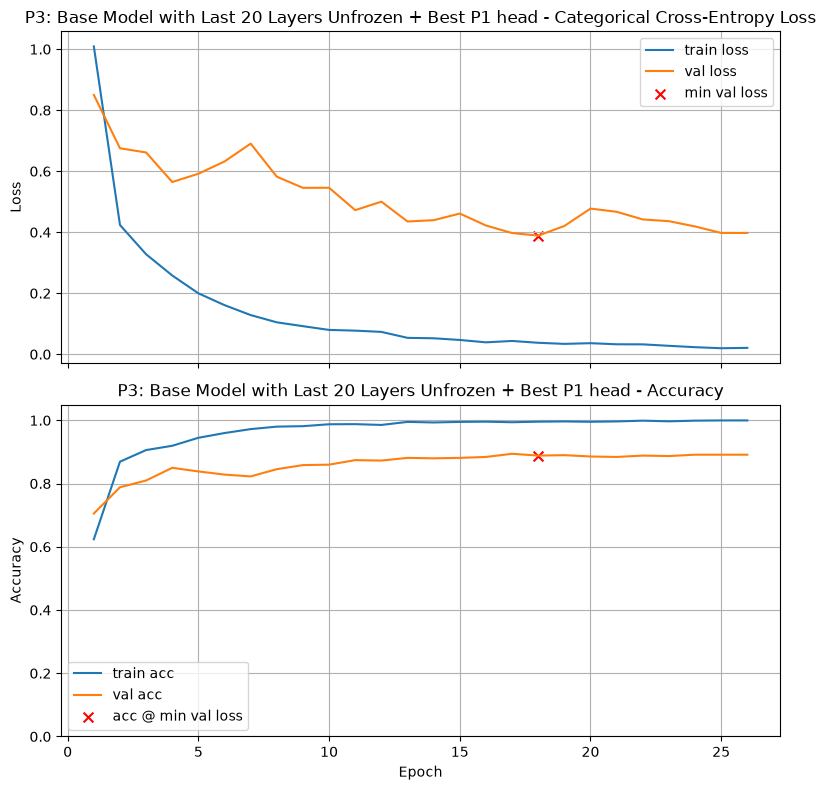

Final Training Loss:            0.0210
Final Training Accuracy:        0.9996
Final Validation Loss:          0.3977
Final Validation Accuracy:      0.8913
Minimum Validation Loss:        0.3888 (Epoch 18)
Validation Accuracy @ Min Loss: 0.8884

Test Loss: 0.3550
Test Accuracy: 0.8944

Validation-Test Gap (accuracy): 0.005973

Execution Time: 00:01:50


In [11]:
N = 20

base = make_base_model_pooled()
base.trainable = True

for layer in base.layers[:-N]:
    layer.trainable = False


p3_model = models.Sequential([
    base,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p3_model, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title=f"P3: Base Model with Last {N} Layers Unfrozen + Best P1 head")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_4801/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P3: Base Model with Last 40 Layers Unfrozen + Best P1 head

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 16s 124ms/step - accuracy: 0.6053 - loss: 1.0782 - val_accuracy: 0.7382 - val_loss: 0.6091 - learning_rate: 1.0000e-04
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.8782 - loss: 0.4096 - val_accuracy: 0.7811 - val_loss: 0.6163 - learning_rate: 1.0000e-04
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.9198 - loss: 0.2766 - val_accuracy: 0.7926 - val_loss: 0.6515 - learning_rate: 1.0000e-04
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9476 - loss: 0.1990
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.9476 - loss: 0.1990 - val_accuracy: 0.8355 - val_loss: 0.6355 - learning_rate: 1.0000e-04
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.9612 - loss: 0.1646 - val_accuracy: 0.8541 - val_loss: 0.5310 - learning_rate: 5.0000e-05
Epoch 6

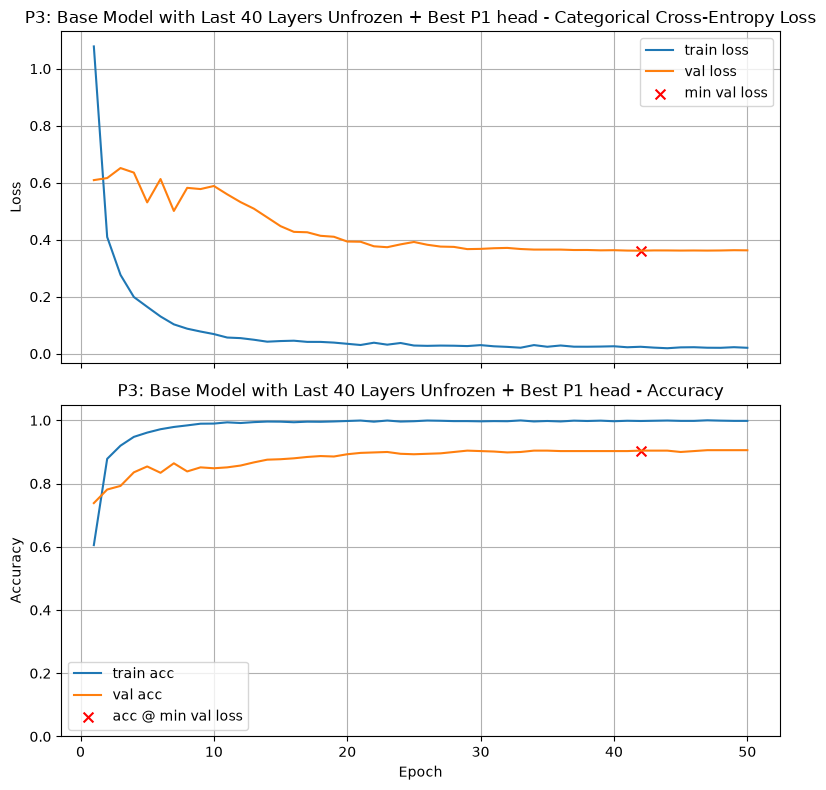

Final Training Loss:            0.0208
Final Training Accuracy:        0.9982
Final Validation Loss:          0.3627
Final Validation Accuracy:      0.9056
Minimum Validation Loss:        0.3615 (Epoch 42)
Validation Accuracy @ Min Loss: 0.9041

Test Loss: 0.3206
Test Accuracy: 0.9171

Validation-Test Gap (accuracy): 0.012964

Execution Time: 00:07:01


In [12]:
N = 40

base2 = make_base_model_pooled()
base2.trainable = True

for layer in base2.layers[:-N]:
    layer.trainable = False


p3_model2 = models.Sequential([
    base2,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p3_model2, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title=f"P3: Base Model with Last {N} Layers Unfrozen + Best P1 head")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_4801/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P3: Base Model with Last 80 Layers Unfrozen + Best P1 head

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 28s 203ms/step - accuracy: 0.5889 - loss: 1.0958 - val_accuracy: 0.8426 - val_loss: 0.4275 - learning_rate: 1.0000e-04
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 146ms/step - accuracy: 0.8575 - loss: 0.4471 - val_accuracy: 0.8283 - val_loss: 0.5023 - learning_rate: 1.0000e-04
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 145ms/step - accuracy: 0.8999 - loss: 0.3078 - val_accuracy: 0.8569 - val_loss: 0.4891 - learning_rate: 1.0000e-04
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9419 - loss: 0.2086
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 152ms/step - accuracy: 0.9419 - loss: 0.2086 - val_accuracy: 0.8584 - val_loss: 0.4945 - learning_rate: 1.0000e-04
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 157ms/step - accuracy: 0.9587 - loss: 0.1644 - val_accuracy: 0.8770 - val_loss: 0.4458 - learning_rate: 5.0000e-0

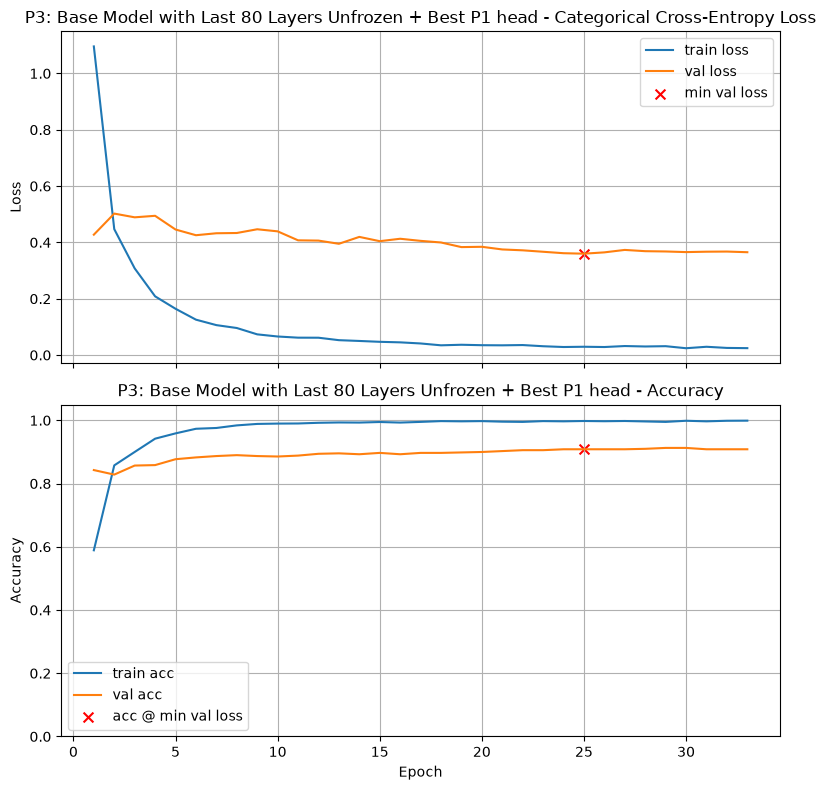

Final Training Loss:            0.0246
Final Training Accuracy:        0.9989
Final Validation Loss:          0.3652
Final Validation Accuracy:      0.9084
Minimum Validation Loss:        0.3600 (Epoch 25)
Validation Accuracy @ Min Loss: 0.9084

Test Loss: 0.2682
Test Accuracy: 0.9291

Validation-Test Gap (accuracy): 0.020704

Execution Time: 00:07:28


In [13]:
N = 80

base3 = make_base_model_pooled()
base3.trainable = True

for layer in base3.layers[:-N]:
    layer.trainable = False


p3_model3 = models.Sequential([
    base3,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p3_model3, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title=f"P3: Base Model with Last {N} Layers Unfrozen + Best P1 head")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_4801/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P3: Base Model with Last 20 Layers Unfrozen

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.7987 - loss: 0.5849 - val_accuracy: 0.7911 - val_loss: 0.6615 - learning_rate: 1.0000e-04
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9341 - loss: 0.2015 - val_accuracy: 0.8126 - val_loss: 0.5943 - learning_rate: 1.0000e-04
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9669 - loss: 0.1216 - val_accuracy: 0.8355 - val_loss: 0.5740 - learning_rate: 1.0000e-04
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9879 - loss: 0.0693 - val_accuracy: 0.8255 - val_loss: 0.6699 - learning_rate: 1.0000e-04
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9922 - loss: 0.0458 - val_accuracy: 0.8369 - val_loss: 0.6633 - learning_rate: 1.0000e-04
Epoch 6/500
87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9950 - loss: 0.0359
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
88/88 ━━━━━

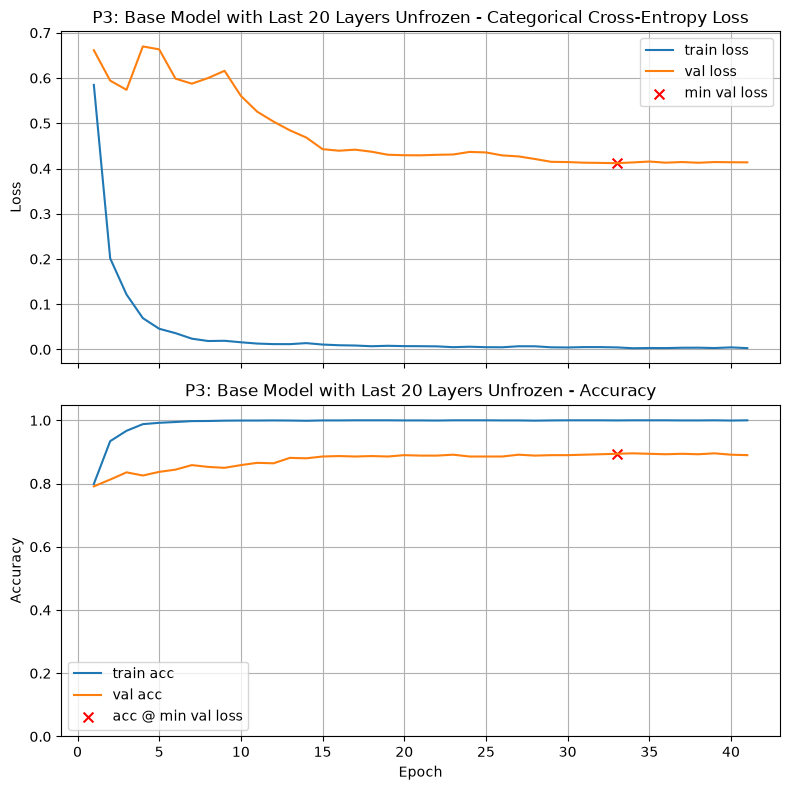

Final Training Loss:            0.0029
Final Training Accuracy:        1.0000
Final Validation Loss:          0.4136
Final Validation Accuracy:      0.8898
Minimum Validation Loss:        0.4118 (Epoch 33)
Validation Accuracy @ Min Loss: 0.8941

Test Loss: 0.3675
Test Accuracy: 0.9131

Validation-Test Gap (accuracy): 0.018967

Execution Time: 00:02:28


In [14]:
N = 20

base4 = make_base_model_pooled()
base4.trainable = True

for layer in base4.layers[:-N]:
    layer.trainable = False


p3_model4 = models.Sequential([
    base4,
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p3_model4, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title=f"P3: Base Model with Last {N} Layers Unfrozen")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_4801/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P3: Base Model with Last 40 Layers Unfrozen

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - accuracy: 0.7670 - loss: 0.6437 - val_accuracy: 0.7840 - val_loss: 0.6925 - learning_rate: 1.0000e-04
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.9451 - loss: 0.1724 - val_accuracy: 0.8083 - val_loss: 0.6162 - learning_rate: 1.0000e-04
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.9836 - loss: 0.0776 - val_accuracy: 0.8355 - val_loss: 0.6198 - learning_rate: 1.0000e-04
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.9900 - loss: 0.0478 - val_accuracy: 0.8526 - val_loss: 0.5298 - learning_rate: 1.0000e-04
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.9961 - loss: 0.0262 - val_accuracy: 0.8541 - val_loss: 0.5552 - learning_rate: 1.0000e-04
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.9968 - loss: 0.0200 - val_accuracy: 0.8612 - val_loss: 0.5684 - learning_rate: 1.0000e-04
Epoch 7/500
88/8

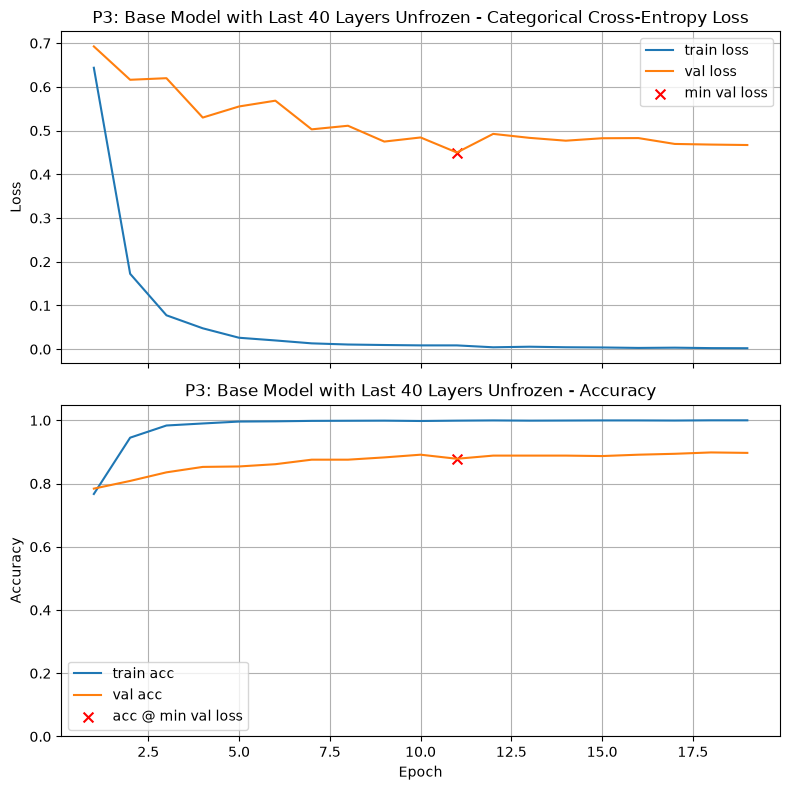

Final Training Loss:            0.0022
Final Training Accuracy:        1.0000
Final Validation Loss:          0.4670
Final Validation Accuracy:      0.8970
Minimum Validation Loss:        0.4498 (Epoch 11)
Validation Accuracy @ Min Loss: 0.8784

Test Loss: 0.4093
Test Accuracy: 0.9091

Validation-Test Gap (accuracy): 0.030693

Execution Time: 00:01:42


In [15]:
N = 40

base5 = make_base_model_pooled()
base5.trainable = True

for layer in base5.layers[:-N]:
    layer.trainable = False


p3_model5 = models.Sequential([
    base5,
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p3_model5, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title=f"P3: Base Model with Last {N} Layers Unfrozen")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_4801/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P3: Base Model with Last 80 Layers Unfrozen

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 29s 228ms/step - accuracy: 0.7695 - loss: 0.6223 - val_accuracy: 0.8312 - val_loss: 0.5221 - learning_rate: 1.0000e-04
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step - accuracy: 0.9501 - loss: 0.1597 - val_accuracy: 0.8140 - val_loss: 0.6680 - learning_rate: 1.0000e-04
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - accuracy: 0.9854 - loss: 0.0720 - val_accuracy: 0.8569 - val_loss: 0.5105 - learning_rate: 1.0000e-04
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step - accuracy: 0.9875 - loss: 0.0496 - val_accuracy: 0.8412 - val_loss: 0.7288 - learning_rate: 1.0000e-04
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 132ms/step - accuracy: 0.9911 - loss: 0.0388 - val_accuracy: 0.8355 - val_loss: 0.7037 - learning_rate: 1.0000e-04
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.9943 - loss: 0.0266
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
8

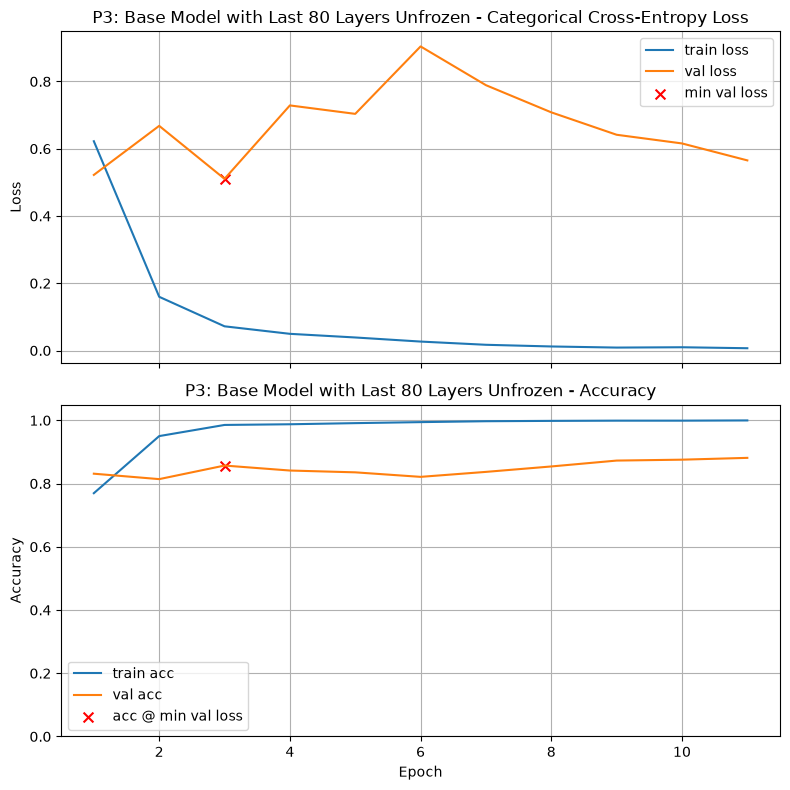

Final Training Loss:            0.0068
Final Training Accuracy:        0.9996
Final Validation Loss:          0.5653
Final Validation Accuracy:      0.8813
Minimum Validation Loss:        0.5105 (Epoch 3)
Validation Accuracy @ Min Loss: 0.8569

Test Loss: 0.4411
Test Accuracy: 0.8730

Validation-Test Gap (accuracy): 0.016056

Execution Time: 00:02:25


In [16]:
N = 80

base6 = make_base_model_pooled()
base6.trainable = True

for layer in base6.layers[:-N]:
    layer.trainable = False


p3_model6 = models.Sequential([
    base6,
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p3_model6, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title=f"P3: Base Model with Last {N} Layers Unfrozen")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_4801/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P3: Base Model with Last 20 Layers Unfrozen + Best P1 head + No ReduceLROnPlateau

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 16s 118ms/step - accuracy: 0.6135 - loss: 1.0770 - val_accuracy: 0.7854 - val_loss: 0.5554
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.8760 - loss: 0.4389 - val_accuracy: 0.8083 - val_loss: 0.5306
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.8917 - loss: 0.3397 - val_accuracy: 0.8326 - val_loss: 0.4432
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9316 - loss: 0.2497 - val_accuracy: 0.8498 - val_loss: 0.4201
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.9487 - loss: 0.1977 - val_accuracy: 0.8870 - val_loss: 0.3595
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.9562 - loss: 0.1599 - val_accuracy: 0.8841 - val_loss: 0.3661
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9708 - loss: 0.1194 - val_accuracy: 0.8856 - val_loss: 0.3916
Epoch 8/500
88/88 

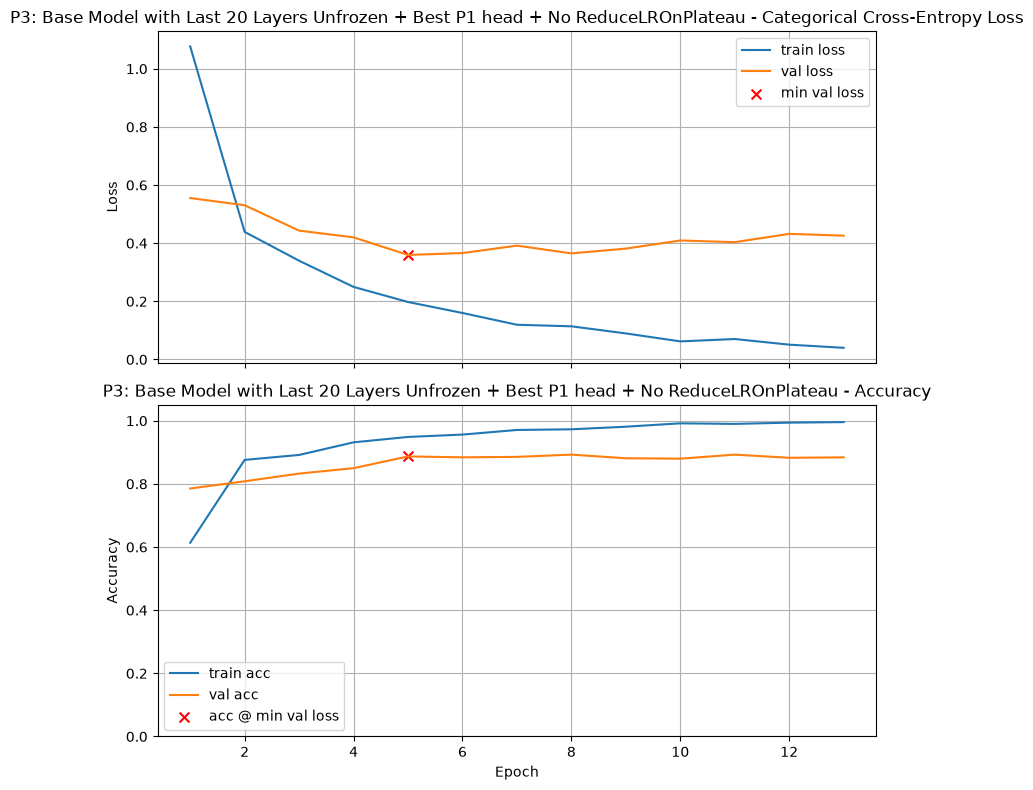

Final Training Loss:            0.0402
Final Training Accuracy:        0.9957
Final Validation Loss:          0.4259
Final Validation Accuracy:      0.8841
Minimum Validation Loss:        0.3595 (Epoch 5)
Validation Accuracy @ Min Loss: 0.8870

Test Loss: 0.2887
Test Accuracy: 0.8904

Validation-Test Gap (accuracy): 0.003393

Execution Time: 00:01:06


In [17]:
N = 20

base7 = make_base_model_pooled()
base7.trainable = True

for layer in base7.layers[:-N]:
    layer.trainable = False


p3_model7 = models.Sequential([
    base7,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p3_model7, lr_schedule=1e-4, patience=8, title=f"P3: Base Model with Last {N} Layers Unfrozen + Best P1 head + No ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_4801/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P3: Base Model with Last 20 Layers Unfrozen + Best P1 head, Patience (3), LR (1e-5)

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - accuracy: 0.2330 - loss: 1.9809 - val_accuracy: 0.3476 - val_loss: 1.5964 - learning_rate: 1.0000e-05
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.4043 - loss: 1.5064 - val_accuracy: 0.5522 - val_loss: 1.1821 - learning_rate: 1.0000e-05
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.5493 - loss: 1.1830 - val_accuracy: 0.6438 - val_loss: 0.9378 - learning_rate: 1.0000e-05
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.6551 - loss: 0.9614 - val_accuracy: 0.6981 - val_loss: 0.7886 - learning_rate: 1.0000e-05
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.7225 - loss: 0.8222 - val_accuracy: 0.7396 - val_loss: 0.6914 - learning_rate: 1.0000e-05
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.7638 - loss: 0.7176 - val_accuracy: 0.7797 - val_loss: 0.6213 - le

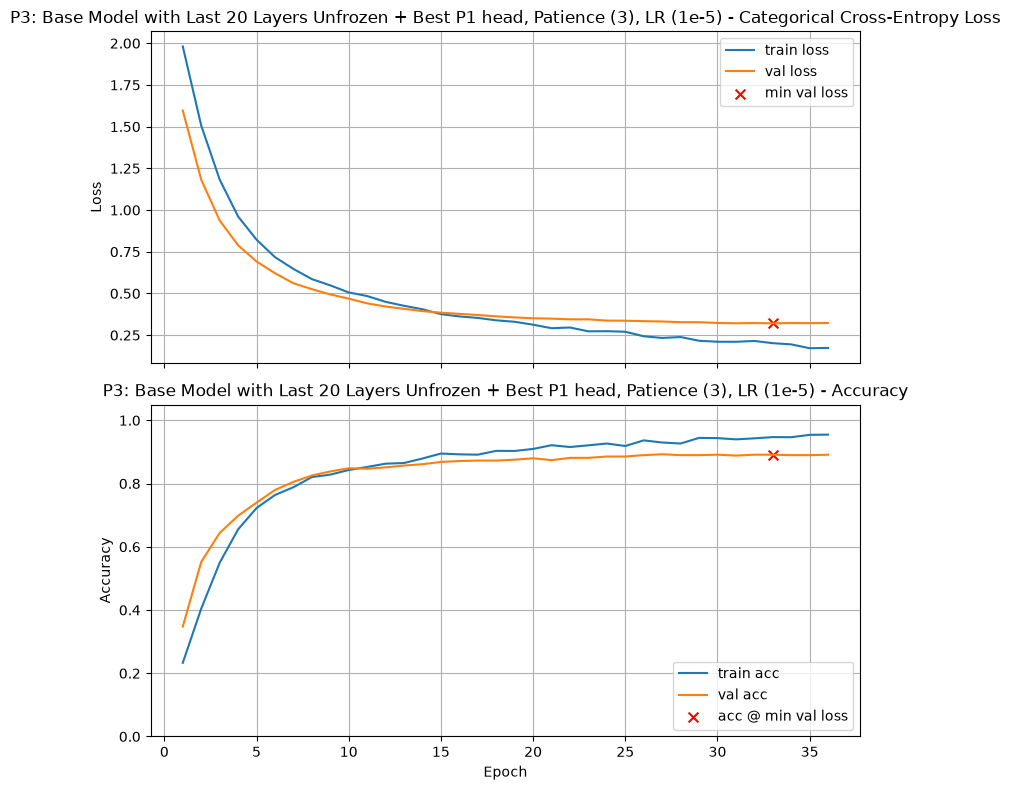

Final Training Loss:            0.1734
Final Training Accuracy:        0.9548
Final Validation Loss:          0.3231
Final Validation Accuracy:      0.8913
Minimum Validation Loss:        0.3206 (Epoch 33)
Validation Accuracy @ Min Loss: 0.8913

Test Loss: 0.2693
Test Accuracy: 0.9091

Validation-Test Gap (accuracy): 0.017818

Execution Time: 00:02:40


In [18]:
N = 20

base8 = make_base_model_pooled()
base8.trainable = True

for layer in base8.layers[:-N]:
    layer.trainable = False


p3_model8 = models.Sequential([
    base8,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p3_model8, lr_schedule=1e-5, patience=3, callbacks=[reduce_lr], title=f"P3: Base Model with Last {N} Layers Unfrozen + Best P1 head, Patience (3), LR (1e-5)")

In [19]:
print_results()

P3: Base Model with Last 80 Layers Unfrozen + Best P1 head	0.9084	25
P3: Base Model with Last 40 Layers Unfrozen + Best P1 head	0.9041	42
P3: Base Model with Last 20 Layers Unfrozen	0.8941	33
P3: Base Model with Last 20 Layers Unfrozen + Best P1 head, Patience (3), LR (1e-5)	0.8913	33
P3: Base Model with Last 20 Layers Unfrozen + Best P1 head	0.8884	18
P3: Base Model with Last 20 Layers Unfrozen + Best P1 head + No ReduceLROnPlateau	0.8870	5
P3: Base Model with Last 40 Layers Unfrozen	0.8784	11
P3: Base Model with Last 80 Layers Unfrozen	0.8569	3


### Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which partial-unfreezing configuration worked best for you, and what does that suggest about the effect of unfreezing the last \(N\) layers of MobileNetV2?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Explain your reasoning in choosing your three experimental designs.
* Identify the experiment that performed best.
* Briefly compare it with the other experiments, referring to both architectural choices (especially the **number \(N\) of unfrozen layers**, as well as dense layers or dropout) and training hyperparameters (e.g., learning rate, `ReduceLROnPlateau`).
* Explain which differences you think were most important, based on the training and validation behavior you observed.
* Conclude with what your experiments suggest about how much of a pretrained backbone should be unfrozen during fine-tuning.



**Your paragraph here (5pts):**

> The main focus was on using the best P1 head architecture or simply the base model while assessing the impact of the number of unfrozen layers in the validation accuracy at the minimum validation loss. Unfreezing more layers tended to result in higher accuracy, where the best model used the best P1 head architecture while unfreezing 80 layers. 

**Validation accuracy here (15 pts):**

In [42]:
# Set a3 to the validation accuracy found by your best model for this problem. 

a3 = 0.0             # Replace 0.0 with your answer

In [43]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3 = {a3:.4f}') 

a3 = 0.0000


## Problem Four — Unfreezing Convolution Blocks

**Goal.** Fine-tune MobileNetV2 by unfreezing the **last $K$ convolutional stages/blocks** rather than the last $N$ individual layers, as in Problem 3. This provides a more meaningful way to control how much of the pretrained backbone is allowed to adapt.

**Setup.** The backbone is MobileNetV2 with `include_top=False` and `pooling="avg"`, so it outputs a **1280-D feature vector**. Do **not** add another pooling layer in the head.

After creating the backbone, unfreeze the top $K$ stages using the following approach:

```python
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 3

base_model = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_model.trainable = True

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )
```

For example:

* $K=1$ unfreezes only `Conv_1`.
* $K=2$ unfreezes `block_16` and `Conv_1`.
* $K=3$ unfreezes `block_15`, `block_16`, and `Conv_1`.

### To Do

1. **Design at least three experiments** in which the **last $K$ stages are unfrozen**. Vary one or more of the following:

   * $K \in {1, 2, 3, 5}$
     *(Here, $K$ counts stages/blocks, not individual Keras layers.)*
   * **BatchNormalization strategy:** keep BN frozen vs. allow BN layers in the selected blocks to be trainable.
   * **Head architecture** (select one from Problem 1).
   * **Learning rate**
   * **EarlyStopping** parameters
   * **Regularization:** Dropout and/or L2
   * **ReduceLROnPlateau:** on vs. off

2. **Run and compare** the experiments using a reduced value of `DATA_FRACTION`, focusing on:

   * how performance changes as more blocks are unfrozen,
   * whether making BatchNormalization layers trainable helps or destabilizes training,
   * training stability and convergence,
   * and validation performance trends.

   Use these runs to **understand the effect of block-level fine-tuning** and to narrow down reasonable configurations, rather than to identify a single globally optimal setting.

3. **Select one configuration** (choice of $K$, BatchNormalization strategy, and training strategy), set:

```python
DATA_FRACTION = 1.0
```

and rerun the notebook on the full dataset. Use this run when answering the graded questions.

### Notes

* Your backbone was built with `pooling="avg"`, so **do not** add another `GlobalAveragePooling2D()` layer.
* Unfreezing more blocks generally makes training **more sensitive to the learning rate** and may increase instability; this is part of what you are investigating.
* Learning rates around $1\times10^{-5}$ to $3\times10^{-5}$ are reasonable starting points for block-level fine-tuning.
* Small shifts in relative performance between reduced-data experiments and the full dataset are expected.
* Construct a **new backbone/model for each experiment** so that experiments do not inherit weights from previous runs.



/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_4801/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P4: Base Model with Conv_1 Unfrozen + Best P1 head

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - accuracy: 0.8354 - loss: 0.4652 - val_accuracy: 0.8798 - val_loss: 0.3727 - learning_rate: 0.0010
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9152 - loss: 0.2487 - val_accuracy: 0.8526 - val_loss: 0.4035 - learning_rate: 0.0010
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9394 - loss: 0.1684 - val_accuracy: 0.8870 - val_loss: 0.3536 - learning_rate: 0.0010
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9555 - loss: 0.1279 - val_accuracy: 0.8727 - val_loss: 0.3969 - learning_rate: 0.0010
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9597 - loss: 0.1185 - val_accuracy: 0.8784 - val_loss: 0.3998 - learning_rate: 0.0010
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9751 - loss: 0.0810
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
88/88 ━━━━━━━━━━━━━━━━━

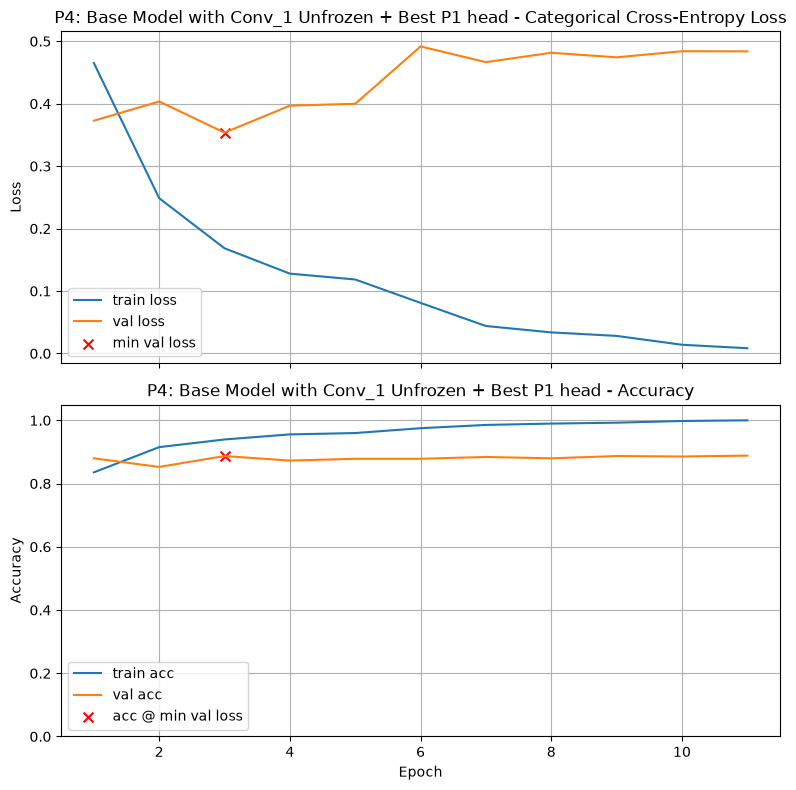

Final Training Loss:            0.0084
Final Training Accuracy:        1.0000
Final Validation Loss:          0.4838
Final Validation Accuracy:      0.8884
Minimum Validation Loss:        0.3536 (Epoch 3)
Validation Accuracy @ Min Loss: 0.8870

Test Loss: 0.3022
Test Accuracy: 0.9037

Validation-Test Gap (accuracy): 0.016762

Execution Time: 00:00:41


In [ ]:
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 1

base_mod = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_mod.trainable = True

for layer in base_mod.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

p4_model = models.Sequential([
    base_mod,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p4_model, callbacks=[reduce_lr], title=f"P4: Base Model with {block_prefixes[-1]} to {block_prefixes[-K]} Unfrozen + Best P1 head")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_4801/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P4: Base Model with block_16 Unfrozen + Best P1 head

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - accuracy: 0.7870 - loss: 0.6036 - val_accuracy: 0.3219 - val_loss: 5.6482 - learning_rate: 0.0010
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8678 - loss: 0.3829 - val_accuracy: 0.3305 - val_loss: 7.1340 - learning_rate: 0.0010
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8899 - loss: 0.3091 - val_accuracy: 0.3362 - val_loss: 5.0947 - learning_rate: 0.0010
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9113 - loss: 0.2580 - val_accuracy: 0.3233 - val_loss: 2.5583 - learning_rate: 0.0010
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9163 - loss: 0.2530 - val_accuracy: 0.2589 - val_loss: 2.7435 - learning_rate: 0.0010
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9188 - loss: 0.2202 - val_accuracy: 0.2675 - val_loss: 4.5673 - learning_rate: 0.0010
Epoch 7/500
87/88 ━━━━━━━━━━━━━

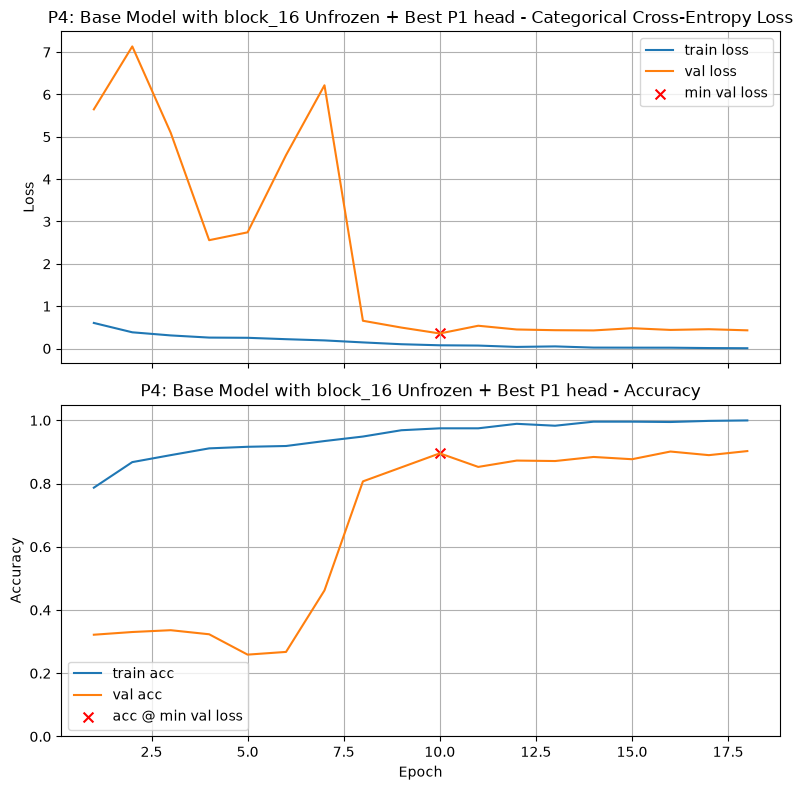

Final Training Loss:            0.0067
Final Training Accuracy:        0.9996
Final Validation Loss:          0.4293
Final Validation Accuracy:      0.9027
Minimum Validation Loss:        0.3551 (Epoch 10)
Validation Accuracy @ Min Loss: 0.8956

Test Loss: 0.2969
Test Accuracy: 0.8957

Validation-Test Gap (accuracy): 0.000157

Execution Time: 00:01:02


In [ ]:
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 2

base_mod2 = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_mod2.trainable = True

for layer in base_mod2.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

p4_model2 = models.Sequential([
    base_mod2,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p4_model2, callbacks=[reduce_lr], title=f"P4: Base Model with {block_prefixes[-1]} to {block_prefixes[-K]} Unfrozen + Best P1 head")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_4801/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P4: Base Model with block_15 Unfrozen + Best P1 head

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 106ms/step - accuracy: 0.6498 - loss: 0.9280 - val_accuracy: 0.1702 - val_loss: 33.1066 - learning_rate: 0.0010
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.4592 - loss: 1.2609 - val_accuracy: 0.1702 - val_loss: 52.4442 - learning_rate: 0.0010
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.5237 - loss: 1.0299 - val_accuracy: 0.1702 - val_loss: 51.5403 - learning_rate: 0.0010
Epoch 4/500
87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5927 - loss: 0.8799
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.5928 - loss: 0.8802 - val_accuracy: 0.1702 - val_loss: 64.0446 - learning_rate: 0.0010
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.7317 - loss: 0.6601 - val_accuracy: 0.1702 - val_loss: 32.1896 - learning_rate: 5.0000e-04
Epoch 6/500
88/88 ━━━━━━

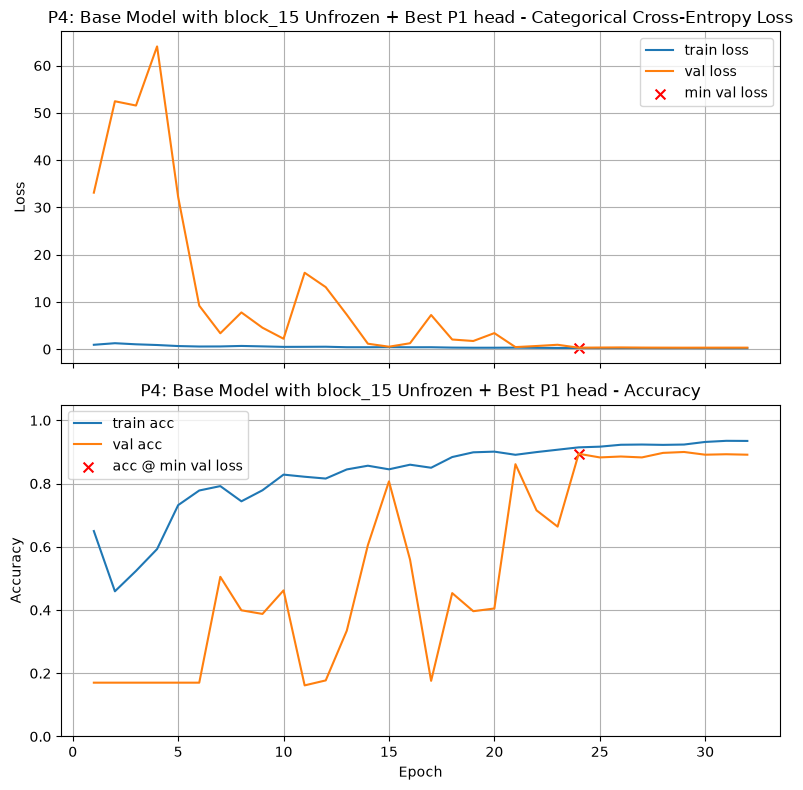

Final Training Loss:            0.2026
Final Training Accuracy:        0.9348
Final Validation Loss:          0.3196
Final Validation Accuracy:      0.8913
Minimum Validation Loss:        0.3077 (Epoch 24)
Validation Accuracy @ Min Loss: 0.8941

Test Loss: 0.2805
Test Accuracy: 0.8944

Validation-Test Gap (accuracy): 0.000251

Execution Time: 00:01:47


In [ ]:
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 3

base_mod3 = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_mod3.trainable = True

for layer in base_mod3.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

p4_model3 = models.Sequential([
    base_mod3,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p4_model3, callbacks=[reduce_lr], title=f"P4: Base Model with {block_prefixes[-1]} to {block_prefixes[-K]} Unfrozen + Best P1 head")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_4801/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P4: Base Model with block_13 Unfrozen + Best P1 head

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 15s 124ms/step - accuracy: 0.2622 - loss: 1.8351 - val_accuracy: 0.1702 - val_loss: 15.9295 - learning_rate: 0.0010
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.1785 - loss: 1.8483 - val_accuracy: 0.1702 - val_loss: 23.0328 - learning_rate: 0.0010
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.1603 - loss: 1.8066 - val_accuracy: 0.1702 - val_loss: 26.4125 - learning_rate: 0.0010
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1699 - loss: 1.7951
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.1699 - loss: 1.7951 - val_accuracy: 0.1702 - val_loss: 24.7776 - learning_rate: 0.0010
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.1767 - loss: 1.7931 - val_accuracy: 0.1702 - val_loss: 24.9107 - learning_rate: 5.0000e-04
Epoch 6/500
88/88 ━━━━━━

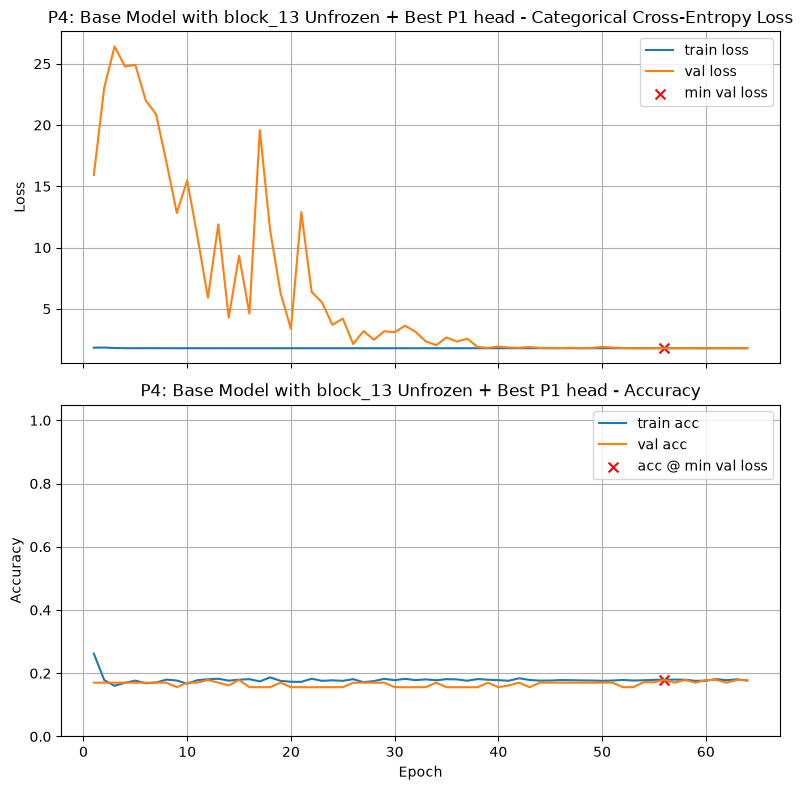

Final Training Loss:            1.7907
Final Training Accuracy:        0.1767
Final Validation Loss:          1.7916
Final Validation Accuracy:      0.1788
Minimum Validation Loss:        1.7913 (Epoch 56)
Validation Accuracy @ Min Loss: 0.1788

Test Loss: 1.7907
Test Accuracy: 0.1751

Validation-Test Gap (accuracy): 0.003693

Execution Time: 00:03:44


In [ ]:
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 5

base_mod4 = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_mod4.trainable = True

for layer in base_mod4.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

p4_model4 = models.Sequential([
    base_mod4,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p4_model4, callbacks=[reduce_lr], title=f"P4: Base Model with {block_prefixes[-1]} to {block_prefixes[-K]} Unfrozen + Best P1 head")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_4801/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P4: Base Model with block_13 Unfrozen

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 16s 129ms/step - accuracy: 0.2711 - loss: 1.7384 - val_accuracy: 0.3462 - val_loss: 1.3217 - learning_rate: 0.0010
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.3470 - loss: 1.3248 - val_accuracy: 0.3362 - val_loss: 1.2990 - learning_rate: 0.0010
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.3231 - loss: 1.2655 - val_accuracy: 0.3319 - val_loss: 1.2972 - learning_rate: 0.0010
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.3317 - loss: 1.2372 - val_accuracy: 0.3734 - val_loss: 1.2110 - learning_rate: 0.0010
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.3302 - loss: 1.2195 - val_accuracy: 0.3433 - val_loss: 1.2048 - learning_rate: 0.0010
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.3188 - loss: 1.2449 - val_accuracy: 0.3205 - val_loss: 1.2430 - learning_rate: 0.0010
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms

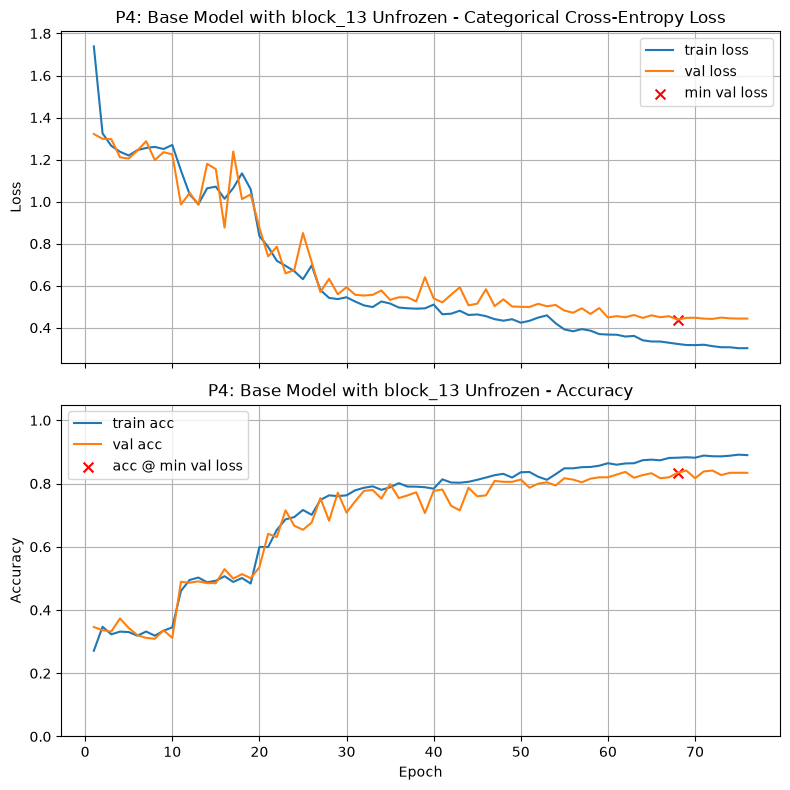

Final Training Loss:            0.3030
Final Training Accuracy:        0.8899
Final Validation Loss:          0.4436
Final Validation Accuracy:      0.8340
Minimum Validation Loss:        0.4386 (Epoch 68)
Validation Accuracy @ Min Loss: 0.8340

Test Loss: 0.4213
Test Accuracy: 0.8356

Validation-Test Gap (accuracy): 0.001513

Execution Time: 00:03:48


In [ ]:
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 5

base_mod5 = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_mod5.trainable = True

for layer in base_mod5.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

p4_model5 = models.Sequential([
    base_mod5,
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p4_model5, callbacks=[reduce_lr], title=f"P4: Base Model with {block_prefixes[-1]} to {block_prefixes[-K]} Unfrozen")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_4801/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P4: Base Model with Conv_1 to block_15 Unfrozen + Best P1 head with L2 regularization

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 149ms/step - accuracy: 0.6990 - loss: 0.9141 - val_accuracy: 0.1617 - val_loss: 24.1360 - learning_rate: 0.0010
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.4931 - loss: 1.3553 - val_accuracy: 0.1702 - val_loss: 68.5887 - learning_rate: 0.0010
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.4247 - loss: 1.4562 - val_accuracy: 0.1702 - val_loss: 46.9040 - learning_rate: 0.0010
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4856 - loss: 1.2664
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.4856 - loss: 1.2664 - val_accuracy: 0.1617 - val_loss: 29.6331 - learning_rate: 0.0010
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.4218 - loss: 1.3934 - val_accuracy: 0.1617 - val_loss: 77.5794 - learning_rate: 5.0000e-04
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.3937 - loss: 1.4949 - val

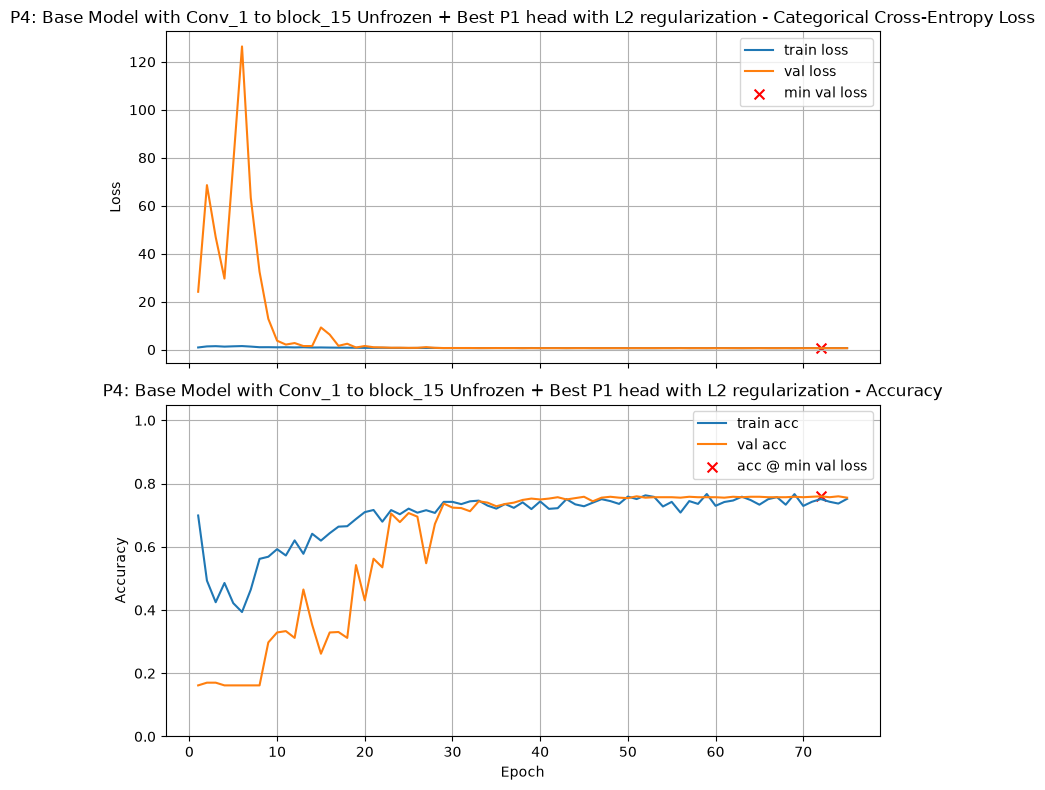

Final Training Loss:            0.6467
Final Training Accuracy:        0.7517
Final Validation Loss:          0.6216
Final Validation Accuracy:      0.7554
Minimum Validation Loss:        0.6210 (Epoch 72)
Validation Accuracy @ Min Loss: 0.7597

Test Loss: 0.5858
Test Accuracy: 0.7687

Validation-Test Gap (accuracy): 0.009060

Execution Time: 00:04:08


In [ ]:
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 3

base_mod6 = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_mod6.trainable = True

for layer in base_mod6.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

p4_model6 = models.Sequential([
    base_mod6,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p4_model6, callbacks=[reduce_lr], title=f"P4: Base Model with {block_prefixes[-1]} to {block_prefixes[-K]} Unfrozen + Best P1 head with L2 regularization")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_4801/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P4: Base Model with Conv_1 to block_16 Unfrozen + Best P1 head with L2 regularization

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


88/88 ━━━━━━━━━━━━━━━━━━━━ 17s 132ms/step - accuracy: 0.8119 - loss: 0.6304 - val_accuracy: 0.1702 - val_loss: 14.3260 - learning_rate: 0.0010
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.8782 - loss: 0.4524 - val_accuracy: 0.1702 - val_loss: 6.2328 - learning_rate: 0.0010
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8953 - loss: 0.3869 - val_accuracy: 0.4979 - val_loss: 2.9319 - learning_rate: 0.0010
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9230 - loss: 0.3122 - val_accuracy: 0.7940 - val_loss: 0.7530 - learning_rate: 0.0010
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9255 - loss: 0.2902 - val_accuracy: 0.4678 - val_loss: 2.1580 - learning_rate: 0.0010
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9280 - loss: 0.2870 - val_accuracy: 0.4378 - val_loss: 4.7380 - learning_rate: 0.0010
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9473 - loss: 0.2248
Epoch 7: Re

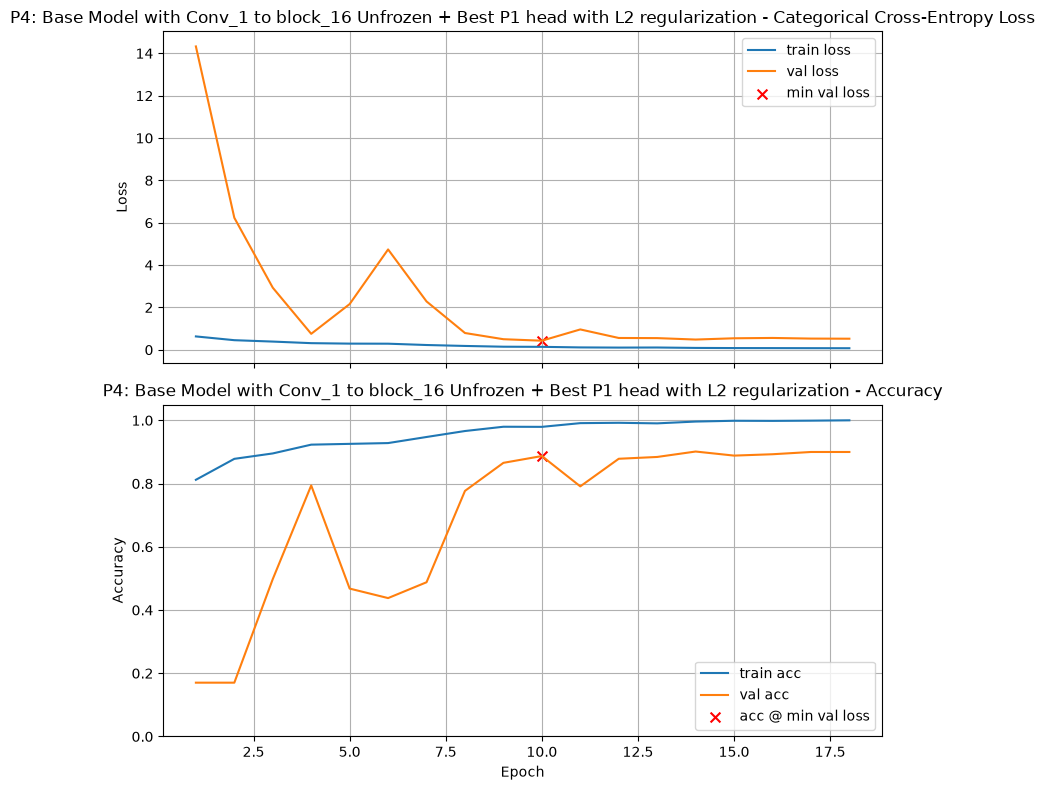

Final Training Loss:            0.0729
Final Training Accuracy:        1.0000
Final Validation Loss:          0.5227
Final Validation Accuracy:      0.8999
Minimum Validation Loss:        0.4282 (Epoch 10)
Validation Accuracy @ Min Loss: 0.8870

Test Loss: 0.3839
Test Accuracy: 0.8904

Validation-Test Gap (accuracy): 0.003393

Execution Time: 00:01:08


In [30]:
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 2

base_mod7 = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_mod7.trainable = True

for layer in base_mod7.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

p4_model7 = models.Sequential([
    base_mod7,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p4_model7, callbacks=[reduce_lr], title=f"P4: Base Model with {block_prefixes[-1]} to {block_prefixes[-K]} Unfrozen + Best P1 head with L2 regularization")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_4801/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P4: Base Model with Conv_1 to block_16 Unfrozen + Best P1 head with L2 regularization, patience (6)

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


88/88 ━━━━━━━━━━━━━━━━━━━━ 17s 133ms/step - accuracy: 0.8144 - loss: 0.6623 - val_accuracy: 0.1702 - val_loss: 15.0066 - learning_rate: 0.0010
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8725 - loss: 0.4617 - val_accuracy: 0.2017 - val_loss: 5.8263 - learning_rate: 0.0010
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9024 - loss: 0.3778 - val_accuracy: 0.3190 - val_loss: 3.0893 - learning_rate: 0.0010
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9099 - loss: 0.3437 - val_accuracy: 0.8054 - val_loss: 0.8008 - learning_rate: 0.0010
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9213 - loss: 0.3067 - val_accuracy: 0.3763 - val_loss: 2.5034 - learning_rate: 0.0010
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9344 - loss: 0.2770 - val_accuracy: 0.6366 - val_loss: 1.8209 - learning_rate: 0.0010
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9551 - loss: 0.2252
Epoch 7: Re

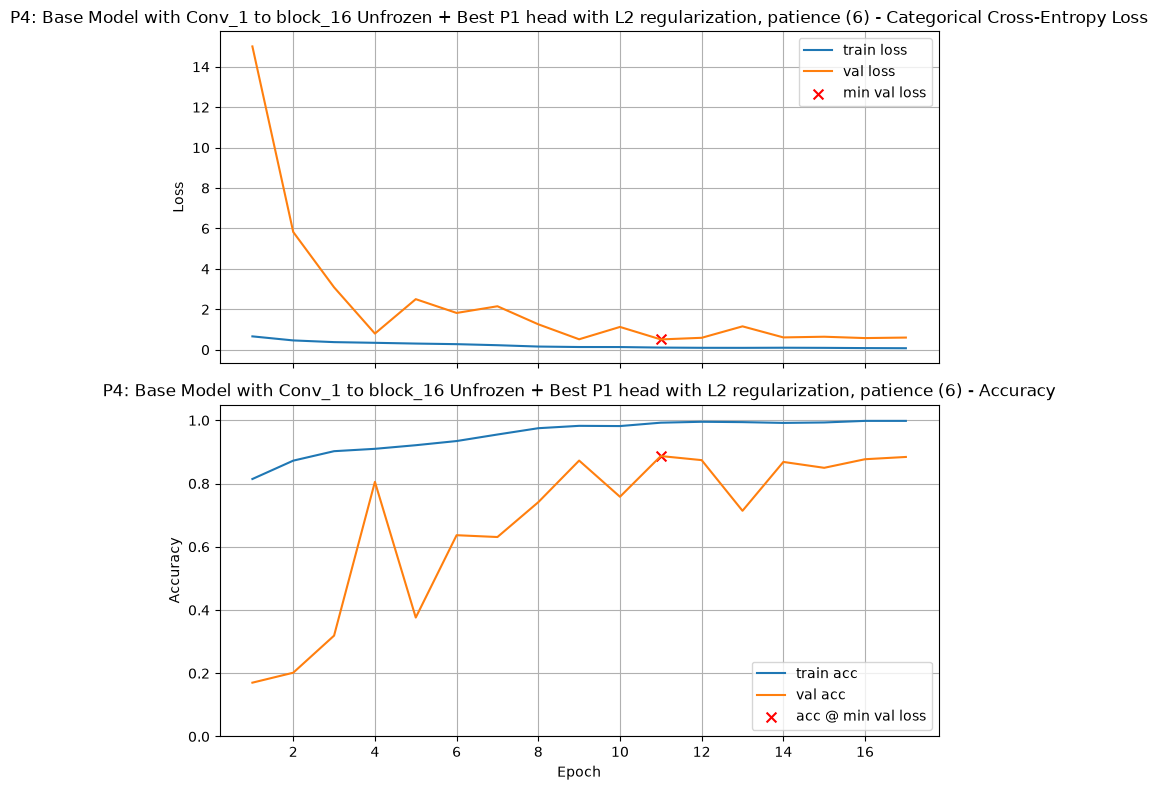

Final Training Loss:            0.0758
Final Training Accuracy:        0.9982
Final Validation Loss:          0.6032
Final Validation Accuracy:      0.8841
Minimum Validation Loss:        0.5113 (Epoch 11)
Validation Accuracy @ Min Loss: 0.8870

Test Loss: 0.4800
Test Accuracy: 0.8917

Validation-Test Gap (accuracy): 0.004730

Execution Time: 00:01:06


In [31]:
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 2

base_mod8 = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_mod8.trainable = True

for layer in base_mod8.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

p4_model8 = models.Sequential([
    base_mod8,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p4_model8, patience=6, callbacks=[reduce_lr], title=f"P4: Base Model with {block_prefixes[-1]} to {block_prefixes[-K]} Unfrozen + Best P1 head with L2 regularization, patience (6)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_4801/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P4: Base Model with Conv_1 to block_16 Unfrozen + Best P1 head with DO (0.45 -> 0.20)

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 157ms/step - accuracy: 0.7976 - loss: 0.5923 - val_accuracy: 0.1702 - val_loss: 12.4812 - learning_rate: 0.0010
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.8717 - loss: 0.3684 - val_accuracy: 0.3247 - val_loss: 6.0665 - learning_rate: 0.0010
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9006 - loss: 0.3052 - val_accuracy: 0.2017 - val_loss: 7.9539 - learning_rate: 0.0010
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8992 - loss: 0.2725 - val_accuracy: 0.2246 - val_loss: 6.2183 - learning_rate: 0.0010
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9138 - loss: 0.2446 - val_accuracy: 0.3920 - val_loss: 4.9768 - learning_rate: 0.0010
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9334 - loss: 0.2035 - val_accuracy: 0.4564 - val_loss: 3.2263 - learning_rate: 0.0010
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9369 - loss: 0.1651 - val_accur

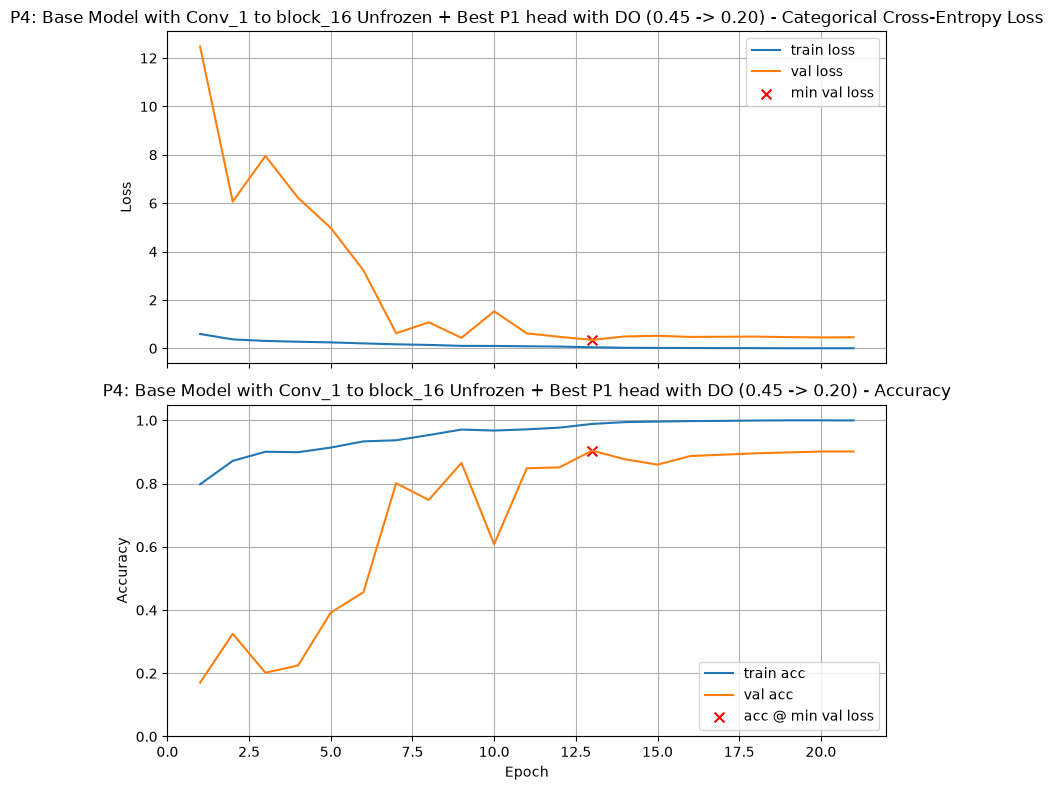

Final Training Loss:            0.0036
Final Training Accuracy:        0.9996
Final Validation Loss:          0.4578
Final Validation Accuracy:      0.9013
Minimum Validation Loss:        0.3493 (Epoch 13)
Validation Accuracy @ Min Loss: 0.9041

Test Loss: 0.3159
Test Accuracy: 0.8944

Validation-Test Gap (accuracy): 0.009764

Execution Time: 00:01:20


In [34]:
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 2

base_mod9 = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_mod9.trainable = True

for layer in base_mod9.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

p4_model9 = models.Sequential([
    base_mod9,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.45),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p4_model9, callbacks=[reduce_lr], title=f"P4: Base Model with {block_prefixes[-1]} to {block_prefixes[-K]} Unfrozen + Best P1 head with DO (0.45 -> 0.20)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_4801/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P4: Base Model with Conv_1 to block_16 Unfrozen + Best P1 head with no ReduceLROnPlateau

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 138ms/step - accuracy: 0.8076 - loss: 0.5424 - val_accuracy: 0.2203 - val_loss: 2.2928
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8618 - loss: 0.3856 - val_accuracy: 0.2475 - val_loss: 4.5302
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8974 - loss: 0.2966 - val_accuracy: 0.1817 - val_loss: 9.8117
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9099 - loss: 0.2662 - val_accuracy: 0.4535 - val_loss: 3.2177
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9234 - loss: 0.2172 - val_accuracy: 0.5436 - val_loss: 2.0880
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9266 - loss: 0.2009 - val_accuracy: 0.6295 - val_loss: 2.6824
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9533 - loss: 0.1385 - val_accuracy: 0.8569 - val_loss: 0.4792
Epoch 8/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9658 - loss: 0.0971 - val_accuracy: 0.8398 - val

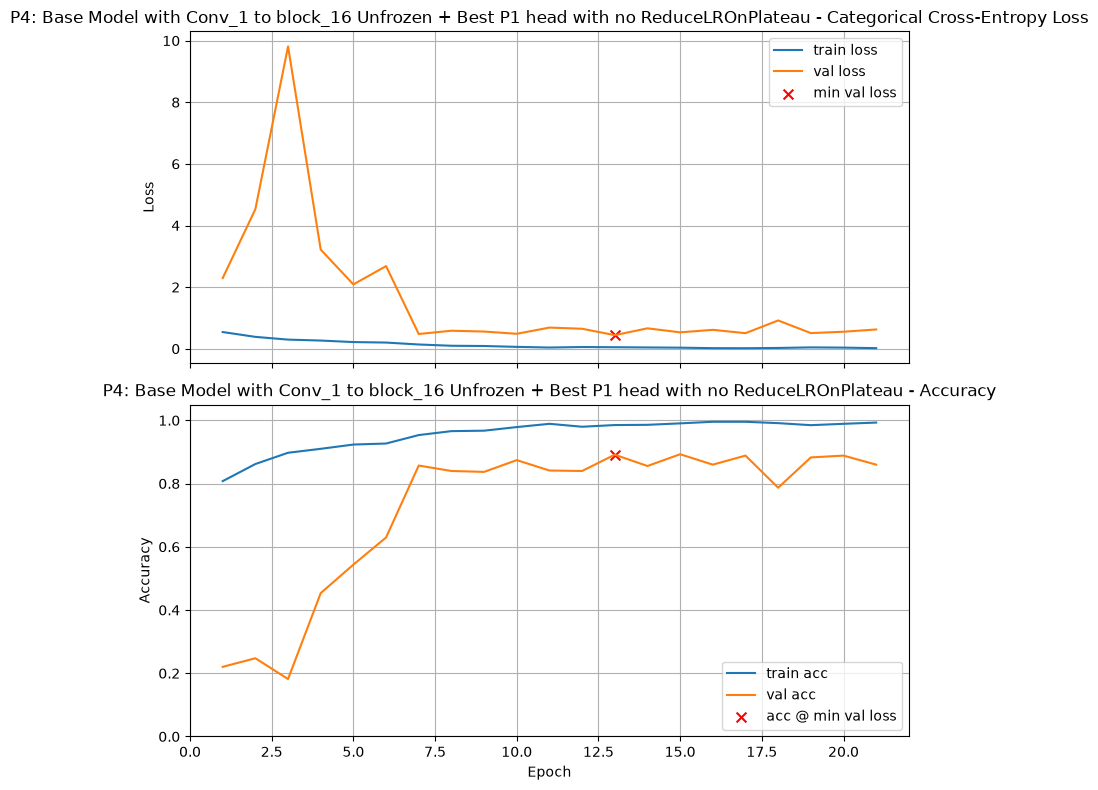

Final Training Loss:            0.0196
Final Training Accuracy:        0.9929
Final Validation Loss:          0.6257
Final Validation Accuracy:      0.8598
Minimum Validation Loss:        0.4414 (Epoch 13)
Validation Accuracy @ Min Loss: 0.8913

Test Loss: 0.3997
Test Accuracy: 0.8944

Validation-Test Gap (accuracy): 0.003112

Execution Time: 00:01:17


In [35]:
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 2

base_mod10 = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_mod10.trainable = True

for layer in base_mod10.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

p4_model10 = models.Sequential([
    base_mod10,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p4_model10, title=f"P4: Base Model with {block_prefixes[-1]} to {block_prefixes[-K]} Unfrozen + Best P1 head with no ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_4801/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P4: Base Model with Conv_1 to block_16 Unfrozen + Best P1 head with DO (0.45 -> 0.20), no ReduceLROnPlateau

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


88/88 ━━━━━━━━━━━━━━━━━━━━ 17s 136ms/step - accuracy: 0.7948 - loss: 0.5880 - val_accuracy: 0.1702 - val_loss: 11.1330
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8714 - loss: 0.3732 - val_accuracy: 0.5179 - val_loss: 2.0366
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8913 - loss: 0.3191 - val_accuracy: 0.3047 - val_loss: 4.8196
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9152 - loss: 0.2563 - val_accuracy: 0.3104 - val_loss: 6.2556
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9316 - loss: 0.1951 - val_accuracy: 0.6824 - val_loss: 1.2070
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9355 - loss: 0.1783 - val_accuracy: 0.6896 - val_loss: 1.1655
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9608 - loss: 0.1187 - val_accuracy: 0.8369 - val_loss: 0.6439
Epoch 8/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9708 - loss: 0.0887 - val_accuracy: 0.7969 - va

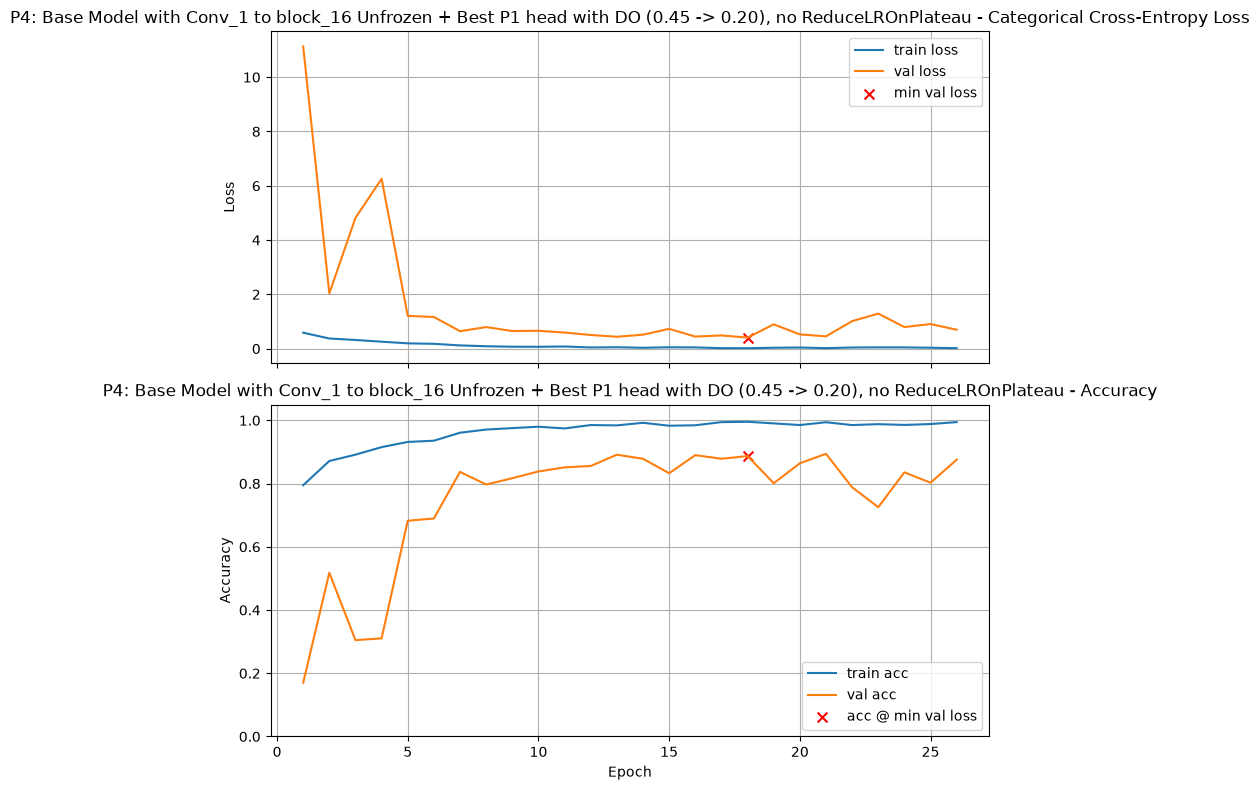

Final Training Loss:            0.0166
Final Training Accuracy:        0.9943
Final Validation Loss:          0.6966
Final Validation Accuracy:      0.8755
Minimum Validation Loss:        0.4077 (Epoch 18)
Validation Accuracy @ Min Loss: 0.8870

Test Loss: 0.3848
Test Accuracy: 0.8971

Validation-Test Gap (accuracy): 0.010077

Execution Time: 00:01:31


In [37]:
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 2

base_mod11 = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_mod11.trainable = True

for layer in base_mod11.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

p4_model11 = models.Sequential([
    base_mod11,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.45),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p4_model11, title=f"P4: Base Model with {block_prefixes[-1]} to {block_prefixes[-K]} Unfrozen + Best P1 head with DO (0.45 -> 0.20), no ReduceLROnPlateau")

In [39]:
print_results()

P3: Base Model with Last 80 Layers Unfrozen + Best P1 head	0.9084	25
P3: Base Model with Last 40 Layers Unfrozen + Best P1 head	0.9041	42
P4: Base Model with Conv_1 to block_16 Unfrozen + Best P1 head with DO (0.45 -> 0.20)	0.9041	13
P4: Base Model with block_16 Unfrozen + Best P1 head	0.8956	10
P3: Base Model with Last 20 Layers Unfrozen	0.8941	33
P4: Base Model with block_15 Unfrozen + Best P1 head	0.8941	24
P3: Base Model with Last 20 Layers Unfrozen + Best P1 head, Patience (3), LR (1e-5)	0.8913	33
P4: Base Model with Conv_1 to block_16 Unfrozen + Best P1 head with no ReduceLROnPlateau	0.8913	13
P3: Base Model with Last 20 Layers Unfrozen + Best P1 head	0.8884	18
P3: Base Model with Last 20 Layers Unfrozen + Best P1 head + No ReduceLROnPlateau	0.8870	5
P4: Base Model with Conv_1 Unfrozen + Best P1 head	0.8870	3
P4: Base Model with Conv_1 to block_16 Unfrozen + Best P1 head with L2 regularization	0.8870	10
P4: Base Model with Conv_1 to block_16 Unfrozen + Best P1 head with L2 regula

### Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which block-unfreezing configuration worked best for you, and what does that suggest about the effect of unfreezing the last \(K\) MobileNetV2 blocks?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Explain your reasoning in choosing your three experimental designs.
* Identify the experiment that performed best.
* Briefly compare it with the other experiments, referring to both architectural choices (especially the **number \(K\) of unfrozen blocks**, as well as dense layers or dropout) and training hyperparameters (e.g., learning rate, `ReduceLROnPlateau`).
* If you experimented with BatchNormalization, comment briefly on whether keeping BN frozen or allowing it to train appeared to help or destabilize training.
* Explain which differences you think were most important, based on the training and validation behavior you observed.
* Conclude with what your experiments suggest about selecting how many pretrained blocks to unfreeze during fine-tuning.



**Your paragraph here (5pts):**

> Unfreezing less of the blocks tended to result in higher accuracy when paired with the best P1 head architecture. Experimenting with the number of blocks, enabling/disabling ReduceLROnPlateau, and dropout percentage per block in the head architecture resulted in the most promising results. The best model unfroze only the two final blocks (Conv_1 and block_16) while increasing the dropout of the first block in the head architecture from 0.4 to 0.45. Limiting K seemed to have the greatest effect on validation accuracy, then increasing dropout percentages, and then disabling ReduceLROnPlateau or implementing L2 regularization had minimal improvements. Overall, this experiment suggests that unfreezing less blocks on the pretrained base will result in better results.

**Validation accuracy (15pts):**

In [45]:
# Set a4 to the validation accuracy found by your best model for this problem. 

a4 = 0.0             # Replace 0.0 with your answer

In [46]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4 = {a4:.4f}') 

a4 = 0.0000


## Problem 5: Final Reflection

Run the next cell and consider all your experiments in this homework. 

This reflection question is worth 5 points. 

In [47]:
# Print out summary of validation accuracy for each experiment

print_results()

P2: P1 best model (unfrozen base) - LR (3e-5)	0.9041	37
P1: Three Tier Funnel (no reg), LR (5e-4), Patience (8)	0.9027	4
P1: Two Tier Funnel (no reg), LR (1e-4), Patience (6)	0.9027	13
P1: Two Tier Funnel (no reg), LR (5e-4), Patience (6), ReduceLROnPlateau	0.9013	2
P2: P1 best model (unfrozen base)       	0.9013	9
P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg on Dense 512	0.9013	18
P3: Base Model with Last 20 Layers Unfrozen + Best P1 head	0.9013	25
P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg	0.8984	17
P4: Base Model with Conv_1 Unfrozen + Best P1 head	0.8984	2
P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8)	0.8970	3
P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8)	0.8970	13
P2: P1 best model (unfrozen base) - LR (3e-5) no ReduceLROnPlateau	0.8970	30
P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8), ReduceLROnPlateau	0.8956	12
P1: Two Tier Funnel with l2reg, LR (1e-4), Patience (8), ReduceLROnPlateau	0.8

### Graded Question

### Final Reflection

Looking across the validation accuracies from your **full-dataset runs**, what patterns or lessons stand out from the different transfer-learning strategies you explored?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Compare the overall results from the frozen backbone, fully trainable backbone, partial layer unfreezing, and block-level unfreezing experiments.
* Highlight at least one design choice or training hyperparameter that appeared especially important.
* Mention any result that surprised you or differed from what you expected, if applicable.
* Conclude with a brief takeaway about what you learned about transfer learning from the homework.



**Your paragraph here (5pts):**

> Replace this sentence with your answer. 

## Appendix: What is MobileNetV2 (in plain English)?

`MobileNetV2` is a lightweight convolutional neural network (CNN) designed for efficient inference on resource-constrained devices while maintaining strong image-classification accuracy.

It achieves this with two important ideas:

1. **Depthwise-separable convolutions**

   Instead of using one expensive 3×3 convolution that mixes spatial information and channels at the same time, MobileNetV2 separates the operation into two steps:

   * a **depthwise 3×3 convolution**, which applies one spatial filter to each input channel separately, followed by
   * a **pointwise 1×1 convolution**, which mixes information across channels.

   This greatly reduces the number of parameters and computations compared with a standard convolution. ([arXiv][1])

2. **Inverted residual blocks with a linear bottleneck**

   A typical MobileNetV2 block has the following structure:

   * **Expand (1×1 convolution):** increase the number of channels, often by a factor of about 6, and apply a nonlinear activation.
   * **Depthwise (3×3 convolution):** process each channel separately and apply a nonlinear activation.
   * **Project (1×1 convolution):** reduce the number of channels again, but **without** applying a nonlinear activation. This is the **linear bottleneck**.

   If the input and output shapes match and the stride is 1, the block also adds a **skip connection**.

   The term **inverted residual** refers to the fact that the representation becomes wide inside the block and narrow again at the output, rather than the other way around.

   The final linear projection helps preserve information when the representation is compressed back to a lower-dimensional space. ([arXiv][1])

---

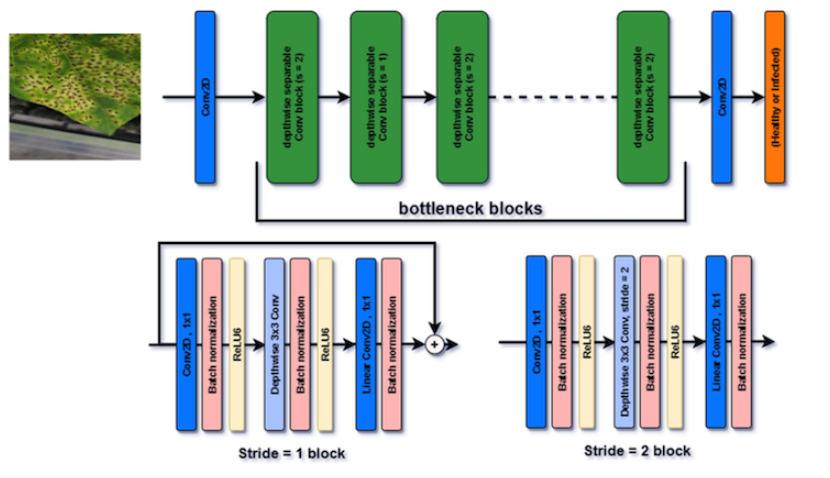

---

### What was MobileNetV2 trained on?

The Keras ImageNet weights for MobileNetV2 were trained on **ImageNet-1K**, a standard image-classification dataset containing:

* **1,281,167** training images
* **50,000** validation images
* **100,000** test images
* **1000 classes**

A common input size for MobileNetV2 is **224×224**. ([ImageNet][2])

For this homework, we use smaller **150×150** images to reduce training time.

Because we use:

```python
include_top=False
```

the pretrained convolutional backbone can operate on image sizes other than 224×224.

---

### Preprocessing

The preprocessing used for a pretrained network should match the preprocessing used when that network was originally trained.

For MobileNetV2, Keras provides:

```python
mobilenet_v2.preprocess_input
```

This function takes pixel values in their original approximately **0–255** range and scales them to approximately **[-1, 1]**.

In this homework, the image-loading pipeline applies this preprocessing before passing images to MobileNetV2. ([keras.io][3])

---

### How Keras exposes MobileNetV2

The following Keras call:

```python
tf.keras.applications.mobilenet_v2.MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)
```

returns a pretrained MobileNetV2 backbone with the original ImageNet classification head removed.

With:

```python
pooling="avg"
```

Keras applies **Global Average Pooling** to the final convolutional feature map. The result is a **1280-dimensional feature vector** for each image.

To use this backbone as a **frozen feature extractor**, we additionally set:

```python
base_model.trainable = False
```

The classification head that we add afterward can then be trained while the pretrained MobileNetV2 weights remain unchanged.

---

### What happens if `pooling="avg"` is omitted?

Without pooling, the backbone produces a spatial feature map rather than a single feature vector.

For a 224×224 input image, this feature map is typically:

```text
7 × 7 × 1280
```

Before connecting this to Dense layers, we would normally reduce the spatial dimensions using:

```python
GlobalAveragePooling2D()
```

which produces a 1280-dimensional vector.

`GlobalMaxPooling2D()` is another possible choice.

Using:

```python
Flatten()
```

is usually less attractive here because it would convert:

```text
7 × 7 × 1280
```

into:

```text
62,720
```

features, creating a much larger classification head.

In this homework, however, we use:

```python
pooling="avg"
```

inside MobileNetV2 itself, so **do not add another `GlobalAveragePooling2D()` layer**.

---

### How we use MobileNetV2 in this homework

We will experiment with several ways of using the pretrained backbone:

* **Frozen feature extraction:** keep all MobileNetV2 layers frozen and train only a new classification head.
* **Fully trainable backbone:** allow all MobileNetV2 layers to be updated during training.
* **Partial unfreezing:** keep most of the backbone frozen while allowing only selected upper layers or blocks to be updated.

These experiments let us investigate how much of the pretrained representation should be preserved and how much should be adapted to the Intel Image Classification dataset.

---

### TL;DR Summary

* Think of a MobileNetV2 block as:

  **expand → depthwise convolution → project (+ optional skip connection)**

* MobileNetV2 was pretrained to distinguish **1000 ImageNet classes**.

* In this homework, we reuse those learned visual features and train the model for our **6 Intel image classes**.

* With:

  ```python
  include_top=False,
  pooling="avg"
  ```

  the backbone outputs a **1280-D feature vector**.

* To use the backbone as a frozen feature extractor, set:

  ```python
  base_model.trainable = False
  ```

* Always match preprocessing to the pretrained backbone. For MobileNetV2, use:

  ```python
  mobilenet_v2.preprocess_input
  ```

  which scales the original pixel values to approximately **[-1, 1]**. ([keras.io][3])

---

### See also

* [https://www.analyticsvidhya.com/blog/2023/12/what-is-mobilenetv2/](https://www.analyticsvidhya.com/blog/2023/12/what-is-mobilenetv2/)

[1]: https://arxiv.org/abs/1801.04381
[2]: https://www.image-net.org/
[3]: https://keras.io/api/applications/mobilenet/mobilenet_models/


